# Visual Question Answering – Dược liệu Việt Nam
## Hướng A: Kiến trúc tự xây (Modular Architecture)

**Môn học:** Học Sâu (Deep Learning)  
**Nguồn dữ liệu:** https://tracuuduoclieu.vn  
**Miền dữ liệu:** Dược liệu y học cổ truyền Việt Nam  
**Môi trường chạy:** colab

---


**Mục lục**

1. Cài đặt môi trường  
2. Cấu hình toàn cục  
3. Chuẩn bị dữ liệu  
4. Image Encoder (DINOv2)  
5. Text Encoder (PhoBERT)  
6. Co-attention Fusion Module  
7. Answer Decoder A1 – LSTM  
8. Answer Decoder A2 – Transformer  
9. Mô hình VQA tổng thể  
10. Training Pipeline  
11. Đánh giá và so sánh A1 vs A2  
12. Demo suy luận (Inference)

---
## 1.Cài đặt môi trường

Cài đặt các thư viện cần thiết cho toàn bộ dự án. Cụ thể bao gồm:
- `transformers`, `timm`: load DINOv2 và PhoBERT.
- `vncorenlp`: word-segment tiếng Việt trước khi đưa vào PhoBERT.
- `torch`, `torchvision`: nền tảng huấn luyện.
- `evaluate`, `bert_score`, `nltk`: các metric đánh giá.
- `wandb`: theo dõi quá trình train (tuỳ chọn).

Sau khi cài đặt, kiểm tra phiên bản CUDA và xác nhận GPU được nhận diện.

In [1]:
# ===== COLAB SETUP =====
from google.colab import userdata
import subprocess, sys

def _install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

_install("transformers>=4.38.0", "datasets", "huggingface_hub", "accelerate", "timm>=0.9.0")
_install("vncorenlp")
_install("evaluate", "bert-score", "rouge-score", "nltk")
_install("wandb", "matplotlib", "seaborn", "pandas", "tqdm", "Pillow")

import nltk
for pkg in ["punkt", "punkt_tab", "wordnet"]:
    nltk.download(pkg, quiet=True)

import torch

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version    :", torch.version.cuda)
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        vram_gb = p.total_memory / 1e9
        print(f"GPU [{i}]          : {p.name}  |  VRAM: {vram_gb:.1f} GB")
else:
    print("WARNING: GPU not found. Training on CPU will be extremely slow.")

print("Setup complete.")


PyTorch version : 2.10.0+cu128
CUDA available  : True
CUDA version    : 12.8
GPU [0]          : Tesla T4  |  VRAM: 15.6 GB
Setup complete.


In [2]:
# Patch autocast cho tuong thich PyTorch 2.x
import torch
# Ghi de bien autocast o module level de tat ca cac cell phia sau dung chung
import torch.amp
autocast = torch.amp.autocast


---
## 2.Cấu hình toàn cục

Định nghĩa tất cả hằng số và tham số cấu hình ở một chỗ duy nhất để dễ quản lý và chỉnh sửa. Cụ thể bao gồm:

**Đường dẫn:**
- Đường dẫn tới file dữ liệu JSON, thư mục ảnh, thư mục lưu checkpoint.

**Tham số mô hình:**
- Tên model DINOv2 và PhoBERT trên HuggingFace.
- Kích thước chiều sâu Linear Projection.
- Số lượng lớp và attention head của Transformer Decoder.
- Kích thước hidden state của LSTM Decoder.

**Tham số huấn luyện:**
- Batch size (8 với gradient accumulation 4 bước).
- Số epoch từng giai đoạn (freeze và unfreeze).
- Learning rate (giai đoạn 1 khoảng 1e-4, giai đoạn 2 khoảng 1e-5).
- Hệ số label smoothing.

**Cấu hình thiết bị:**
- Phát hiện và gán device (cuda hoặc cpu).
- Đặt seed ngẫu nhiên để tạo sự tái lập (reproducibility).

In [4]:
import os
from google.colab import userdata

HF_DATASET_ID = "azan100an/tdtu_vqa_dataset_herb"

# ── Đổi /kaggle/working → /content ──
CHECKPOINT_DIR = "/content/checkpoints"
LOG_DIR        = "/content/logs"
VOCAB_PATH     = "/content/vocab.pkl"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

FIELD_FILE_NAME = "file_name"
FIELD_QUESTION  = "question"
FIELD_ANSWER    = "answer"

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

PAD_ID = 0
SOS_ID = 1
EOS_ID = 2
UNK_ID = 3

HF_HUB_REPO_ID = "azan100an/vqa-herb-checkpoints-Vit_base_colab"
# hf_***********************************
HF_HUB_TOKEN   = userdata.get("HF_TOKEN")

print("Paths configured.")
print(f"  Checkpoint dir : {CHECKPOINT_DIR}")
print(f"  Log dir        : {LOG_DIR}")
print(f"  HF dataset     : {HF_DATASET_ID}")
print(f"  HF hub repo    : {HF_HUB_REPO_ID}")


Paths configured.
  Checkpoint dir : /content/checkpoints
  Log dir        : /content/logs
  HF dataset     : azan100an/tdtu_vqa_dataset_herb
  HF hub repo    : azan100an/vqa-herb-checkpoints-Vit_base_colab


In [5]:
# --- Ten model pretrained tren HuggingFace ---
# Chuyen ve ban Base de tranh overfit va giam nhe VRAM
DINOV2_MODEL_NAME  = "facebook/dinov2-base"
PHOBERT_MODEL_NAME = "vinai/phobert-base-v2"

# --- Chieu dac trung dau ra cua hai encoder ---
# Output cua dinov2-base cung la 768, bang voi phobert-base
IMAGE_ENCODER_DIM = 768
TEXT_ENCODER_DIM  = 768

# --- Chieu sau khi chieu tuyen tinh (Linear Projection) ---
PROJECTION_DIM = 256

# --- Cau hinh Transformer Decoder (A2) ---
TRANSFORMER_NUM_LAYERS = 2
TRANSFORMER_NUM_HEADS  = 4
TRANSFORMER_FFN_DIM    = 512
TRANSFORMER_DROPOUT    = 0.3

# --- Cau hinh LSTM Decoder (A1) ---
LSTM_HIDDEN_DIM  = 512
LSTM_NUM_LAYERS  = 2
LSTM_DROPOUT     = 0.3

# --- Cau hinh Embedding cho Decoder ---
EMBEDDING_DIM = 256

# --- Do dai chuoi toi da ---
MAX_QUESTION_LEN = 64
MAX_ANSWER_LEN   = 64

# --- Kich thuoc anh dau vao ---
# Giam ve 224 (mac dinh cua dinov2) de tang toc toc do tinh toan
IMAGE_SIZE = 224

print("Tham so mo hinh da duoc cap nhat:")
print(f"  Image Encoder dim   : {IMAGE_ENCODER_DIM}")
print(f"  Text Encoder dim    : {TEXT_ENCODER_DIM}")
print(f"  Projection dim      : {PROJECTION_DIM}")
print(f"  Transformer layers  : {TRANSFORMER_NUM_LAYERS}, heads: {TRANSFORMER_NUM_HEADS}, dropout: {TRANSFORMER_DROPOUT}")
print(f"  LSTM hidden dim     : {LSTM_HIDDEN_DIM}, layers: {LSTM_NUM_LAYERS}")
print(f"  Max answer length   : {MAX_ANSWER_LEN} tokens")
print(f"  Image Size          : {IMAGE_SIZE}x{IMAGE_SIZE}")


Tham so mo hinh da duoc cap nhat:
  Image Encoder dim   : 768
  Text Encoder dim    : 768
  Projection dim      : 256
  Transformer layers  : 2, heads: 4, dropout: 0.3
  LSTM hidden dim     : 512, layers: 2
  Max answer length   : 64 tokens
  Image Size          : 224x224


In [6]:
import torch
import random
import numpy as np

# --- Tham so batch va tich luy gradient ---
# Giam batch size giup model kham pha khong gian toi uu tot hon (nhieu buoc cap nhat/epoch hon)
BATCH_SIZE            = 16
GRAD_ACCUMULATION     = 2


# --- So epoch tung giai doan ---
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 10    # Giam phase 2 xuong con 5 vi phase 1 bay gio da tot hon

# --- Learning rate ---
LR_PHASE1 = 1e-4
LR_PHASE2 = 5e-5     # Tang nhe LR phase 2 len mot chut

# --- Warmup va scheduler ---
# GIAM MANG Warmup steps, tranh tinh trang model hoc qua cham o 3 epoch dau
WARMUP_STEPS = 150

# --- Dieu chuan hoa ---
LABEL_SMOOTHING = 0.1
GRAD_CLIP_NORM  = 1.0

# --- Early stopping ---
EARLY_STOPPING_PATIENCE = 4

# --- So workers cho DataLoader ---
NUM_WORKERS = 2

# --- Seed de tai lap ket qua ---
SEED = 42

def set_seed(seed: int) -> None:
    """Dat seed cho tat ca cac thu vien de dam bao tinh tai lap."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

# --- Phat hien va cau hinh thiet bi ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Tham so huan luyen da cap nhat:")
print(f"  Batch size thuc te   : {BATCH_SIZE}")
print(f"  Batch size hieu dung : {BATCH_SIZE * GRAD_ACCUMULATION}")
print(f"  Epochs phase 1 / 2   : {EPOCHS_PHASE1} / {EPOCHS_PHASE2}")
print(f"  LR phase 1 / 2       : {LR_PHASE1} / {LR_PHASE2}")
print(f"  Warmup steps         : {WARMUP_STEPS}")
print(f"  Device               : {DEVICE}")
if DEVICE.type == "cuda":
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_properties(i).name
        vram = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU [{i}]              : {name} | {vram:.1f} GB")


Tham so huan luyen da cap nhat:
  Batch size thuc te   : 16
  Batch size hieu dung : 32
  Epochs phase 1 / 2   : 10 / 10
  LR phase 1 / 2       : 0.0001 / 5e-05
  Warmup steps         : 150
  Device               : cuda
  GPU [0]              : Tesla T4 | 15.6 GB


---
## 3.Chuẩn bị dữ liệu

Phần này xử lý toàn bộ pipeline dữ liệu từ file JSON gốc đến DataLoader sẵn sàng cho việc huấn luyện.

In [7]:
from google.colab import userdata
import huggingface_hub

# Lấy token từ Colab Secrets (key: HF_TOKEN)
hf_token = userdata.get("HF_TOKEN")

huggingface_hub.login(token=hf_token)
print("Đăng nhập HuggingFace thành công!")


Đăng nhập HuggingFace thành công!


### 3.1. Đọc và phân tích file dữ liệu

Đọc file JSON chứa các bộ (tên ảnh, tên cây, đường dẫn ảnh, danh sách cặp câu hỏi – câu trả lời). In ra một số thống kê cơ bản để kiểm tra tính hợp lệ của dữ liệu:
- Tổng số ảnh, tổng số cặp QA.
- Phân bố theo loại câu hỏi (Identification, Visual, Domain-Knowledge).
- Phân bố số cặp QA trên mỗi ảnh.
- Kiểm tra ảnh bị thiếu (file ảnh không tồn tại trên đĩa).

In [8]:
from datasets import load_dataset
from collections import Counter
import os

print("Đang tải dataset từ HuggingFace Hub...")
# Sử dụng load_dataset trực tiếp thay vì snapshot_download
# Tham số trust_remote_code=True có thể cần thiết cho một số custom dataset, nhưng ở đây có thể bỏ qua
dataset = load_dataset(HF_DATASET_ID)

print("\nThống kê số lượng mẫu:")
for split_name, split_data in dataset.items():
    print(f"  {split_name:12s}: {len(split_data):,} cặp QA")

# Tổng số cặp QA và số ảnh không trùng lặp
all_train = dataset["train"]
total_qa  = sum(len(s) for s in dataset.values())
unique_images = len(set(dataset["train"][FIELD_FILE_NAME]) |
                    set(dataset["validation"][FIELD_FILE_NAME]) |
                    set(dataset["test"][FIELD_FILE_NAME]))

print(f"\n  Tổng cặp QA      : {total_qa:,}")
print(f"  Tổng ảnh duy nhất: {unique_images:,}")
print(f"  TB QA / ảnh      : {total_qa / unique_images:.1f}")

# Phân loại câu hỏi theo từ khóa
def classify_question(question: str) -> str:
    """Phân loại câu hỏi theo nội dung."""
    q = question.lower()
    if any(k in q for k in ["tên", "loại", "dược liệu", "cây gì", "đây là"]):
        return "Nhận dạng (Identification)"
    if any(k in q for k in ["màu", "hình dạng", "kích thước", "bao nhiêu", "mấy"]):
        return "Thị giác (Visual)"
    if any(k in q for k in ["có phải", "có không", "phải không", "đúng không"]):
        return "Có / Không (Yes-No)"
    if any(k in q for k in ["chữa", "dùng để", "tác dụng", "công dụng", "liều", "mùa"]):
        return "Kiến thức miền (Domain-Knowledge)"
    return "Khác (Other)"

questions_train = all_train[FIELD_QUESTION]
type_counts = Counter(classify_question(q) for q in questions_train)

print("\nPhân bố loại câu hỏi (tập train):")
for qtype, count in type_counts.most_common():
    ratio = count / len(questions_train) * 100
    print(f"  {qtype:40s}: {count:,} ({ratio:.1f}%)")

# Gán biến raw_dataset để các bước sau sử dụng
raw_dataset = dataset


Đang tải dataset từ HuggingFace Hub...


README.md: 0.00B [00:00, ?B/s]

train_metadata.jsonl: 0.00B [00:00, ?B/s]

val_metadata.jsonl: 0.00B [00:00, ?B/s]

test_metadata.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/23271 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2954 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2926 [00:00<?, ? examples/s]


Thống kê số lượng mẫu:
  train       : 23,271 cặp QA
  validation  : 2,954 cặp QA
  test        : 2,926 cặp QA

  Tổng cặp QA      : 29,151
  Tổng ảnh duy nhất: 3,790
  TB QA / ảnh      : 7.7

Phân bố loại câu hỏi (tập train):
  Khác (Other)                            : 9,560 (41.1%)
  Nhận dạng (Identification)              : 6,690 (28.7%)
  Thị giác (Visual)                       : 6,092 (26.2%)
  Kiến thức miền (Domain-Knowledge)       : 735 (3.2%)
  Có / Không (Yes-No)                     : 194 (0.8%)


### 3.2. Xây dựng Vocabulary

Xây dựng bộ từ vựng (vocabulary) từ toàn bộ các câu trả lời trong tập train. Cần bao gồm các token đặc biệt: `<PAD>`, `<SOS>` (start of sequence), `<EOS>` (end of sequence), `<UNK>` (unknown). Lưu lại ánh xạ word-to-index và index-to-word để sử dụng trong quá trình mã hoá câu trả lời và giải mã đầu ra của decoder.

In ra kích thước vocabulary sau khi xây dựng.

In [9]:
import pickle
from collections import Counter
from transformers import AutoTokenizer

# ==========================================
# 3.2.A — NAP PHOBERT TOKENIZER (CHỈ DÙNG CHO QUESTION ENCODER)
# ==========================================
print("Dang tai PhoBERT tokenizer (chi cho Question Encoder)...")
phobert_tokenizer = AutoTokenizer.from_pretrained(PHOBERT_MODEL_NAME)
print(f"PhoBERT vocab size: {len(phobert_tokenizer):,} tokens")

# ==========================================
# 3.2.B — XÂY ANSWER VOCAB TỪ TẬP TRAIN (CHO ANSWER DECODER)
# ==========================================
class AnswerVocab:
    """Bộ từ vựng tự xây từ câu trả lời tập Train."""

    SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}

    def build(self, answers: list[str], min_freq: int = 1) -> None:
        counter = Counter()
        for ans in answers:
            counter.update(ans.lower().strip().split())

        self.word2idx = {tok: i for i, tok in enumerate(self.SPECIAL_TOKENS)}
        for word, freq in sorted(counter.items()):
            if freq >= min_freq and word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)

        self.idx2word = {i: w for w, i in self.word2idx.items()}

    def encode(self, text: str, max_len: int) -> list[int]:
        """Mã hóa câu text thành list ID, có SOS/EOS/PAD."""
        tokens = [self.word2idx.get(w, self.word2idx["<UNK>"])
                  for w in text.lower().strip().split()]
        tokens = [self.word2idx["<SOS>"]] + tokens + [self.word2idx["<EOS>"]]
        tokens = tokens[:max_len]
        tokens += [self.word2idx["<PAD>"]] * (max_len - len(tokens))
        return tokens

    def decode(self, ids: list[int]) -> str:
        """Giải mã list ID về chuỗi text, bỏ SOS/EOS/PAD."""
        stop = {self.word2idx["<PAD>"], self.word2idx["<EOS>"], self.word2idx["<SOS>"]}
        return " ".join(self.idx2word.get(i, "<UNK>") for i in ids if i not in stop)

    def __len__(self) -> int:
        return len(self.word2idx)


# Xây vocab từ toàn bộ câu trả lời tập Train
train_answers = [s[FIELD_ANSWER] for s in raw_dataset["train"]]
answer_vocab = AnswerVocab()
answer_vocab.build(train_answers, min_freq=1)

# Ghi đè các hằng số ID
PAD_ID    = answer_vocab.word2idx["<PAD>"]   # = 0
SOS_ID    = answer_vocab.word2idx["<SOS>"]   # = 1
EOS_ID    = answer_vocab.word2idx["<EOS>"]   # = 2
VOCAB_SIZE = len(answer_vocab)

# Alias ngắn cho các bước sau
vocab = answer_vocab

# Lưu ra file pkl để dùng lại khi load checkpoint
VOCAB_PATH = "/content/vocab.pkl"
with open(VOCAB_PATH, "wb") as f:
    pickle.dump(answer_vocab, f)

print(f"\nAnswerVocab da xay xong!")
print(f"  Tong so tu       : {VOCAB_SIZE:,}")
print(f"  PAD_ID={PAD_ID}, SOS_ID={SOS_ID}, EOS_ID={EOS_ID}")
print(f"  Luu tai          : {VOCAB_PATH}")



Dang tai PhoBERT tokenizer (chi cho Question Encoder)...


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

PhoBERT vocab size: 64,001 tokens

AnswerVocab da xay xong!
  Tong so tu       : 5,406
  PAD_ID=0, SOS_ID=1, EOS_ID=2
  Luu tai          : /content/vocab.pkl


### 3.3. Phân chia tập train / val / test

Phân chia bộ dữ liệu theo tỉ lệ 80% train, 10% validation, 10% test. Lưu ý:
- Phân chia theo đơn vị ảnh (image-level), không theo cặp QA, để đảm bảo cùng một ảnh không xuất hiện ở cả train và test.
- Kiểm tra lại phân phối tên loài cây giữa các tập để đảm bảo sự cân bằng.
- Lưu danh sách tên ảnh của từng tập ra file (train.txt, val.txt, test.txt) để tạo sự tái lập.

In [10]:
import os
from collections import defaultdict

# Lấy danh sách tên file ảnh của từng split
train_images = list(set(raw_dataset["train"][FIELD_FILE_NAME]))
val_images   = list(set(raw_dataset["validation"][FIELD_FILE_NAME]))
test_images  = list(set(raw_dataset["test"][FIELD_FILE_NAME]))

print("Phân chia dữ liệu (image-level):")
print(f"  Train : {len(train_images):,} ảnh — {len(raw_dataset['train']):,} cặp QA")
print(f"  Val   : {len(val_images):,} ảnh — {len(raw_dataset['validation']):,} cặp QA")
print(f"  Test  : {len(test_images):,} ảnh — {len(raw_dataset['test']):,} cặp QA")

# Kiểm tra rò rỉ dữ liệu — đảm bảo không có ảnh xuất hiện ở 2 tập khác nhau
train_set = set(train_images)
val_set   = set(val_images)
test_set  = set(test_images)

overlap_tv = train_set & val_set
overlap_tt = train_set & test_set
overlap_vt = val_set   & test_set

print("\nKiểm tra rò rỉ dữ liệu (data leakage):")
print(f"  Train & Val  trùng: {len(overlap_tv)} ảnh {'(OK)' if not overlap_tv else '(CANH BAO)'}")
print(f"  Train & Test trùng: {len(overlap_tt)} ảnh {'(OK)' if not overlap_tt else '(CANH BAO)'}")
print(f"  Val   & Test trùng: {len(overlap_vt)} ảnh {'(OK)' if not overlap_vt else '(CANH BAO)'}")

# Lưu danh sách tên ảnh ra file txt để tái lập sau này
split_dir = "/content/splits"
os.makedirs(split_dir, exist_ok=True)

for split_name, img_list in [("train", train_images), ("val", val_images), ("test", test_images)]:
    path = os.path.join(split_dir, f"{split_name}.txt")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(sorted(img_list)))
    print(f"Đã lưu: {path}")

# Thống kê phân bố QA theo ảnh
qa_per_image = defaultdict(int)
for split_name in ["train", "validation", "test"]:
    for fname in raw_dataset[split_name][FIELD_FILE_NAME]:
        qa_per_image[fname] += 1

counts = list(qa_per_image.values())
print(f"\nThống kê số cặp QA trên mỗi ảnh:")
print(f"  Trung bình : {sum(counts) / len(counts):.1f}")
print(f"  Nhỏ nhất   : {min(counts)}")
print(f"  Lớn nhất   : {max(counts)}")

# Gán lại biến tiện dụng để dùng ở các bước sau
train_data = raw_dataset["train"]
val_data   = raw_dataset["validation"]
test_data  = raw_dataset["test"]

print("\nBien train_data / val_data / test_data da san sang.")


Phân chia dữ liệu (image-level):
  Train : 3,032 ảnh — 23,271 cặp QA
  Val   : 379 ảnh — 2,954 cặp QA
  Test  : 379 ảnh — 2,926 cặp QA

Kiểm tra rò rỉ dữ liệu (data leakage):
  Train & Val  trùng: 0 ảnh (OK)
  Train & Test trùng: 0 ảnh (OK)
  Val   & Test trùng: 0 ảnh (OK)
Đã lưu: /content/splits/train.txt
Đã lưu: /content/splits/val.txt
Đã lưu: /content/splits/test.txt

Thống kê số cặp QA trên mỗi ảnh:
  Trung bình : 7.7
  Nhỏ nhất   : 5
  Lớn nhất   : 10

Bien train_data / val_data / test_data da san sang.


### 3.4. Định nghĩa biến đổi ảnh (Image Transforms)

Định nghĩa các phép biến đổi ảnh riêng biệt cho tập train và tập val/test:

**Tập train (có tăng cường dữ liệu):**
- Resize về 256x256, sau đó RandomCrop 224x224.
- RandomHorizontalFlip.
- ColorJitter (độ sáng, tương phản, bão hoà).
- RandAugment.
- Chuyển về tensor và chuẩn hoá theo mean/std của ImageNet.

**Tập val/test (không tăng cường):**
- Resize về 224x224.
- Chuyển về tensor và chuẩn hoá theo mean/std của ImageNet.

In [11]:
from torchvision import transforms
from PIL import Image

# Giá trị mean và std chuẩn hóa theo ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Biến đổi ảnh cho tập TRAIN — có tăng cường dữ liệu (data augmentation)
train_transform = transforms.Compose([
    # Resize lớn hơn IMAGE_SIZE một chút (vd: 336+32 = 368), sau đó cắt ngẫu nhiên để tăng đa dạng vùng nhìn
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),

    # Lật ngang ngẫu nhiên — dược liệu thường đối xứng nên phép này hợp lý
    transforms.RandomHorizontalFlip(p=0.5),

    # Biến đổi màu sắc nhẹ — mô phỏng điều kiện ánh sáng khác nhau khi chụp ảnh
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05,
    ),

    # RandAugment — tự động chọn ngẫu nhiên các phép augment, giúp mô hình robust hơn
    transforms.RandAugment(num_ops=2, magnitude=7),

    # Chuyển về tensor float [0, 1]
    transforms.ToTensor(),

    # Chuẩn hóa theo mean/std của ImageNet vì DINOv2 được pretrain trên ImageNet
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Biến đổi ảnh cho tập VAL và TEST — không tăng cường, chỉ resize và chuẩn hóa
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Kiểm tra nhanh với ảnh giả (đã tăng size dummy image lên 400x400 cho an toàn)
dummy_img = Image.fromarray(
    __import__("numpy").random.randint(0, 255, (400, 400, 3), dtype="uint8")
)
out_train    = train_transform(dummy_img)
out_val_test = val_test_transform(dummy_img)

print("Kiểm tra transform:")
print(f"  Ảnh đầu vào (H x W x C) : {dummy_img.size}")
print(f"  Train output shape       : {tuple(out_train.shape)}")
print(f"  Val/Test output shape    : {tuple(out_val_test.shape)}")
print(f"  Train  — min: {out_train.min():.3f}, max: {out_train.max():.3f}")
print(f"  Val    — min: {out_val_test.min():.3f}, max: {out_val_test.max():.3f}")
print("Transforms da san sang.")


Kiểm tra transform:
  Ảnh đầu vào (H x W x C) : (400, 400)
  Train output shape       : (3, 224, 224)
  Val/Test output shape    : (3, 224, 224)
  Train  — min: -2.118, max: 2.623
  Val    — min: -1.621, max: 2.117
Transforms da san sang.


### 3.5. Xây dựng Dataset và DataLoader

Tạo lớp Dataset kế thừa `torch.utils.data.Dataset`. Mỗi phần tử trả về một bộ gồm:
- `image`: tensor ảnh sau khi biến đổi.
- `input_ids`, `attention_mask`: đầu vào cho PhoBERT (sau khi đã word-segment bằng VnCoreNLP và tokenize).
- `answer_ids`: chuỗi index của câu trả lời (thêm SOS ở đầu, EOS ở cuối, padding đến độ dài tối đa).
- `answer_length`: độ dài thực của câu trả lời (không tính padding).

Tạo DataLoader cho tập train (shuffle=True), val và test (shuffle=False). Đặt num_workers phù hợp với môi trường Kaggle.

In [12]:
import torch, os, requests
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

# Thu muc luu anh cache khi chua co san local
IMAGE_CACHE_DIR = "/content/image_cache"
HF_RAW_URL      = f"https://huggingface.co/datasets/{HF_DATASET_ID}/resolve/main"
os.makedirs(IMAGE_CACHE_DIR, exist_ok=True)


def _get_local_path(file_name: str) -> str | None:
    """Tim duong dan local cua anh, tra ve None neu chua co."""
    for base in ["/content/dataset", IMAGE_CACHE_DIR]:
        p = os.path.join(base, file_name)
        if os.path.exists(p):
            return p
    return None


def _download_one(file_name: str) -> str | None:
    """Tai mot anh tu HuggingFace Hub ve cache."""
    cache_path = os.path.join(IMAGE_CACHE_DIR, file_name)
    if os.path.exists(cache_path):
        return cache_path
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    headers = {"Authorization": f"Bearer {HF_HUB_TOKEN}"} if HF_HUB_TOKEN else {}
    try:
        resp = requests.get(f"{HF_RAW_URL}/{file_name}", headers=headers, timeout=30)
        resp.raise_for_status()
        with open(cache_path, "wb") as f:
            f.write(resp.content)
        return cache_path
    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 404:
            return None
        raise


def prefetch_images(splits: list, max_workers: int = 8) -> None:
    """Tai song song toan bo anh chua co local truoc khi huan luyen."""
    missing = []
    for split in splits:
        for fname in split[FIELD_FILE_NAME]:
            if _get_local_path(fname) is None:
                missing.append(fname)
    missing = list(set(missing))

    if not missing:
        print("Tat ca anh da co o local.")
        return

    print(f"Dang tai {len(missing):,} anh con thieu (song song {max_workers} luong)...")
    failed = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(_download_one, fn): fn for fn in missing}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Tai anh"):
            try:
                fut.result()
            except Exception:
                failed.append(futures[fut])

    if failed:
        print(f"Canh bao: {len(failed)} anh tai that bai.")
    else:
        print("Da tai xong toan bo anh.")


# Tai toan bo anh ve local truoc (chi can chay 1 lan)
prefetch_images([train_data, val_data, test_data], max_workers=8)


class HerbVQADataset(Dataset):
    """
    Dataset VQA Duoc lieu.
    - Cau hoi  : PhoBERT tokenizer  (encoder nhan embedding 768 chieu).
    - Cau tra loi: AnswerVocab tuy chinh (decoder nhan khong gian nho ~5K tu).
    """

    def __init__(self, hf_split, transform, tokenizer, answer_vocab):
        self.data         = hf_split
        self.transform    = transform
        self.tokenizer    = tokenizer      # PhoBERT — chi dung cho question
        self.answer_vocab = answer_vocab   # AnswerVocab — dung cho answer

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> dict:
        sample = self.data[idx]
        local  = _get_local_path(sample[FIELD_FILE_NAME])
        image  = self.transform(Image.open(local).convert("RGB"))

        # 1. Tokenize cau hoi bang PhoBERT (giu nguyen — Encoder dung PhoBERT)
        enc_q = self.tokenizer(
            sample[FIELD_QUESTION],
            max_length=MAX_QUESTION_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        input_ids      = enc_q["input_ids"].squeeze(0)
        attention_mask = enc_q["attention_mask"].squeeze(0)

        # 2. Encode cau tra loi bang AnswerVocab (THAY DOI CHINH)
        #    answer_vocab.encode() tu dong them SOS o dau, EOS o cuoi, PAD den max_len
        answer_ids = torch.tensor(
            self.answer_vocab.encode(sample[FIELD_ANSWER], max_len=MAX_ANSWER_LEN),
            dtype=torch.long,
        )

        # 3. Do dai thuc (so token thuc su, tinh ca EOS, khong tinh PAD)
        eos_positions = (answer_ids == EOS_ID).nonzero(as_tuple=True)[0]
        answer_length = eos_positions[0].item() + 1 if len(eos_positions) > 0 else MAX_ANSWER_LEN

        return {
            "image":          image,
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "answer_ids":     answer_ids,
            "answer_length":  torch.tensor(answer_length, dtype=torch.long),
        }


# Loc bo cac mau co anh khong ton tai (404 hoac tai that bai)
def filter_valid_samples(hf_split) -> list[dict]:
    """Chi giu lai cac mau co anh ton tai o local."""
    return [s for s in hf_split if _get_local_path(s[FIELD_FILE_NAME]) is not None]


print("Dang loc mau hop le...")
train_samples = filter_valid_samples(train_data)
val_samples   = filter_valid_samples(val_data)
test_samples  = filter_valid_samples(test_data)
print(f"  Train : {len(train_data):,} -> {len(train_samples):,} mau hop le")
print(f"  Val   : {len(val_data):,} -> {len(val_samples):,} mau hop le")
print(f"  Test  : {len(test_data):,} -> {len(test_samples):,} mau hop le")

# Tao Dataset — truyen ca phobert_tokenizer (cho question) lan answer_vocab (cho answer)
train_dataset = HerbVQADataset(train_samples, train_transform,    phobert_tokenizer, answer_vocab)
val_dataset   = HerbVQADataset(val_samples,   val_test_transform, phobert_tokenizer, answer_vocab)
test_dataset  = HerbVQADataset(test_samples,  val_test_transform, phobert_tokenizer, answer_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\nDataloader san sang!")
print(f"  Train batches : {len(train_loader):,}")
print(f"  Val   batches : {len(val_loader):,}")
print(f"  Test  batches : {len(test_loader):,}")



Dang tai 3,790 anh con thieu (song song 8 luong)...


Tai anh:   0%|          | 0/3790 [00:00<?, ?it/s]

Da tai xong toan bo anh.
Dang loc mau hop le...
  Train : 23,271 -> 18,259 mau hop le
  Val   : 2,954 -> 2,318 mau hop le
  Test  : 2,926 -> 2,122 mau hop le

Dataloader san sang!
  Train batches : 1,141
  Val   batches : 145
  Test  batches : 133


### 3.6. Kiểm tra DataLoader

Lấy một batch mẫu từ DataLoader và in ra kích thước (shape) của từng tensor để kiểm tra pipeline dữ liệu hoạt động đúng trước khi bước vào huấn luyện.

Kiem tra shape cua tung tensor trong mot batch:
  image          : (16, 3, 224, 224)
  input_ids      : (16, 64)
  attention_mask : (16, 64)
  answer_ids     : (16, 64)
  answer_length  : (16,)

Tat ca assertion deu pass. Pipeline du lieu hoat dong dung.

Mau thu 1:
  Cau hoi (decoded)  : Dược liệu trong hình thuộc họ thực vật nào?
  Cau tra loi        : họ bầu bí.
  Do dai thuc        : 5 tokens
  Gia tri pixel anh  — min: -2.118, max: 2.623

Ty le token PAD trong answer batch: 84.4%


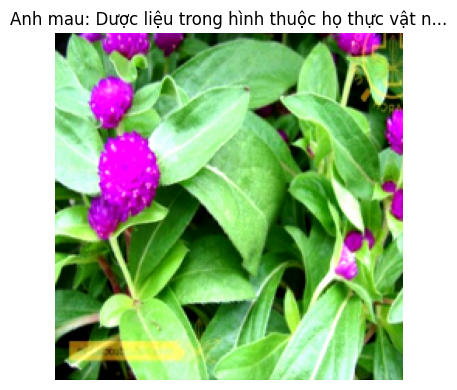

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Lấy một batch mẫu từ train_loader
batch = next(iter(train_loader))

print("Kiem tra shape cua tung tensor trong mot batch:")
print(f"  image          : {tuple(batch['image'].shape)}")
print(f"  input_ids      : {tuple(batch['input_ids'].shape)}")
print(f"  attention_mask : {tuple(batch['attention_mask'].shape)}")
print(f"  answer_ids     : {tuple(batch['answer_ids'].shape)}")
print(f"  answer_length  : {tuple(batch['answer_length'].shape)}")

# Kiểm tra giá trị hợp lệ
assert batch["image"].shape        == (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE), "Shape anh sai"
assert batch["input_ids"].shape    == (BATCH_SIZE, MAX_QUESTION_LEN),          "Shape input_ids sai"
assert batch["answer_ids"].shape   == (BATCH_SIZE, MAX_ANSWER_LEN),            "Shape answer_ids sai"
assert batch["image"].dtype        == torch.float32,                            "Kieu du lieu anh phai la float32"
assert batch["input_ids"].dtype    == torch.long,                               "Kieu du lieu input_ids phai la long"

print("\nTat ca assertion deu pass. Pipeline du lieu hoat dong dung.")

# Giai ma thu mot mau de kiem tra
idx        = 0
answer_ids = batch["answer_ids"][idx].tolist()
decoded    = vocab.decode(answer_ids)
q_ids      = batch["input_ids"][idx].tolist()
q_decoded  = phobert_tokenizer.decode(q_ids, skip_special_tokens=True)
ans_len    = batch["answer_length"][idx].item()

print(f"\nMau thu {idx + 1}:")
print(f"  Cau hoi (decoded)  : {q_decoded}")
print(f"  Cau tra loi        : {decoded}")
print(f"  Do dai thuc        : {ans_len} tokens")
print(f"  Gia tri pixel anh  — min: {batch['image'][idx].min():.3f}, max: {batch['image'][idx].max():.3f}")

# Kiem tra phan phoi token PAD / non-PAD trong answer_ids
all_ids    = batch["answer_ids"].flatten().tolist()
pad_ratio  = all_ids.count(PAD_ID) / len(all_ids) * 100
print(f"\nTy le token PAD trong answer batch: {pad_ratio:.1f}%")

# Hien thi anh dau tien trong batch
img_tensor = batch["image"][0]
mean       = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std        = torch.tensor(IMAGENET_STD).view(3, 1, 1)
img_show   = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_show)
plt.title(f"Anh mau: {q_decoded[:40]}...")
plt.axis("off")
plt.tight_layout()
plt.show()


---
## 4.Image Encoder (DINOv2)

Xây dựng lớp Image Encoder sử dụng DINOv2-base đã được huấn luyện trước (pretrained). Lưu ý:
- Load model từ HuggingFace (`facebook/dinov2-base`).
- Mặc định, toàn bộ trọng số của DINOv2 sẽ bị đóng băng (freeze) trong giai đoạn huấn luyện đầu.
- Hàm `forward` nhận vào một batch tensor ảnh và trả về:
  - `patch_embeddings`: các vector đặc trưng vùng ảnh kích thước (batch, so_patch, 768), dùng làm đầu vào cho Co-attention.
  - `cls_embedding`: vector đặc trưng toàn cục kích thước (batch, 768), có thể dùng khởi tạo trạng thái ẩn cho LSTM Decoder.
- Hàm `freeze` và `unfreeze` để chuyển đổi giữa hai giai đoạn huấn luyện.
- Hàm `unfreeze_last_n_blocks(n)` cho phép mở khoá n block cuối của ViT để fine-tune sau.

In [14]:
import torch
import torch.nn as nn
from transformers import AutoModel

class ImageEncoder(nn.Module):
    """
    Bộ mã hóa ảnh dựa trên DINOv2-base (ViT-B/14).
    Ảnh 224x224 được chia thành 256 patch (14x14 mỗi patch).
    Mặc định toàn bộ trọng số bị đóng băng trong giai đoạn huấn luyện đầu.
    """

    def __init__(self, model_name: str = DINOV2_MODEL_NAME):
        super().__init__()
        print(f"Đang tải DINOv2 từ '{model_name}'...")
        self.model = AutoModel.from_pretrained(model_name)
        # Đóng băng toàn bộ tham số ngay khi khởi tạo
        self.freeze()
        print("DINOv2 đã tải xong và đang ở chế độ đóng băng.")

    def forward(self, pixel_values: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Truyền xuôi qua DINOv2.

        Tham số:
            pixel_values: tensor ảnh, shape (batch, 3, 224, 224)

        Trả về:
            patch_embeddings: đặc trưng từng patch, shape (batch, 256, 768)
            cls_embedding   : đặc trưng toàn cục [CLS], shape (batch, 768)
        """
        output = self.model(pixel_values=pixel_values)
        # last_hidden_state: (batch, num_patches + 1, 768)
        # Token đầu tiên là [CLS], các token còn lại là patch embeddings
        hidden = output.last_hidden_state
        cls_embedding    = hidden[:, 0, :]    # (batch, 768)
        patch_embeddings = hidden[:, 1:, :]   # (batch, 256, 768)
        return patch_embeddings, cls_embedding

    def freeze(self) -> None:
        """Đóng băng toàn bộ tham số — dùng trong giai đoạn 1."""
        for param in self.model.parameters():
            param.requires_grad = False

    def unfreeze(self) -> None:
        """Mở khóa toàn bộ tham số — dùng khi muốn fine-tune toàn bộ."""
        for param in self.model.parameters():
            param.requires_grad = True

    def unfreeze_last_n_blocks(self, n: int) -> None:
        """
        Mở khóa n block transformer cuối cùng và lớp LayerNorm đầu ra.
        Dùng trong giai đoạn 2 để fine-tune một phần encoder.

        Tham số:
            n: số block cuối cần mở khóa (khuyến nghị: 2)
        """
        # Đóng băng lại toàn bộ trước để đảm bảo trạng thái sạch
        self.freeze()

        # Mở khóa n block cuối của ViT encoder
        encoder_layers = self.model.encoder.layer
        for block in encoder_layers[-n:]:
            for param in block.parameters():
                param.requires_grad = True

        # Mở khóa lớp LayerNorm cuối — ảnh hưởng trực tiếp đến đầu ra
        for param in self.model.layernorm.parameters():
            param.requires_grad = True

        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"Đã mở khóa {n} block cuối — {trainable:,} tham số có thể huấn luyện.")

    def num_trainable_params(self) -> int:
        """Trả về số tham số đang được huấn luyện."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def num_total_params(self) -> int:
        """Trả về tổng số tham số của encoder."""
        return sum(p.numel() for p in self.parameters())


# Khởi tạo và kiểm tra
image_encoder = ImageEncoder().to(DEVICE)

# Kiểm tra forward pass với ảnh giả
dummy_images        = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
patch_emb, cls_emb  = image_encoder(dummy_images)

print(f"\nKiem tra ImageEncoder:")
print(f"  Input shape          : {tuple(dummy_images.shape)}")
print(f"  patch_embeddings     : {tuple(patch_emb.shape)}")
print(f"  cls_embedding        : {tuple(cls_emb.shape)}")
print(f"  Tong tham so         : {image_encoder.num_total_params():,}")
print(f"  Tham so co the train : {image_encoder.num_trainable_params():,} (dang dong bang)")

# Kiem tra unfreeze_last_n_blocks
image_encoder.unfreeze_last_n_blocks(2)
print(f"  Sau unfreeze 2 block : {image_encoder.num_trainable_params():,} tham so co the train")

# Dong bang lai ve trang thai mac dinh cho giai doan 1
image_encoder.freeze()
print(f"  Dong bang lai        : {image_encoder.num_trainable_params():,} tham so co the train")


Đang tải DINOv2 từ 'facebook/dinov2-base'...


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 đã tải xong và đang ở chế độ đóng băng.

Kiem tra ImageEncoder:
  Input shape          : (2, 3, 224, 224)
  patch_embeddings     : (2, 256, 768)
  cls_embedding        : (2, 768)
  Tong tham so         : 86,580,480
  Tham so co the train : 0 (dang dong bang)
Đã mở khóa 2 block cuối — 14,180,352 tham số có thể huấn luyện.
  Sau unfreeze 2 block : 14,180,352 tham so co the train
  Dong bang lai        : 0 tham so co the train


---
## 5.Text Encoder (PhoBERT)

Xây dựng lớp Text Encoder sử dụng PhoBERT-base-v2 đã được huấn luyện trước trên tiếng Việt. Lưu ý:
- Load tokenizer và model từ HuggingFace (`vinai/phobert-base-v2`).
- Văn bản tiếng Việt được word-segment bằng VnCoreNLP trước khi tokenize.
- Mặc định, toàn bộ trọng số PhoBERT sẽ bị đóng băng trong giai đoạn huấn luyện đầu.
- Hàm `forward` nhận vào `input_ids` và `attention_mask`, trả về:
  - `token_embeddings`: vector đặc trưng của từng token kích thước (batch, do_dai, 768), dùng cho Co-attention.
  - `cls_embedding`: vector [CLS] đại diện cho toàn bộ câu hỏi kích thước (batch, 768).
- Tương tự Image Encoder, Text Encoder có hàm `freeze`, `unfreeze`, `unfreeze_last_n_layers(n)`.

In [15]:
import torch
import torch.nn as nn
from transformers import AutoModel

class TextEncoder(nn.Module):
    """
    Bộ mã hóa văn bản dựa trên PhoBERT-base-v2 (RoBERTa-base cho tiếng Việt).
    Nhận đầu vào là token IDs và attention mask từ PhoBERT tokenizer.
    Mặc định toàn bộ trọng số bị đóng băng trong giai đoạn huấn luyện đầu.
    """

    def __init__(self, model_name: str = PHOBERT_MODEL_NAME):
        super().__init__()
        print(f"Đang tải PhoBERT từ '{model_name}'...")
        self.model = AutoModel.from_pretrained(model_name)
        # Đóng băng toàn bộ tham số ngay khi khởi tạo
        self.freeze()
        print("PhoBERT đã tải xong và đang ở chế độ đóng băng.")

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Truyền xuôi qua PhoBERT.

        Tham số:
            input_ids      : chỉ số token, shape (batch, seq_len)
            attention_mask : mặt nạ attention, shape (batch, seq_len)

        Trả về:
            token_embeddings: đặc trưng từng token, shape (batch, seq_len, 768)
            cls_embedding   : đặc trưng [CLS] đại diện cả câu, shape (batch, 768)
        """
        output = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        # last_hidden_state: (batch, seq_len, 768)
        # Token đầu tiên ([CLS]) đại diện cho toàn bộ câu hỏi
        token_embeddings = output.last_hidden_state          # (batch, seq_len, 768)
        cls_embedding    = output.last_hidden_state[:, 0, :] # (batch, 768)
        return token_embeddings, cls_embedding

    def freeze(self) -> None:
        """Đóng băng toàn bộ tham số — dùng trong giai đoạn 1."""
        for param in self.model.parameters():
            param.requires_grad = False

    def unfreeze(self) -> None:
        """Mở khóa toàn bộ tham số — dùng khi muốn fine-tune toàn bộ."""
        for param in self.model.parameters():
            param.requires_grad = True

    def unfreeze_last_n_layers(self, n: int) -> None:
        """
        Mở khóa n lớp transformer cuối cùng và pooler.
        Dùng trong giai đoạn 2 để fine-tune một phần encoder.
        """
        self.freeze()
        # AutoModel trả về RobertaModel trực tiếp
        # nên encoder nằm ở self.model.encoder, không phải self.model.roberta.encoder
        encoder_layers = self.model.encoder.layer
        for layer in encoder_layers[-n:]:
            for param in layer.parameters():
                param.requires_grad = True
        # Mở khóa pooler nếu tồn tại
        if hasattr(self.model, "pooler") and self.model.pooler is not None:
            for param in self.model.pooler.parameters():
                param.requires_grad = True
        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"Đã mở khóa {n} lớp cuối PhoBERT — {trainable:,} tham số có thể huấn luyện.")

    def num_trainable_params(self) -> int:
        """Trả về số tham số đang được huấn luyện."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def num_total_params(self) -> int:
        """Trả về tổng số tham số của encoder."""
        return sum(p.numel() for p in self.parameters())


# Khởi tạo và kiểm tra
text_encoder = TextEncoder().to(DEVICE)

# Lấy một batch mẫu từ DataLoader để kiểm tra
sample_batch  = next(iter(train_loader))
input_ids     = sample_batch["input_ids"].to(DEVICE)
attention_mask = sample_batch["attention_mask"].to(DEVICE)

with torch.no_grad():
    token_emb, cls_emb = text_encoder(input_ids, attention_mask)

print(f"\nKiem tra TextEncoder:")
print(f"  Input shape (input_ids)   : {tuple(input_ids.shape)}")
print(f"  token_embeddings          : {tuple(token_emb.shape)}")
print(f"  cls_embedding             : {tuple(cls_emb.shape)}")
print(f"  Tong tham so              : {text_encoder.num_total_params():,}")
print(f"  Tham so co the train      : {text_encoder.num_trainable_params():,} (dang dong bang)")

# Kiem tra unfreeze_last_n_layers
text_encoder.unfreeze_last_n_layers(2)
print(f"  Sau unfreeze 2 lop        : {text_encoder.num_trainable_params():,} tham so co the train")

# Dong bang lai ve trang thai mac dinh cho giai doan 1
text_encoder.freeze()
print(f"  Dong bang lai             : {text_encoder.num_trainable_params():,} tham so co the train")


Đang tải PhoBERT từ 'vinai/phobert-base-v2'...


pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PhoBERT đã tải xong và đang ở chế độ đóng băng.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]


Kiem tra TextEncoder:
  Input shape (input_ids)   : (16, 64)
  token_embeddings          : (16, 64, 768)
  cls_embedding             : (16, 768)
  Tong tham so              : 134,998,272
  Tham so co the train      : 0 (dang dong bang)
Đã mở khóa 2 lớp cuối PhoBERT — 14,766,336 tham số có thể huấn luyện.
  Sau unfreeze 2 lop        : 14,766,336 tham so co the train
  Dong bang lai             : 0 tham so co the train


---
## 6.Co-attention Fusion Module

Xây dựng lớp Fusion theo cơ chế Co-attention: ảnh và văn bản sẽ chú ý lẫn nhau để tạo ra một vector tổng hợp mang thông tin của cả hai phía.

**Các bước thực hiện:**

**Bước 1 – Linear Projection:** Ép chiều đặc trưng từ 768 xuống 256 bằng các lớp Linear riêng biệt cho ảnh và văn bản. Bước này giảm lượng tính toán của Attention phía sau.

**Bước 2 – Image-guided Text Attention:** Dùng patch embedding của ảnh làm Query, token embedding của văn bản làm Key và Value. Attention này trả ra vector văn bản đã chú ý đến ảnh.

**Bước 3 – Text-guided Image Attention:** Ngược lại, dùng token embedding của văn bản làm Query, patch embedding của ảnh làm Key và Value. Attention này trả ra vector ảnh đã chú ý đến câu hỏi.

**Bước 4 – Tổng hợp:** Kết hợp hai đầu ra trên để tạo ra vector fusion cuối cùng. Đây là đầu vào cho Decoder.

In [16]:
import torch
import torch.nn as nn

class CoAttentionFusion(nn.Module):
    """
    Module hop nhat thong tin anh va van ban theo co che Co-attention.
    """

    def __init__(
        self,
        proj_dim: int       = PROJECTION_DIM,        # 256
        num_heads: int      = 4,
        dropout: float      = 0.1,
    ):
        super().__init__()

        # Buoc 1: chieu tuyen tinh
        self.img_proj  = nn.Linear(IMAGE_ENCODER_DIM, PROJECTION_DIM)
        self.text_proj = nn.Linear(TEXT_ENCODER_DIM, PROJECTION_DIM)

        # Buoc 2: Image-guided Text Attention
        self.img_guided_text_attn = nn.MultiheadAttention(
            embed_dim=proj_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )

        # Buoc 3: Text-guided Image Attention
        self.text_guided_img_attn = nn.MultiheadAttention(
            embed_dim=proj_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )

        # Chuan hoa sau attention
        self.norm_text_attn = nn.LayerNorm(proj_dim)
        self.norm_img_attn  = nn.LayerNorm(proj_dim)

        # Buoc 4: Tong hop
        self.fusion_proj = nn.Linear(proj_dim * 2, proj_dim)
        self.dropout     = nn.Dropout(dropout)

    def forward(
        self,
        patch_emb: torch.Tensor,
        token_emb: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        # Buoc 1: chieu tuyen tinh
        patch_proj = self.img_proj(patch_emb)
        token_proj = self.text_proj(token_emb)

        # Mask PAD token cho Key
        pad_mask = (attention_mask == 0)

        # Buoc 2: Image-guided Text Attention
        text_attn, _ = self.img_guided_text_attn(
            query=patch_proj,
            key=token_proj,
            value=token_proj,
            key_padding_mask=pad_mask,
        )
        text_attn = self.norm_text_attn(text_attn + patch_proj)

        # Buoc 3: Text-guided Image Attention
        img_attn, _ = self.text_guided_img_attn(
            query=token_proj,
            key=patch_proj,
            value=patch_proj,
        )
        img_attn = self.norm_img_attn(img_attn + token_proj)

        # Buoc 4: Tong hop bang MAX POOLING (Thay vi Mean pooling nhu cu)
        fusion_memory = text_attn

        # Dung max pooling de giu lai dac trung noi bat nhat (giup nhan dien dac diem cay co tot hon)
        patch_global = text_attn.max(dim=1)[0]
        token_global = img_attn.max(dim=1)[0]

        combined     = torch.cat([patch_global, token_global], dim=-1)
        fusion_cls   = self.dropout(torch.tanh(self.fusion_proj(combined)))

        return fusion_memory, fusion_cls


# ==========================================
# KHOI TAO VA KIEM TRA
# ==========================================
fusion_module = CoAttentionFusion().to(DEVICE)

# Tao dau vao gia
batch_size   = 2
num_patches  = (IMAGE_SIZE // 14) ** 2    # Tu dong tinh so patch theo IMAGE_SIZE moi
patch_emb    = torch.randn(batch_size, num_patches, IMAGE_ENCODER_DIM).to(DEVICE)
token_emb    = torch.randn(batch_size, MAX_QUESTION_LEN, TEXT_ENCODER_DIM).to(DEVICE)
attn_mask    = torch.ones(batch_size, MAX_QUESTION_LEN, dtype=torch.long).to(DEVICE)
attn_mask[:, -10:] = 0

with torch.no_grad():
    fusion_mem, fusion_cls = fusion_module(patch_emb, token_emb, attn_mask)

total_params = sum(p.numel() for p in fusion_module.parameters())

print("Kiem tra CoAttentionFusion:")
print(f"  patch_emb input   : {tuple(patch_emb.shape)}")
print(f"  token_emb input   : {tuple(token_emb.shape)}")
print(f"  fusion_memory     : {tuple(fusion_mem.shape)}")
print(f"  fusion_cls        : {tuple(fusion_cls.shape)}")
print(f"  Tong tham so      : {total_params:,}")
print("Co-attention Fusion Module da san sang.")


Kiem tra CoAttentionFusion:
  patch_emb input   : (2, 256, 768)
  token_emb input   : (2, 64, 768)
  fusion_memory     : (2, 256, 256)
  fusion_cls        : (2, 256)
  Tong tham so      : 1,052,416
Co-attention Fusion Module da san sang.


---
## 7.Answer Decoder A1 – LSTM (Baseline)

Xây dựng LSTM Decoder sinh câu trả lời theo từng token một.

**Cấu trúc:**
- Lớp Embedding: ánh xạ index token thành vector embedding.
- LSTM 2 lớp: trạng thái khởi đầu (h0, c0) được khởi tạo từ vector fusion.
- Bahdanau Attention: ở mỗi bước sinh, decoder tính trọng số chú ý trên các patch embedding để biết nên nhìn vào vùng nào của ảnh khi sinh token tiếp theo.
- Lớp Linear (output projection): chuyển trạng thái ẩn của LSTM thành phân phối xác suất trên toàn bộ vocabulary.

**Chế độ huấn luyện:**
- Sử dụng Teacher Forcing: ở mỗi bước đưa vào token ground-truth của bước trước thay vì token model vừa dự đoán.

**Chế độ suy luận (inference):**
- Sử dụng Beam Search (beam size = 5) để tìm chuỗi token có xác suất cao nhất.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    """
    Co che Bahdanau Attention — tinh trong so chu y cua LSTM hidden state
    len chuoi fusion_memory de tong hop vector ngu canh tai moi buoc sinh.
    """

    def __init__(self, hidden_dim: int, proj_dim: int, attn_dim: int = 256):
        super().__init__()
        self.W_h = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W_s = nn.Linear(proj_dim,   attn_dim, bias=False)
        self.v   = nn.Linear(attn_dim,   1,         bias=False)

    def forward(
        self,
        h: torch.Tensor,
        memory: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        h_exp  = self.W_h(h).unsqueeze(1)
        s_exp  = self.W_s(memory)
        score  = self.v(torch.tanh(h_exp + s_exp)).squeeze(-1)
        alpha  = torch.softmax(score, dim=-1)
        context = (alpha.unsqueeze(-1) * memory).sum(dim=1)
        return context, alpha


class LSTMDecoder(nn.Module):
    """
    LSTM Decoder 2 lop co ho tro Weight Tying voi PhoBERT vocabulary.
    """

    def __init__(
        self,
        vocab_size: int,
        proj_dim: int    = PROJECTION_DIM,
        emb_dim: int     = 768,              # Fix cung 768 de khop PhoBERT
        hidden_dim: int  = LSTM_HIDDEN_DIM,
        num_layers: int  = LSTM_NUM_LAYERS,
        dropout: float   = LSTM_DROPOUT,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.vocab_size = vocab_size

        # Lop embedding
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)

        self.init_h = nn.Linear(proj_dim, hidden_dim)
        self.init_c = nn.Linear(proj_dim, hidden_dim)

        self.attention = BahdanauAttention(hidden_dim, proj_dim)

        self.lstm = nn.LSTM(
            input_size=emb_dim + proj_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
        )

        # KY THUAT WEIGHT TYING
        # 1. Them lop chieu tu hidden_dim (512) len emb_dim (768)
        self.hidden_to_emb = nn.Linear(hidden_dim, emb_dim)

        # 2. Lop output tu 768 -> 64000 (khong dung bias vi embedding khong co bias)
        self.output_proj = nn.Linear(emb_dim, vocab_size, bias=False)
        self.dropout     = nn.Dropout(dropout)

        # 3. Chia se trong so voi embedding
        self.output_proj.weight = self.embedding.weight

    def _init_hidden(
        self, fusion_cls: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        h0 = torch.tanh(self.init_h(fusion_cls))
        c0 = torch.tanh(self.init_c(fusion_cls))
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = c0.unsqueeze(0).repeat(self.num_layers, 1, 1)
        return h0, c0

    def forward(
        self,
        fusion_memory: torch.Tensor,
        fusion_cls:    torch.Tensor,
        answer_ids:    torch.Tensor,
    ) -> torch.Tensor:
        batch_size, seq_len = answer_ids.shape
        h, c = self._init_hidden(fusion_cls)

        logits = []
        for t in range(seq_len - 1):
            emb = self.dropout(self.embedding(answer_ids[:, t]))

            h_top   = h[-1]
            context, _ = self.attention(h_top, fusion_memory)

            lstm_in          = torch.cat([emb, context], dim=-1).unsqueeze(1)
            out, (h, c)      = self.lstm(lstm_in, (h, c))

            # Thay doi do Weight Tying
            out_dropped      = self.dropout(out.squeeze(1))
            emb_space        = self.hidden_to_emb(out_dropped)
            logit            = self.output_proj(emb_space)

            logits.append(logit)

        return torch.stack(logits, dim=1)

    @torch.no_grad()
    def beam_search(
        self,
        fusion_memory: torch.Tensor,
        fusion_cls:    torch.Tensor,
        beam_size: int = 3,
        max_len:   int = MAX_ANSWER_LEN,
    ) -> list[int]:
        device = fusion_memory.device
        h, c   = self._init_hidden(fusion_cls)

        beams = [(0.0, [SOS_ID], h, c)]

        for _ in range(max_len):
            candidates = []
            for log_prob, tokens, h_b, c_b in beams:
                if tokens[-1] == EOS_ID:
                    candidates.append((log_prob, tokens, h_b, c_b))
                    continue

                token_tensor = torch.tensor([tokens[-1]], device=device)
                emb          = self.embedding(token_tensor)
                context, _   = self.attention(h_b[-1], fusion_memory)
                lstm_in      = torch.cat([emb, context], dim=-1).unsqueeze(1)
                out, (h_new, c_new) = self.lstm(lstm_in, (h_b, c_b))

                # Thay doi do Weight Tying
                emb_space    = self.hidden_to_emb(out.squeeze(1))
                logit        = self.output_proj(emb_space)

                log_probs    = F.log_softmax(logit, dim=-1).squeeze(0)

                topk_log_probs, topk_ids = log_probs.topk(beam_size)
                for lp, tid in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                    candidates.append((
                        log_prob + lp,
                        tokens + [tid],
                        h_new, c_new,
                    ))

            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_size]
            if all(b[1][-1] == EOS_ID for b in beams):
                break

        return beams[0][1]


# Khoi tao va kiem tra
lstm_decoder = LSTMDecoder(vocab_size=VOCAB_SIZE).to(DEVICE)

batch_size   = 2
fusion_mem   = torch.randn(batch_size, 256, PROJECTION_DIM).to(DEVICE)
fusion_vec   = torch.randn(batch_size, PROJECTION_DIM).to(DEVICE)
answer_ids   = torch.randint(0, VOCAB_SIZE, (batch_size, MAX_ANSWER_LEN)).to(DEVICE)

logits = lstm_decoder(fusion_mem, fusion_vec, answer_ids)
total_params = sum(p.numel() for p in lstm_decoder.parameters())

print("Kiem tra LSTMDecoder voi Weight Tying:")
print(f"  Logits output       : {tuple(logits.shape)}")
print(f"  Tong tham so (thuc) : {total_params:,}")
print("LSTMDecoder da san sang.")


Kiem tra LSTMDecoder voi Weight Tying:
  Logits output       : (2, 63, 5406)
  Tong tham so (thuc) : 10,256,896
LSTMDecoder da san sang.


---
## 8.Answer Decoder A2 – Transformer (Target)

Sử dụng Transformer Decoder để sinh câu trả lời. Toàn bộ Image Encoder, Text Encoder và Fusion Module được giữ nguyên y hệt cấu hình A1; chỉ thay thế duy nhất phần Decoder.

**Cấu trúc:**
- Lớp Embedding: tương tự A1.
- Positional Encoding: thêm thông tin vị trí vào chuỗi token.
- `nn.TransformerDecoder` với 2 đến 3 lớp, 4 attention heads. Mỗi lớp bao gồm:
  - Masked Self-Attention: đảm bảo token chỉ chú ý đến các token phía trước (tính nhân quả).
  - Cross-Attention: decoder chú ý đến vector fusion để tích hợp thông tin ảnh và câu hỏi.
  - Feed-Forward Network.
- Lớp Linear (output projection): tương tự A1.

**Hàm mất mát:**
- Sử dụng Label-Smoothed Cross-Entropy với epsilon = 0.1 để giảm overfit trên tập dữ liệu nhỏ.

**Chế độ suy luận:**
- Sinh từng token (autoregressive), hỗ trợ Beam Search.

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerDecoder(nn.Module):
    """
    Transformer Decoder sinh cau tra loi ho tro Weight Tying.
    """

    def __init__(
        self,
        vocab_size:  int,
        proj_dim:    int   = PROJECTION_DIM,
        emb_dim:     int   = 768,                       # Fix cung 768 de khop PhoBERT
        num_layers:  int   = TRANSFORMER_NUM_LAYERS,
        num_heads:   int   = TRANSFORMER_NUM_HEADS,
        ffn_dim:     int   = TRANSFORMER_FFN_DIM,
        dropout:     float = TRANSFORMER_DROPOUT,
    ):
        super().__init__()
        self.proj_dim   = proj_dim
        self.vocab_size = vocab_size

        self.embedding  = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.pos_enc    = PositionalEncoding(emb_dim, dropout)

        self.input_proj = (
            nn.Linear(emb_dim, proj_dim) if emb_dim != proj_dim else nn.Identity()
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=proj_dim,
            nhead=num_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # KY THUAT WEIGHT TYING
        self.hidden_to_emb = nn.Linear(proj_dim, emb_dim)
        self.output_proj = nn.Linear(emb_dim, vocab_size, bias=False)
        self.output_proj.weight = self.embedding.weight

    @staticmethod
    def _causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        return mask.bool()

    def forward(
        self,
        fusion_memory: torch.Tensor,
        fusion_cls:    torch.Tensor,
        answer_ids:    torch.Tensor,
    ) -> torch.Tensor:
        tgt_in   = answer_ids[:, :-1]
        seq_len  = tgt_in.size(1)
        device   = tgt_in.device

        tgt_emb = self.input_proj(self.pos_enc(self.embedding(tgt_in)))

        causal_mask = self._causal_mask(seq_len, device)
        pad_mask    = (tgt_in == PAD_ID)

        out = self.transformer(
            tgt=tgt_emb,
            memory=fusion_memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=pad_mask,
        )

        # Thay doi do Weight Tying
        emb_space = self.hidden_to_emb(out)
        return self.output_proj(emb_space)

    @torch.no_grad()
    def beam_search(
        self,
        fusion_memory: torch.Tensor,
        fusion_cls:    torch.Tensor,
        beam_size: int = 3,
        max_len:   int = MAX_ANSWER_LEN,
    ) -> list[int]:
        device = fusion_memory.device
        beams = [(0.0, [SOS_ID])]

        for _ in range(max_len):
            candidates = []
            for log_prob, tokens in beams:
                if tokens[-1] == EOS_ID:
                    candidates.append((log_prob, tokens))
                    continue

                tgt_tensor = torch.tensor(tokens, device=device).unsqueeze(0)
                tgt_emb    = self.input_proj(self.pos_enc(self.embedding(tgt_tensor)))
                causal_mask= self._causal_mask(tgt_tensor.size(1), device)

                out = self.transformer(
                    tgt=tgt_emb,
                    memory=fusion_memory,
                    tgt_mask=causal_mask,
                )

                # Thay doi do Weight Tying
                out_last     = out[:, -1, :]
                emb_space    = self.hidden_to_emb(out_last)
                logit        = self.output_proj(emb_space)

                log_probs    = F.log_softmax(logit, dim=-1).squeeze(0)

                topk_log_probs, topk_ids = log_probs.topk(beam_size)
                for lp, tid in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                    candidates.append((
                        log_prob + lp,
                        tokens + [tid],
                    ))

            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_size]
            if all(b[1][-1] == EOS_ID for b in beams):
                break

        return beams[0][1]


# Khoi tao va kiem tra
transformer_decoder = TransformerDecoder(vocab_size=VOCAB_SIZE).to(DEVICE)

logits = transformer_decoder(fusion_mem, fusion_vec, answer_ids)
total_params = sum(p.numel() for p in transformer_decoder.parameters())

print("Kiem tra TransformerDecoder voi Weight Tying:")
print(f"  Logits output       : {tuple(logits.shape)}")
print(f"  Tong tham so (thuc) : {total_params:,}")
print("TransformerDecoder da san sang.")


Kiem tra TransformerDecoder voi Weight Tying:
  Logits output       : (2, 63, 5406)
  Tong tham so (thuc) : 6,127,616
TransformerDecoder da san sang.


---
## 9.Mô hình VQA tổng thể

Gộp các thành phần lại thành một lớp mô hình VQA hoàn chỉnh. Lớp này nhận tham số `decoder_type` với giá trị `'lstm'` hoặc `'transformer'` để lựa chọn decoder tương ứng, giúp việc chuyển đổi giữa A1 và A2 trở nên đơn giản.

Hàm `forward` xử lý đầy đủ luồng dữ liệu:
1. Ảnh qua Image Encoder ra patch embeddings.
2. Câu hỏi qua Text Encoder ra token embeddings.
3. Hai đặc trưng trên qua Fusion Module ra vector fusion.
4. Vector fusion cùng chuỗi câu trả lời (lúc train) đưa vào Decoder, trả về logits.


In [19]:
import torch
import torch.nn as nn

class VQAModel(nn.Module):
    """
    Mô hình VQA hoàn chỉnh — gộp toàn bộ thành phần thành một pipeline duy nhất.

    Luồng dữ liệu:
        ảnh  → ImageEncoder   → patch_embeddings, cls_img
        câu hỏi → TextEncoder → token_embeddings, cls_txt
        patch_embeddings + token_embeddings → CoAttentionFusion → fusion_memory, fusion_cls
        fusion_memory + fusion_cls + answer_ids → Decoder → logits

    Tham số:
        decoder_type: 'lstm' hoặc 'transformer' — chọn kiến trúc decoder.
    """

    def __init__(self, vocab_size: int, decoder_type: str = "transformer"):
        super().__init__()
        assert decoder_type in ("lstm", "transformer"), \
            f"decoder_type phai la 'lstm' hoac 'transformer', nhan: '{decoder_type}'"

        self.decoder_type = decoder_type

        # Bộ mã hóa ảnh — DINOv2-base, mặc định đóng băng
        self.image_encoder = ImageEncoder()

        # Bộ mã hóa văn bản — PhoBERT-base-v2, mặc định đóng băng
        self.text_encoder  = TextEncoder()

        # Module hợp nhất Co-attention
        self.fusion        = CoAttentionFusion()

        # Decoder — chọn theo decoder_type
        if decoder_type == "lstm":
            self.decoder = LSTMDecoder(vocab_size=vocab_size)
        else:
            self.decoder = TransformerDecoder(vocab_size=vocab_size)

    def forward(
        self,
        pixel_values:   torch.Tensor,   # (batch, 3, 224, 224)
        input_ids:      torch.Tensor,   # (batch, seq_len)
        attention_mask: torch.Tensor,   # (batch, seq_len)
        answer_ids:     torch.Tensor,   # (batch, T)
    ) -> torch.Tensor:
        """
        Truyền xuôi toàn bộ pipeline (chế độ huấn luyện — Teacher Forcing).
        Trả về logits: (batch, T-1, vocab_size).
        """
        # Bước 1: mã hóa ảnh
        patch_emb, _ = self.image_encoder(pixel_values)
        # patch_emb: (batch, 256, 768)

        # Bước 2: mã hóa văn bản
        token_emb, _ = self.text_encoder(input_ids, attention_mask)
        # token_emb: (batch, seq_len, 768)

        # Bước 3: hợp nhất Co-attention
        fusion_memory, fusion_cls = self.fusion(patch_emb, token_emb, attention_mask)
        # fusion_memory: (batch, 256, 256), fusion_cls: (batch, 256)

        # Bước 4: giải mã câu trả lời
        logits = self.decoder(fusion_memory, fusion_cls, answer_ids)
        # logits: (batch, T-1, vocab_size)

        return logits

    @torch.no_grad()
    def predict(
        self,
        pixel_values:   torch.Tensor,   # (1, 3, 224, 224)
        input_ids:      torch.Tensor,   # (1, seq_len)
        attention_mask: torch.Tensor,   # (1, seq_len)
        beam_size: int = 3,
    ) -> list[int]:
        """
        Sinh câu trả lời cho một mẫu đơn lẻ bằng Beam Search (chế độ suy luận).
        Trả về chuỗi chỉ số token.
        """
        self.eval()
        patch_emb, _          = self.image_encoder(pixel_values)
        token_emb, _          = self.text_encoder(input_ids, attention_mask)
        fusion_memory, fusion_cls = self.fusion(patch_emb, token_emb, attention_mask)
        return self.decoder.beam_search(fusion_memory, fusion_cls, beam_size=beam_size)

    # Các hàm tiện ích — freeze / unfreeze encoder

    def freeze_encoders(self) -> None:
        """Đóng băng cả hai encoder — dùng cho giai đoạn 1."""
        self.image_encoder.freeze()
        self.text_encoder.freeze()

    def unfreeze_encoders_partial(self, n_img_blocks: int = 2, n_txt_layers: int = 2) -> None:
        """Mở khóa một phần encoder — dùng cho giai đoạn 2."""
        self.image_encoder.unfreeze_last_n_blocks(n_img_blocks)
        self.text_encoder.unfreeze_last_n_layers(n_txt_layers)

    def count_params(self) -> dict:
        """Thống kê số tham số theo từng thành phần."""
        def _count(module):
            total     = sum(p.numel() for p in module.parameters())
            trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
            return total, trainable

        parts = {
            "ImageEncoder":  self.image_encoder,
            "TextEncoder":   self.text_encoder,
            "Fusion":        self.fusion,
            "Decoder":       self.decoder,
        }
        result = {}
        grand_total = grand_train = 0
        for name, mod in parts.items():
            t, tr = _count(mod)
            result[name] = {"total": t, "trainable": tr}
            grand_total += t
            grand_train += tr
        result["TOTAL"] = {"total": grand_total, "trainable": grand_train}
        return result


# ==========================================
# KHỞI TẠO CẢ HAI PHIÊN BẢN (A1 VÀ A2)
# ==========================================
vqa_a1 = VQAModel(vocab_size=VOCAB_SIZE, decoder_type="lstm").to(DEVICE)
vqa_a2 = VQAModel(vocab_size=VOCAB_SIZE, decoder_type="transformer").to(DEVICE)

# Đóng băng encoder theo mặc định (giai đoạn 1)
vqa_a1.freeze_encoders()
vqa_a2.freeze_encoders()

# Kích hoạt Multi-GPU bằng DataParallel
# if torch.cuda.device_count() > 1:
#     print(f"\nDang su dung {torch.cuda.device_count()} GPUs voi DataParallel!")
#     vqa_a1 = nn.DataParallel(vqa_a1)
#     vqa_a2 = nn.DataParallel(vqa_a2)

# In thống kê tham số
for name, model in [("A1 (LSTM)", vqa_a1), ("A2 (Transformer)", vqa_a2)]:
    actual_model = model.module if isinstance(model, nn.DataParallel) else model
    stats = actual_model.count_params()

    print(f"\nMo hinh {name}:")
    print(f"  {'Thanh phan':<20} {'Tong':>12} {'Co the train':>15}")
    print(f"  {'-'*50}")
    for part, val in stats.items():
        trainable_str = f"{val['trainable']:,}" if val['trainable'] > 0 else "0 (dong bang)"
        print(f"  {part:<20} {val['total']:>12,} {trainable_str:>15}")

# Kiem tra forward pass
sample_batch    = next(iter(train_loader))
pixel_values    = sample_batch["image"].to(DEVICE)
input_ids       = sample_batch["input_ids"].to(DEVICE)
attention_mask  = sample_batch["attention_mask"].to(DEVICE)
answer_ids      = sample_batch["answer_ids"].to(DEVICE)

with torch.no_grad():
    logits_a1 = vqa_a1(pixel_values, input_ids, attention_mask, answer_ids)
    logits_a2 = vqa_a2(pixel_values, input_ids, attention_mask, answer_ids)

print(f"\nKiem tra forward pass:")
print(f"  Input pixel_values  : {tuple(pixel_values.shape)}")
print(f"  A1 logits output    : {tuple(logits_a1.shape)}")
print(f"  A2 logits output    : {tuple(logits_a2.shape)}")
print("Mo hinh VQA tong the da san sang.")




Đang tải DINOv2 từ 'facebook/dinov2-base'...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 đã tải xong và đang ở chế độ đóng băng.
Đang tải PhoBERT từ 'vinai/phobert-base-v2'...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 đã tải xong và đang ở chế độ đóng băng.
Đang tải PhoBERT từ 'vinai/phobert-base-v2'...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PhoBERT đã tải xong và đang ở chế độ đóng băng.

Mo hinh A1 (LSTM):
  Thanh phan                   Tong    Co the train
  --------------------------------------------------
  ImageEncoder           86,580,480   0 (dong bang)
  TextEncoder           134,998,272   0 (dong bang)
  Fusion                  1,052,416       1,052,416
  Decoder                10,256,896      10,256,896
  TOTAL                 232,888,064      11,309,312

Mo hinh A2 (Transformer):
  Thanh phan                   Tong    Co the train
  --------------------------------------------------
  ImageEncoder           86,580,480   0 (dong bang)
  TextEncoder           134,998,272   0 (dong bang)
  Fusion                  1,052,416       1,052,416
  Decoder                 6,127,616       6,127,616
  TOTAL                 228,758,784       7,180,032

Kiem tra forward pass:
  Input pixel_values  : (16, 3, 224, 224)
  A1 logits output    : (16, 63, 5406)
  A2 logits output    : (16, 63, 5406)
Mo hinh VQA tong the da san san

---
## 10.Training Pipeline

Phần này xây dựng toàn bộ quy trình huấn luyện, bao gồm các hàm tiện ích và vòng lặp chính.

### 10.1. Hàm tính mất mát (Loss Function)

Định nghĩa hàm Label-Smoothed Cross-Entropy. Hàm này cần bỏ qua các vị trí padding (ignore_index = PAD_ID) khi tính toán mất mát, đảm bảo gradient không bị ảnh hưởng bởi các token đệm.

In [20]:
import torch
import torch.nn as nn

class LabelSmoothedCrossEntropy(nn.Module):
    """
    Sử dụng hàm CrossEntropyLoss tích hợp sẵn của PyTorch để xử lý Label Smoothing.
    Phiên bản này được biên dịch bằng C++ giúp TỐI ƯU HÓA cực kỳ tốt bộ nhớ VRAM,
    tiết kiệm ~500MB VRAM do không sinh ra các ma trận tính toán nháp.
    """
    def __init__(
        self,
        vocab_size:    int,
        epsilon:       float = LABEL_SMOOTHING,
        ignore_index:  int   = PAD_ID,
    ):
        super().__init__()
        # Dùng module chuẩn của PyTorch
        self.loss_fn = nn.CrossEntropyLoss(
            label_smoothing=epsilon,
            ignore_index=ignore_index
        )

    def forward(
        self,
        logits:  torch.Tensor,   # (batch, T-1, vocab_size)
        targets: torch.Tensor,   # (batch, T-1)
    ) -> torch.Tensor:
        # Căn phẳng ma trận để đưa vào hàm loss
        vocab_size = logits.size(-1)
        loss = self.loss_fn(logits.reshape(-1, vocab_size), targets.reshape(-1))
        return loss

# Khởi tạo hàm loss
criterion = LabelSmoothedCrossEntropy(vocab_size=VOCAB_SIZE).to(DEVICE)

# Kiểm tra nhanh
batch_size  = 4
seq_len     = MAX_ANSWER_LEN - 1
fake_logits = torch.randn(batch_size, seq_len, VOCAB_SIZE).to(DEVICE)
fake_targets = torch.randint(0, VOCAB_SIZE, (batch_size, seq_len)).to(DEVICE)
fake_targets[:, -10:] = PAD_ID

loss_val = criterion(fake_logits, fake_targets)
print("Kiem tra LabelSmoothedCrossEntropy toi uu bo nho:")
print(f"  Loss: {loss_val.item():.4f}")
print("Ham loss da san sang.")


Kiem tra LabelSmoothedCrossEntropy toi uu bo nho:
  Loss: 9.1430
Ham loss da san sang.


### 10.2. Cấu hình Optimizer và Scheduler

Khởi tạo Optimizer và Learning Rate Scheduler cho từng giai đoạn:

**Giai đoạn 1 (Freeze Encoder):** Chỉ các tham số của Fusion Module và Decoder tham gia tối ưu hoá. Dùng AdamW với learning rate khoảng 1e-4.

**Giai đoạn 2 (Unfreeze một phần Encoder):** Toàn bộ mô hình tham gia tối ưu hoá với learning rate rất nhỏ (khoảng 1e-5) để tránh phá vỡ trọng số pretrained.

Đặt Cosine Annealing Scheduler kèm theo Linear Warmup.

In [21]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup

def build_optimizer_phase1(model: nn.Module, num_training_steps: int):
    """
    Cấu hình optimizer và scheduler cho Giai đoạn 1.
    Encoder bị đóng băng — chỉ tối ưu Fusion và Decoder.
    """
    # Xử lý trường hợp mô hình bị bọc bởi DataParallel
    actual_model = model.module if isinstance(model, nn.DataParallel) else model

    # Chỉ lấy tham số của Fusion và Decoder
    trainable_params = [
        p for p in list(actual_model.fusion.parameters()) + list(actual_model.decoder.parameters())
        if p.requires_grad
    ]

    optimizer = AdamW(
        trainable_params,
        lr=LR_PHASE1,
        weight_decay=0.05,
        betas=(0.9, 0.98),
        eps=1e-8,
    )

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=WARMUP_STEPS,
        num_training_steps=num_training_steps,
    )

    return optimizer, scheduler


def build_optimizer_phase2(model: nn.Module, num_training_steps: int):
    """
    Cấu hình optimizer và scheduler cho Giai đoạn 2.
    """
    actual_model = model.module if isinstance(model, nn.DataParallel) else model

    # Nhóm tham số encoder được unfreeze — học rất chậm
    encoder_params = [
        p for p in (
            list(actual_model.image_encoder.parameters()) +
            list(actual_model.text_encoder.parameters())
        )
        if p.requires_grad
    ]

    # Nhóm tham số Fusion và Decoder — học nhanh hơn encoder một chút
    head_params = [
        p for p in list(actual_model.fusion.parameters()) + list(actual_model.decoder.parameters())
        if p.requires_grad
    ]

    param_groups = [
        {"params": encoder_params, "lr": LR_PHASE2 * 0.1},
        {"params": head_params,    "lr": LR_PHASE2},
    ]

    optimizer = AdamW(
        param_groups,
        weight_decay=0.05, # TĂNG lên 0.05 tương tự Phase 1
        betas=(0.9, 0.98),
        eps=1e-8,
    )

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=WARMUP_STEPS // 2,   # warmup ngắn hơn ở giai đoạn 2
        num_training_steps=num_training_steps,
    )

    return optimizer, scheduler


# ==========================================
# KHỞI TẠO VÀ KIỂM TRA
# ==========================================
# Tính tổng số bước huấn luyện cho mỗi giai đoạn
steps_per_epoch_p1 = len(train_loader) // GRAD_ACCUMULATION
steps_per_epoch_p2 = len(train_loader) // GRAD_ACCUMULATION

total_steps_p1 = steps_per_epoch_p1 * EPOCHS_PHASE1
total_steps_p2 = steps_per_epoch_p2 * EPOCHS_PHASE2

# Lấy actual model ra để truy cập được các hàm tuỳ chỉnh
actual_vqa_a2 = vqa_a2.module if isinstance(vqa_a2, nn.DataParallel) else vqa_a2

# Kiểm tra với model A2 (Transformer)
optimizer_p1, scheduler_p1 = build_optimizer_phase1(vqa_a2, total_steps_p1)

# Tạm thời unfreeze để kiểm tra phase 2
actual_vqa_a2.unfreeze_encoders_partial(n_img_blocks=2, n_txt_layers=2)
optimizer_p2, scheduler_p2 = build_optimizer_phase2(vqa_a2, total_steps_p2)
actual_vqa_a2.freeze_encoders()   # Đóng băng lại cho giai đoạn 1

print("Thong so Optimizer:")
print(f"  Giai doan 1:")
print(f"    Tong buoc train  : {total_steps_p1:,} ({EPOCHS_PHASE1} epoch x {steps_per_epoch_p1} buoc)")
print(f"    Warmup steps     : {WARMUP_STEPS}")
print(f"    LR               : {LR_PHASE1}")
print(f"    So nhom tham so  : {len(optimizer_p1.param_groups)}")
p1_count = sum(p.numel() for g in optimizer_p1.param_groups for p in g["params"])
print(f"    Tham so toi uu   : {p1_count:,}")

print(f"\n  Giai doan 2:")
print(f"    Tong buoc train  : {total_steps_p2:,} ({EPOCHS_PHASE2} epoch x {steps_per_epoch_p2} buoc)")
print(f"    Warmup steps     : {WARMUP_STEPS // 2}")
print(f"    LR encoder       : {LR_PHASE2 * 0.1:.2e}")
print(f"    LR fusion/dec    : {LR_PHASE2:.2e}")
print(f"    So nhom tham so  : {len(optimizer_p2.param_groups)}")

# Mô phỏng lịch học (LR schedule) 3 bước đầu
print("\nKiem tra LR schedule (3 buoc dau):")
for step in range(3):
    print(f"  Buoc {step + 1}: LR = {scheduler_p1.get_last_lr()}")
    optimizer_p1.step()
    scheduler_p1.step()

print("Optimizer va Scheduler da san sang.")


Đã mở khóa 2 block cuối — 14,180,352 tham số có thể huấn luyện.
Đã mở khóa 2 lớp cuối PhoBERT — 14,766,336 tham số có thể huấn luyện.
Thong so Optimizer:
  Giai doan 1:
    Tong buoc train  : 5,700 (10 epoch x 570 buoc)
    Warmup steps     : 150
    LR               : 0.0001
    So nhom tham so  : 1
    Tham so toi uu   : 7,180,032

  Giai doan 2:
    Tong buoc train  : 5,700 (10 epoch x 570 buoc)
    Warmup steps     : 75
    LR encoder       : 5.00e-06
    LR fusion/dec    : 5.00e-05
    So nhom tham so  : 2

Kiem tra LR schedule (3 buoc dau):
  Buoc 1: LR = [0.0]
  Buoc 2: LR = [6.666666666666667e-07]
  Buoc 3: LR = [1.3333333333333334e-06]
Optimizer va Scheduler da san sang.


### 10.3. Hàm train một epoch

Hàm này có tích hợp:
- `torch.cuda.amp.autocast()` cho Mixed Precision Training (fp16) để giảm VRAM và tăng tốc độ.
- `GradScaler` kèm theo `autocast` để giữ ổn định số học với fp16.
- Gradient Accumulation: chỉ gọi `optimizer.step()` sau mỗi N bước tích luỹ (N được đặt trong cấu hình), sau đó zero grad.
- Gradient Clipping (`torch.nn.utils.clip_grad_norm_`) để tránh gradient exploding.
- Trả về mất mát trung bình trên toàn bộ epoch.

In [23]:
import time
import torch
from torch.amp import GradScaler, autocast

def train_one_epoch(
    model:      VQAModel,
    loader:     torch.utils.data.DataLoader,
    optimizer:  torch.optim.Optimizer,
    scheduler,
    criterion:  LabelSmoothedCrossEntropy,
    scaler:     GradScaler,
    epoch:      int,
    device:     torch.device = DEVICE,
) -> float:
    """
    Huấn luyện mô hình qua một epoch với:
      - Mixed Precision (fp16) để giảm VRAM và tăng tốc.
      - Gradient Accumulation để mô phỏng batch size lớn hơn.
      - Gradient Clipping để tránh gradient exploding.

    Trả về: loss trung bình trên toàn bộ epoch.
    """
    model.train()
    optimizer.zero_grad()

    total_loss    = 0.0
    num_updates   = 0       # số lần thực sự cập nhật tham số
    epoch_start   = time.time()

    for step, batch in enumerate(loader, start=1):
        # Chuyển toàn bộ tensor sang device
        pixel_values   = batch["image"].to(device, non_blocking=True)
        input_ids      = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        answer_ids     = batch["answer_ids"].to(device, non_blocking=True)

        # Mixed Precision forward pass
        with autocast("cuda", dtype=torch.float16):
            logits  = model(pixel_values, input_ids, attention_mask, answer_ids)
            # Mục tiêu: answer_ids[:, 1:] (bỏ SOS, giữ từ đầu tiên đến EOS + PAD)
            targets = answer_ids[:, 1:]
            loss    = criterion(logits, targets)
            # Chia loss cho số bước tích lũy để giữ gradient scale đúng
            loss_scaled = loss / GRAD_ACCUMULATION

        # Backward pass qua scaler để ổn định số học fp16
        scaler.scale(loss_scaled).backward()

        total_loss += loss.item()

        # Cập nhật tham số sau mỗi GRAD_ACCUMULATION bước
        if step % GRAD_ACCUMULATION == 0:
            # Bỏ scale gradient trước khi clip để clip đúng giá trị thực
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                (p for p in model.parameters() if p.requires_grad),
                max_norm=GRAD_CLIP_NORM,
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            num_updates += 1

        # In tiến trình mỗi 50 bước tích lũy (tương đương 200 batch)
        if step % (GRAD_ACCUMULATION * 50) == 0 or step == len(loader):
            elapsed      = time.time() - epoch_start
            batches_left = len(loader) - step
            eta_sec      = elapsed / step * batches_left
            avg_loss     = total_loss / step
            current_lr   = scheduler.get_last_lr()[0]

            print(
                f"  Epoch {epoch} | "
                f"Batch {step:>5}/{len(loader)} | "
                f"Loss: {avg_loss:.4f} | "
                f"LR: {current_lr:.2e} | "
                f"ETA epoch: {_fmt_time(eta_sec)}"
            )

    # Xử lý phần dư nếu tổng batch không chia hết cho GRAD_ACCUMULATION
    remainder = len(loader) % GRAD_ACCUMULATION
    if remainder != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            (p for p in model.parameters() if p.requires_grad),
            max_norm=GRAD_CLIP_NORM,
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad()

    epoch_time = time.time() - epoch_start
    avg_loss   = total_loss / len(loader)

    print(
        f"  Epoch {epoch} ket thuc | "
        f"Loss TB: {avg_loss:.4f} | "
        f"Thoi gian: {_fmt_time(epoch_time)} | "
        f"Cap nhat: {num_updates} lan"
    )

    return avg_loss


def _fmt_time(seconds: float) -> str:
    """Chuyển số giây thành chuỗi mm:ss hoặc hh:mm:ss."""
    seconds = int(seconds)
    if seconds < 3600:
        return f"{seconds // 60:02d}:{seconds % 60:02d}"
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


# Khởi tạo GradScaler — dùng chung cho toàn bộ quá trình train
scaler = GradScaler("cuda")

print("Ham train_one_epoch da san sang.")
print(f"  Gradient accumulation : {GRAD_ACCUMULATION} buoc")
print(f"  Batch size hieu dung  : {BATCH_SIZE * GRAD_ACCUMULATION}")
print(f"  Grad clip norm        : {GRAD_CLIP_NORM}")
print(f"  Mixed Precision       : fp16 (autocast)")


Ham train_one_epoch da san sang.
  Gradient accumulation : 2 buoc
  Batch size hieu dung  : 32
  Grad clip norm        : 1.0
  Mixed Precision       : fp16 (autocast)


### 10.4. Hàm đánh giá trên tập validation

Hàm chạy mô hình ở chế độ `eval()` (tắt Dropout và BatchNorm) trên tập validation. Mô hình sinh câu trả lời theo chế độ suy luận (Beam Search), không dùng Teacher Forcing. Tính các metric đánh giá cơ bản (BLEU-4, ROUGE-L, VQA Accuracy) để theo dõi quá trình huấn luyện và chọn checkpoint tốt nhất.

In [24]:
import torch
import time
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

def normalize_answer(text: str) -> str:
    """Chuan hoa cau tra loi — chu thuong, bo dau cau, xoa gach duoi PhoBERT."""
    text = text.lower().strip().rstrip(".,!?;:")
    return text.replace("_", " ").strip()


def evaluate(
    model:     torch.nn.Module,
    loader:    torch.utils.data.DataLoader,
    answer_vocab,
    criterion  = None,          # Truyen vao de tinh val_loss (None = bo qua)
    beam_size: int = 1,
    device:    torch.device = DEVICE,
) -> dict:
    """
    Danh gia mo hinh tren mot tap du lieu.
    Tra ve: bleu4, rouge_l, vqa_acc, va val_loss (neu co criterion).
    Su dung ham nay thong nhat cho ca val (luc train) lan test (muc 11).
    """
    actual_model = model.module if isinstance(model, torch.nn.DataParallel) else model
    actual_model.eval()

    rouge  = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
    smooth = SmoothingFunction().method4   # Method4 chuan xac hon method1

    all_refs   = []
    all_hyps   = []
    exact_hits = 0
    total      = 0
    total_loss = 0.0
    eval_start = time.time()

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader, start=1):
            pixel_values   = batch["image"].to(device, non_blocking=True)
            input_ids      = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            answer_ids     = batch["answer_ids"].to(device, non_blocking=True)

            # 1. Tinh Val Loss neu co criterion (dung cho viec chon checkpoint)
            if criterion is not None:
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    logits  = model(pixel_values, input_ids, attention_mask, answer_ids)
                    targets = answer_ids[:, 1:]
                    loss    = criterion(logits, targets)
                total_loss += loss.item()

            # 2. Sinh cau tra loi bang Beam Search de tinh metric
            answer_ids_cpu = answer_ids.cpu()
            batch_size = pixel_values.size(0)
            for i in range(batch_size):
                pred_ids = actual_model.predict(
                    pixel_values[i:i+1], input_ids[i:i+1], attention_mask[i:i+1],
                    beam_size=beam_size,
                )
                pred_text = answer_vocab.decode(pred_ids)
                ref_text  = answer_vocab.decode(answer_ids_cpu[i].tolist())

                pred_norm = normalize_answer(pred_text)
                ref_norm  = normalize_answer(ref_text)

                all_hyps.append(pred_norm.split())
                all_refs.append([ref_norm.split()])

                if pred_norm == ref_norm:
                    exact_hits += 1
                total += 1

            if batch_idx % 20 == 0 or batch_idx == len(loader):
                elapsed = time.time() - eval_start
                print(f"  Eval {batch_idx:>4}/{len(loader)} | {_fmt_time(elapsed)}")

    # Tinh cac metric
    bleu4 = corpus_bleu(all_refs, all_hyps,
                        weights=(0.25, 0.25, 0.25, 0.25),
                        smoothing_function=smooth)

    rouge_l_scores = [
        rouge.score(" ".join(ref[0]), " ".join(hyp))["rougeL"].fmeasure
        for ref, hyp in zip(all_refs, all_hyps)
    ]
    rouge_l = sum(rouge_l_scores) / len(rouge_l_scores) if rouge_l_scores else 0.0
    vqa_acc = exact_hits / total if total > 0 else 0.0
    val_loss = total_loss / len(loader) if criterion is not None else None

    elapsed_total = time.time() - eval_start
    print(f"\n  Ket qua danh gia ({total} mau | {_fmt_time(elapsed_total)}):")
    if val_loss is not None:
        print(f"    Val Loss  : {val_loss:.4f}  <- Tieu chi chon checkpoint")
    print(f"    BLEU-4    : {bleu4:.4f}")
    print(f"    ROUGE-L   : {rouge_l:.4f}")
    print(f"    VQA Acc   : {vqa_acc:.4f}  ({exact_hits}/{total})")

    return {
        "val_loss": val_loss,
        "bleu4":    bleu4,
        "rouge_l":  rouge_l,
        "vqa_acc":  vqa_acc,
    }


# Kiem tra nhanh
print("Kiem tra ham evaluate (2 batch dau)...")
mini_val = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class _LimitLoader:
    def __init__(self, loader, n): self.loader = loader; self.n = n
    def __iter__(self): return (b for i, b in enumerate(self.loader) if i < self.n)
    def __len__(self): return self.n

mini_result = evaluate(vqa_a1, _LimitLoader(mini_val, 2), answer_vocab, criterion=criterion, beam_size=1)
print(f"\nKiem tra thanh cong. Ham evaluate da san sang.")



Kiem tra ham evaluate (2 batch dau)...
  Eval    2/2 | 00:03

  Ket qua danh gia (32 mau | 00:17):
    Val Loss  : 9.3328  <- Tieu chi chon checkpoint
    BLEU-4    : 0.0003
    ROUGE-L   : 0.0427
    VQA Acc   : 0.0000  (0/32)

Kiem tra thanh cong. Ham evaluate da san sang.


### 10.5. Vòng lặp huấn luyện – Giai đoạn 1 (Freeze Encoder)

Chạy vòng lặp huấn luyện chính cho Giai đoạn 1:
- Đóng băng toàn bộ DINOv2 và PhoBERT.
- Chạy 10 epoch, chỉ huấn luyện Fusion Module và Decoder.
- Sau mỗi epoch, chạy hàm đánh giá validation và in kết quả.
- Lưu checkpoint của epoch có kết quả validation tốt nhất (Early Stopping dựa trên BLEU trên val).
- Vẽ biểu đồ mất mát train và val theo epoch để kiểm tra hội tụ.

In [ ]:
import os
import time
import pickle
import torch
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download, HfApi
from collections import OrderedDict

def save_checkpoint(model, optimizer, scheduler, epoch, metrics, train_losses, val_bleus, patience_count, path, tag="best"):
    """Lưu checkpoint và các biến trạng thái xuống local, đẩy lên HuggingFace Hub."""
    actual_model = model.module if isinstance(model, torch.nn.DataParallel) else model
    state = {
        "epoch":          epoch,
        "metrics":        metrics,
        "model":          model.state_dict(),
        "optimizer":      optimizer.state_dict(),
        "scheduler":      scheduler.state_dict(),
        "decoder_type":   actual_model.decoder_type,
        "train_losses":   train_losses,
        "val_bleus":      val_bleus,
        "patience_count": patience_count
    }
    torch.save(state, path)
    print(f"  Checkpoint luu tai: {path}")

    if not HF_HUB_TOKEN or "your-username" in HF_HUB_REPO_ID:
        return
    try:
        api = HfApi()
        api.create_repo(repo_id=HF_HUB_REPO_ID, repo_type="model", token=HF_HUB_TOKEN, exist_ok=True, private=False)
        api.upload_file(
            path_or_fileobj=path, path_in_repo=os.path.basename(path),
            repo_id=HF_HUB_REPO_ID, repo_type="model", token=HF_HUB_TOKEN
        )
        print(f"  Da day len HuggingFace Hub: {HF_HUB_REPO_ID}")
    except Exception as e:
        print(f"  Loi day HF Hub: {e}")

def load_checkpoint_if_exists(filename, model, optimizer=None, scheduler=None, repo_id=HF_HUB_REPO_ID, device=DEVICE):
    """Kéo checkpoint từ HF (nếu có) và nạp trạng thái để resume, xử lý dứt điểm lỗi DataParallel."""
    local_path = os.path.join(CHECKPOINT_DIR, filename)

    if HF_HUB_TOKEN and "your-username" not in repo_id:
        try:
            print(f"Tim '{filename}' tren Hugging Face Hub...")
            local_path = hf_hub_download(repo_id=repo_id, filename=filename, local_dir=CHECKPOINT_DIR)
            print("  -> Keo thanh cong tu HF!")
        except Exception:
            print("  -> Khong co tren HF hoac loi mang.")

    if not os.path.exists(local_path):
        print("  -> Chua co checkpoint. Bat dau tu Epoch 1.")
        return 1, [], [], 0.0, 0

    print(f"Nap checkpoint tu: {local_path} ...")
    ckpt = torch.load(local_path, map_location=device)


    state_dict = ckpt["model"]
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith("module.") else k
        new_state_dict[name] = v

    model.load_state_dict(new_state_dict)

    if optimizer and "optimizer" in ckpt:
        try:
            optimizer.load_state_dict(ckpt["optimizer"])
        except Exception:
            print("  -> Bo qua nap Optimizer do cau truc thay doi.")

    if scheduler and "scheduler" in ckpt:
        try:
            scheduler.load_state_dict(ckpt["scheduler"])
        except Exception:
            pass

    start_epoch    = ckpt.get("epoch", 0) + 1
    train_losses   = ckpt.get("train_losses", [])
    val_bleus      = ckpt.get("val_bleus", [])
    best_bleu      = ckpt.get("metrics", {}).get("bleu4", 0.0)
    patience_count = ckpt.get("patience_count", 0)

    print(f"  -> Thanh cong! Tiep tuc tu Epoch {start_epoch}. Best BLEU cu: {best_bleu:.4f}")
    return start_epoch, train_losses, val_bleus, best_bleu, patience_count

def plot_loss_curves(train_losses: list, val_bleus: list, phase: int) -> None:
    """Vẽ biểu đồ loss train và BLEU val theo epoch."""
    epochs = list(range(1, len(train_losses) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, train_losses, marker="o", color="steelblue", label="Train Loss")
    ax1.set_title(f"Train Loss — Giai doan {phase}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(epochs, val_bleus, marker="s", color="darkorange", label="Val BLEU-4")
    ax2.set_title(f"Validation BLEU-4 — Giai doan {phase}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("BLEU-4")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{LOG_DIR}/phase{phase}_curves.png", dpi=100)
    plt.show()
    print(f"  Bieu do luu tai: {LOG_DIR}/phase{phase}_curves.png")


#### 10.5a — Vòng lặp – Giai đoạn 1 cho A1 (LSTM)

BAT DAU GIAI DOAN 1 — A1 (LSTM) — FREEZE ENCODER
Tim 'vqa_a1_phase1_best.pt' tren Hugging Face Hub...


vqa_a1_phase1_best.pt:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

  -> Keo thanh cong tu HF!
Nap checkpoint tu: /content/checkpoints/vqa_a1_phase1_best.pt ...
  -> Thanh cong! Tiep tuc tu Epoch 11. Best BLEU cu: 0.1654

A1 Giai doan 1 hoan thanh | Tong thoi gian: 00:00
Val Loss tot nhat A1: 0.1654


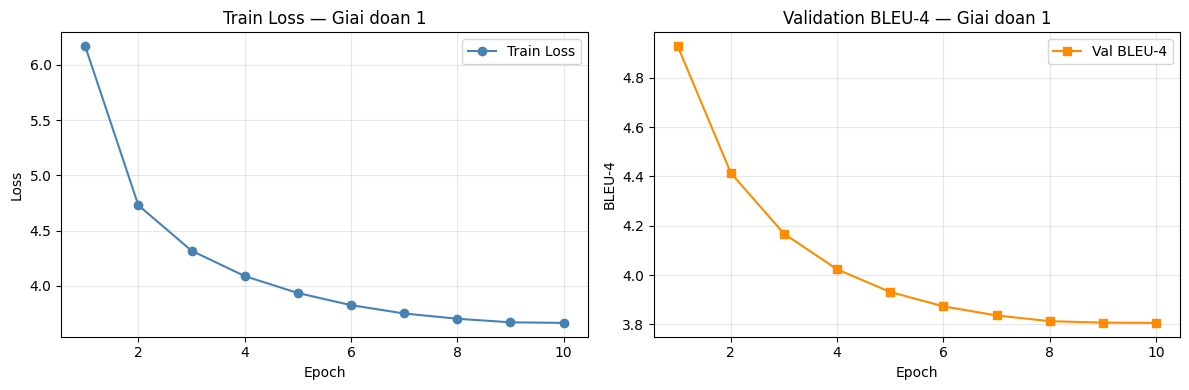

  Bieu do luu tai: /content/logs/phase1_curves.png


In [ ]:
CKPT_A1_PHASE1 = os.path.join(CHECKPOINT_DIR, "vqa_a1_phase1_best.pt")

print("=" * 60)
print("BAT DAU GIAI DOAN 1 — A1 (LSTM) — FREEZE ENCODER")
print("=" * 60)

# Dong bang encoder, chi train Fusion + Decoder
actual_vqa_a1 = vqa_a1.module if isinstance(vqa_a1, torch.nn.DataParallel) else vqa_a1
actual_vqa_a1.freeze_encoders()

total_steps_a1_p1 = (len(train_loader) // GRAD_ACCUMULATION) * EPOCHS_PHASE1
optimizer_a1_p1, scheduler_a1_p1 = build_optimizer_phase1(vqa_a1, total_steps_a1_p1)
scaler_a1_p1 = torch.amp.GradScaler("cuda")

# Resume tu HuggingFace hoac Local
start_epoch_a1, train_losses_a1_p1, val_losses_a1_p1, best_val_loss_a1, patience_count_a1 = \
    load_checkpoint_if_exists("vqa_a1_phase1_best.pt", vqa_a1, optimizer_a1_p1, scheduler_a1_p1)

# best_val_loss_a1: neu la checkpoint cu dung BLEU thi se load ve 0.0
# -> chuyen sang inf de tieu chi moi (Val Loss) hoat dong dung
if best_val_loss_a1 == 0.0:
    best_val_loss_a1 = float("inf")

phase1_a1_start = time.time()

for epoch in range(start_epoch_a1, EPOCHS_PHASE1 + 1):
    epoch_start = time.time()
    print(f"\nEpoch {epoch}/{EPOCHS_PHASE1} — A1 (LSTM)")
    print("-" * 40)

    # --- Train ---
    train_loss = train_one_epoch(
        model=vqa_a1, loader=train_loader, optimizer=optimizer_a1_p1,
        scheduler=scheduler_a1_p1, criterion=criterion, scaler=scaler_a1_p1,
        epoch=epoch, device=DEVICE,
    )
    train_losses_a1_p1.append(train_loss)

    # --- Validate (tinh ca Val Loss lan BLEU/ROUGE) ---
    print(f"\nDanh gia validation epoch {epoch} — A1...")
    val_metrics = evaluate(
        vqa_a1, val_loader, answer_vocab,
        criterion=criterion, beam_size=1, device=DEVICE,
    )
    val_losses_a1_p1.append(val_metrics["val_loss"])

    epoch_time = time.time() - epoch_start
    eta_total  = epoch_time * (EPOCHS_PHASE1 - epoch)
    print(
        f"\nEpoch {epoch} | Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['val_loss']:.4f} | "
        f"BLEU-4: {val_metrics['bleu4']:.4f} | "
        f"Thoi gian: {_fmt_time(epoch_time)} | ETA: {_fmt_time(eta_total)}"
    )

    # --- Chon checkpoint tot nhat dua tren VAL LOSS (thap hon = tot hon) ---
    if val_metrics["val_loss"] < best_val_loss_a1:
        best_val_loss_a1  = val_metrics["val_loss"]
        patience_count_a1 = 0
        save_checkpoint(
            model=vqa_a1, optimizer=optimizer_a1_p1, scheduler=scheduler_a1_p1,
            epoch=epoch, metrics=val_metrics, train_losses=train_losses_a1_p1,
            val_bleus=val_losses_a1_p1, patience_count=patience_count_a1,
            path=CKPT_A1_PHASE1,
        )
        print(f"  Val Loss tot nhat A1 cap nhat: {best_val_loss_a1:.4f} (BLEU={val_metrics['bleu4']:.4f})")
    else:
        patience_count_a1 += 1
        print(f"  Val Loss khong giam ({patience_count_a1}/{EARLY_STOPPING_PATIENCE})")
        if patience_count_a1 >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly Stopping A1 — dung sau {EARLY_STOPPING_PATIENCE} epoch.")
            break

phase1_a1_total = time.time() - phase1_a1_start
print(f"\nA1 Giai doan 1 hoan thanh | Tong thoi gian: {_fmt_time(phase1_a1_total)}")
print(f"Val Loss tot nhat A1: {best_val_loss_a1:.4f}")
plot_loss_curves(train_losses_a1_p1, val_losses_a1_p1, phase=1)



#### 10.5b — Vòng lặp – Giai đoạn 1 cho A2 (Tranformer)

In [ ]:
actual_a2 = vqa_a2.module if isinstance(vqa_a2, torch.nn.DataParallel) else vqa_a2

# Khoi tao lai embedding voi std nho (chuan Transformer)
# std=0.02 la gia tri duoc dung trong BERT, GPT-2, va cac mo hinh SOTA
actual_a2.decoder.embedding.weight.data.normal_(mean=0.0, std=0.02)

# Kiem tra lai
with torch.no_grad():
    logits = vqa_a2(dummy_img, dummy_q, dummy_mask, dummy_ans)
    print(f"Logits std sau fix : {logits.std():.4f}  (muc tieu: < 5)")
    loss = criterion(logits, dummy_ans[:, 1:])
    print(f"Loss sau fix       : {loss.item():.4f}  (muc tieu: ~8-10)")



Logits std sau fix : 0.3178  (muc tieu: < 5)
Loss sau fix       : 8.6674  (muc tieu: ~8-10)


BAT DAU GIAI DOAN 1 — A2 (Transformer) — FREEZE ENCODER
Tim 'vqa_a2_phase1_best.pt' tren Hugging Face Hub...
  -> Khong co tren HF hoac loi mang.
  -> Chua co checkpoint. Bat dau tu Epoch 1.

Epoch 1/10 — A2 (Transformer)
----------------------------------------
  Epoch 1 | Batch   100/1141 | Loss: 8.4028 | LR: 3.33e-05 | ETA epoch: 03:40
  Epoch 1 | Batch   200/1141 | Loss: 7.6992 | LR: 6.67e-05 | ETA epoch: 03:19
  Epoch 1 | Batch   300/1141 | Loss: 7.2664 | LR: 1.00e-04 | ETA epoch: 02:57
  Epoch 1 | Batch   400/1141 | Loss: 7.0285 | LR: 1.00e-04 | ETA epoch: 02:33
  Epoch 1 | Batch   500/1141 | Loss: 6.8557 | LR: 9.99e-05 | ETA epoch: 02:13
  Epoch 1 | Batch   600/1141 | Loss: 6.7252 | LR: 9.98e-05 | ETA epoch: 01:51
  Epoch 1 | Batch   700/1141 | Loss: 6.6197 | LR: 9.97e-05 | ETA epoch: 01:30
  Epoch 1 | Batch   800/1141 | Loss: 6.5329 | LR: 9.95e-05 | ETA epoch: 01:10
  Epoch 1 | Batch   900/1141 | Loss: 6.4509 | LR: 9.93e-05 | ETA epoch: 00:49
  Epoch 1 | Batch  1000/1141 | Loss

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nts/vqa_a2_phase1_best.pt:   0%|          |  549kB /  971MB            

  Da day len HuggingFace Hub: azan100an/vqa-herb-checkpoints-Vit_base_colab
  Val Loss tot nhat A2 cap nhat: 5.6727 (BLEU=0.0048)

Epoch 2/10 — A2 (Transformer)
----------------------------------------
  Epoch 2 | Batch   100/1141 | Loss: 5.6130 | LR: 9.82e-05 | ETA epoch: 03:41
  Epoch 2 | Batch   200/1141 | Loss: 5.5805 | LR: 9.78e-05 | ETA epoch: 03:11
  Epoch 2 | Batch   300/1141 | Loss: 5.5707 | LR: 9.74e-05 | ETA epoch: 02:52
  Epoch 2 | Batch   400/1141 | Loss: 5.5615 | LR: 9.69e-05 | ETA epoch: 02:32
  Epoch 2 | Batch   500/1141 | Loss: 5.5396 | LR: 9.64e-05 | ETA epoch: 02:10
  Epoch 2 | Batch   600/1141 | Loss: 5.5266 | LR: 9.59e-05 | ETA epoch: 01:50
  Epoch 2 | Batch   700/1141 | Loss: 5.5057 | LR: 9.53e-05 | ETA epoch: 01:30
  Epoch 2 | Batch   800/1141 | Loss: 5.4920 | LR: 9.47e-05 | ETA epoch: 01:09
  Epoch 2 | Batch   900/1141 | Loss: 5.4782 | LR: 9.40e-05 | ETA epoch: 00:49
  Epoch 2 | Batch  1000/1141 | Loss: 5.4665 | LR: 9.34e-05 | ETA epoch: 00:28
  Epoch 2 | Batch 

...

  Da day len HuggingFace Hub: azan100an/vqa-herb-checkpoints-Vit_base_colab
  Val Loss tot nhat A2 cap nhat: 4.4042 (BLEU=0.0740)

Epoch 10/10 — A2 (Transformer)
----------------------------------------
  Epoch 10 | Batch   100/1141 | Loss: 4.2972 | LR: 2.08e-06 | ETA epoch: 03:30
  Epoch 10 | Batch   200/1141 | Loss: 4.2781 | LR: 1.69e-06 | ETA epoch: 03:13
  Epoch 10 | Batch   300/1141 | Loss: 4.2702 | LR: 1.35e-06 | ETA epoch: 02:52
  Epoch 10 | Batch   400/1141 | Loss: 4.2859 | LR: 1.04e-06 | ETA epoch: 02:31
  Epoch 10 | Batch   500/1141 | Loss: 4.2881 | LR: 7.73e-07 | ETA epoch: 02:11
  Epoch 10 | Batch   600/1141 | Loss: 4.2834 | LR: 5.45e-07 | ETA epoch: 01:50
  Epoch 10 | Batch   700/1141 | Loss: 4.2684 | LR: 3.56e-07 | ETA epoch: 01:30
  Epoch 10 | Batch   800/1141 | Loss: 4.2629 | LR: 2.07e-07 | ETA epoch: 01:09
  Epoch 10 | Batch   900/1141 | Loss: 4.2565 | LR: 9.87e-08 | ETA epoch: 00:49
  Epoch 10 | Batch  1000/1141 | Loss: 4.2562 | LR: 2.98e-08 | ETA epoch: 00:28
  Epoch

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nts/vqa_a2_phase1_best.pt:  11%|#         |  104MB /  971MB            

  Da day len HuggingFace Hub: azan100an/vqa-herb-checkpoints-Vit_base_colab
  Val Loss tot nhat A2 cap nhat: 4.4024 (BLEU=0.0755)

A2 Giai doan 1 hoan thanh | Tong thoi gian: 01:13:01
Val Loss tot nhat A2: 4.4024


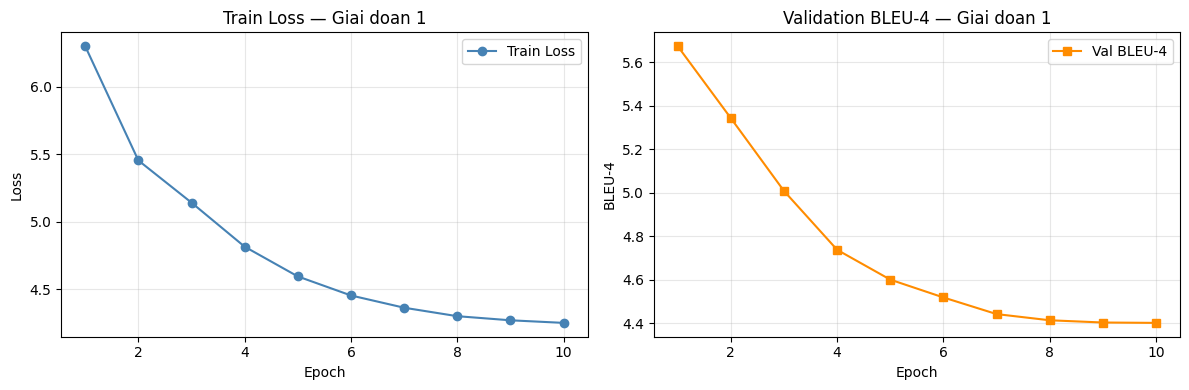

  Bieu do luu tai: /content/logs/phase1_curves.png


In [ ]:
CKPT_A2_PHASE1 = os.path.join(CHECKPOINT_DIR, "vqa_a2_phase1_best.pt")

print("=" * 60)
print("BAT DAU GIAI DOAN 1 — A2 (Transformer) — FREEZE ENCODER")
print("=" * 60)

# Dong bang encoder, chi train Fusion + Decoder
actual_vqa_a2 = vqa_a2.module if isinstance(vqa_a2, torch.nn.DataParallel) else vqa_a2
actual_vqa_a2.freeze_encoders()

total_steps_a2_p1 = (len(train_loader) // GRAD_ACCUMULATION) * EPOCHS_PHASE1
optimizer_a2_p1, scheduler_a2_p1 = build_optimizer_phase1(vqa_a2, total_steps_a2_p1)
scaler_a2_p1 = torch.amp.GradScaler("cuda")

# Resume tu HuggingFace hoac Local
start_epoch_a2, train_losses_a2_p1, val_losses_a2_p1, best_val_loss_a2, patience_count_a2 = \
    load_checkpoint_if_exists("vqa_a2_phase1_best.pt", vqa_a2, optimizer_a2_p1, scheduler_a2_p1)

# Tuong thich voi checkpoint cu dung BLEU (tra ve 0.0) -> chuyen sang inf
if best_val_loss_a2 == 0.0:
    best_val_loss_a2 = float("inf")

phase1_a2_start = time.time()

for epoch in range(start_epoch_a2, EPOCHS_PHASE1 + 1):
    epoch_start = time.time()
    print(f"\nEpoch {epoch}/{EPOCHS_PHASE1} — A2 (Transformer)")
    print("-" * 40)

    # --- Train ---
    train_loss = train_one_epoch(
        model=vqa_a2, loader=train_loader, optimizer=optimizer_a2_p1,
        scheduler=scheduler_a2_p1, criterion=criterion, scaler=scaler_a2_p1,
        epoch=epoch, device=DEVICE,
    )
    train_losses_a2_p1.append(train_loss)

    # --- Validate (tinh ca Val Loss lan BLEU/ROUGE) ---
    print(f"\nDanh gia validation epoch {epoch} — A2...")
    val_metrics = evaluate(
        vqa_a2, val_loader, answer_vocab,
        criterion=criterion, beam_size=1, device=DEVICE,
    )
    val_losses_a2_p1.append(val_metrics["val_loss"])

    epoch_time = time.time() - epoch_start
    eta_total  = epoch_time * (EPOCHS_PHASE1 - epoch)
    print(
        f"\nEpoch {epoch} | Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['val_loss']:.4f} | "
        f"BLEU-4: {val_metrics['bleu4']:.4f} | "
        f"Thoi gian: {_fmt_time(epoch_time)} | ETA: {_fmt_time(eta_total)}"
    )

    # --- Chon checkpoint tot nhat dua tren VAL LOSS (thap hon = tot hon) ---
    if val_metrics["val_loss"] < best_val_loss_a2:
        best_val_loss_a2  = val_metrics["val_loss"]
        patience_count_a2 = 0
        save_checkpoint(
            model=vqa_a2, optimizer=optimizer_a2_p1, scheduler=scheduler_a2_p1,
            epoch=epoch, metrics=val_metrics, train_losses=train_losses_a2_p1,
            val_bleus=val_losses_a2_p1, patience_count=patience_count_a2,
            path=CKPT_A2_PHASE1,
        )
        print(f"  Val Loss tot nhat A2 cap nhat: {best_val_loss_a2:.4f} (BLEU={val_metrics['bleu4']:.4f})")
    else:
        patience_count_a2 += 1
        print(f"  Val Loss khong giam ({patience_count_a2}/{EARLY_STOPPING_PATIENCE})")
        if patience_count_a2 >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly Stopping A2 — dung sau {EARLY_STOPPING_PATIENCE} epoch.")
            break

phase1_a2_total = time.time() - phase1_a2_start
print(f"\nA2 Giai doan 1 hoan thanh | Tong thoi gian: {_fmt_time(phase1_a2_total)}")
print(f"Val Loss tot nhat A2: {best_val_loss_a2:.4f}")
plot_loss_curves(train_losses_a2_p1, val_losses_a2_p1, phase=1)



### 10.6. Vòng lặp huấn luyện – Giai đoạn 2 (Unfreeze một phần Encoder)

- Load checkpoint tốt nhất từ Giai đoạn 1.
- Mở khoá 2 block cuối của DINOv2 và 2 lớp cuối của PhoBERT.
- Chuyển sang Optimizer mới với learning rate rất nhỏ (khoảng 1e-5).
- Tiếp tục huấn luyện thêm 5 đến 10 epoch, tiếp tục theo dõi validation và lưu checkpoint.
- Giai đoạn này giúp tinh chỉnh toàn bộ hệ thống, cải thiện kết quả so với Giai đoạn 1.

#### 10.6a — Vòng lặp – Giai đoạn 2 cho A1 (LSTM)

BAT DAU GIAI DOAN 2 — A1 (LSTM) — UNFREEZE MOT PHAN ENCODER
Đã mở khóa 2 block cuối — 14,180,352 tham số có thể huấn luyện.
Đã mở khóa 2 lớp cuối PhoBERT — 14,766,336 tham số có thể huấn luyện.

So tham so A1 sau khi unfreeze:
  ImageEncoder        :   14,180,352 / 86,580,480
  TextEncoder         :   14,766,336 / 134,998,272
  Fusion              :    1,052,416 / 1,052,416
  Decoder             :   10,256,896 / 10,256,896
  TOTAL               :   40,256,000 / 232,888,064
Tim 'vqa_a1_phase2_best.pt' tren Hugging Face Hub...
  -> Khong co tren HF hoac loi mang.
  -> Chua co checkpoint. Bat dau tu Epoch 1.
Nap checkpoint A1 Giai doan 1 tu: /content/checkpoints/vqa_a1_phase1_best.pt

Val Loss khoi diem A1 Phase 2: 3.8064
------------------------------------------------------------

Epoch 1/10 — A1 Giai doan 2
----------------------------------------
  Epoch 1 | Batch   100/1141 | Loss: 3.5970 | LR: 3.33e-06 | ETA epoch: 11:21
  Epoch 1 | Batch   200/1141 | Loss: 3.6398 | LR: 5.00e-06 | E

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nts/vqa_a1_phase2_best.pt:   5%|5         | 62.6MB / 1.25GB            

  Da day len HuggingFace Hub: azan100an/vqa-herb-checkpoints-Vit_base_colab
  Val Loss tot nhat A1 cap nhat: 3.7675

Epoch 2/10 — A1 Giai doan 2
----------------------------------------
  Epoch 2 | Batch   100/1141 | Loss: 3.5894 | LR: 4.88e-06 | ETA epoch: 09:12
  Epoch 2 | Batch   200/1141 | Loss: 3.5931 | LR: 4.86e-06 | ETA epoch: 08:08
  Epoch 2 | Batch   300/1141 | Loss: 3.6047 | LR: 4.84e-06 | ETA epoch: 07:11
  Epoch 2 | Batch   400/1141 | Loss: 3.6165 | LR: 4.81e-06 | ETA epoch: 06:20
  Epoch 2 | Batch   500/1141 | Loss: 3.6260 | LR: 4.79e-06 | ETA epoch: 05:29
  Epoch 2 | Batch   600/1141 | Loss: 3.6288 | LR: 4.76e-06 | ETA epoch: 04:36
  Epoch 2 | Batch   700/1141 | Loss: 3.6226 | LR: 4.73e-06 | ETA epoch: 03:44
  Epoch 2 | Batch   800/1141 | Loss: 3.6213 | LR: 4.69e-06 | ETA epoch: 02:53
  Epoch 2 | Batch   900/1141 | Loss: 3.6165 | LR: 4.66e-06 | ETA epoch: 02:02
  Epoch 2 | Batch  1000/1141 | Loss: 3.6129 | LR: 4.62e-06 | ETA epoch: 01:11
  Epoch 2 | Batch  1100/1141 | Los

...

  Da day len HuggingFace Hub: azan100an/vqa-herb-checkpoints-Vit_base_colab
  Val Loss tot nhat A1 cap nhat: 3.6022

Epoch 10/10 — A1 Giai doan 2
----------------------------------------
  Epoch 10 | Batch   100/1141 | Loss: 3.3605 | LR: 1.01e-07 | ETA epoch: 08:16
  Epoch 10 | Batch   200/1141 | Loss: 3.3345 | LR: 8.24e-08 | ETA epoch: 07:24
  Epoch 10 | Batch   300/1141 | Loss: 3.3102 | LR: 6.56e-08 | ETA epoch: 06:33
  Epoch 10 | Batch   400/1141 | Loss: 3.2964 | LR: 5.06e-08 | ETA epoch: 05:46
  Epoch 10 | Batch   500/1141 | Loss: 3.3133 | LR: 3.76e-08 | ETA epoch: 04:59
  Epoch 10 | Batch   600/1141 | Loss: 3.3126 | LR: 2.65e-08 | ETA epoch: 04:12
  Epoch 10 | Batch   700/1141 | Loss: 3.3025 | LR: 1.73e-08 | ETA epoch: 03:26
  Epoch 10 | Batch   800/1141 | Loss: 3.3055 | LR: 1.01e-08 | ETA epoch: 02:39
  Epoch 10 | Batch   900/1141 | Loss: 3.3066 | LR: 4.80e-09 | ETA epoch: 01:52
  Epoch 10 | Batch  1000/1141 | Loss: 3.3061 | LR: 1.45e-09 | ETA epoch: 01:05
  Epoch 10 | Batch  110

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nts/vqa_a1_phase2_best.pt:   4%|3         | 47.8MB / 1.25GB            

  Da day len HuggingFace Hub: azan100an/vqa-herb-checkpoints-Vit_base_colab
  Val Loss tot nhat A1 cap nhat: 3.6018

A1 Giai doan 2 hoan thanh | Tong thoi gian: 02:03:13


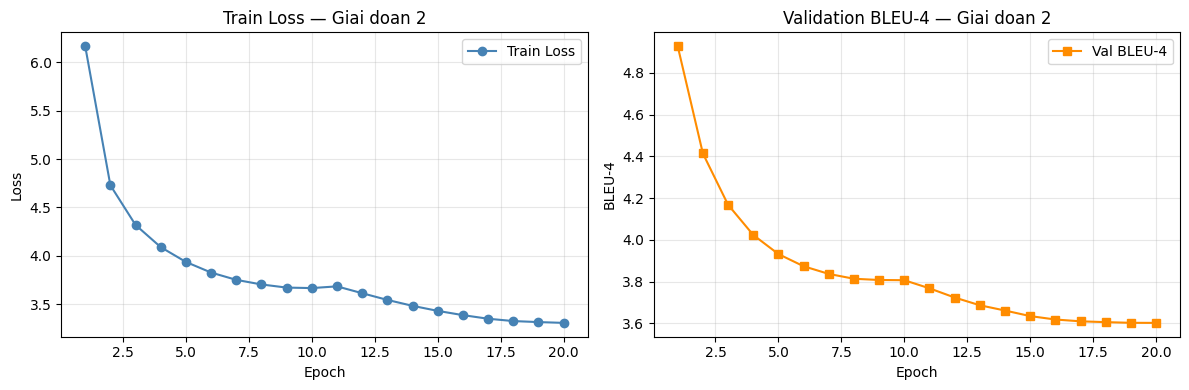

  Bieu do luu tai: /content/logs/phase2_curves.png


In [ ]:
CKPT_A1_PHASE1 = os.path.join(CHECKPOINT_DIR, "vqa_a1_phase1_best.pt")
CKPT_A1_PHASE2 = os.path.join(CHECKPOINT_DIR, "vqa_a1_phase2_best.pt")

print("=" * 60)
print("BAT DAU GIAI DOAN 2 — A1 (LSTM) — UNFREEZE MOT PHAN ENCODER")
print("=" * 60)

actual_vqa_a1 = vqa_a1.module if isinstance(vqa_a1, torch.nn.DataParallel) else vqa_a1
actual_vqa_a1.unfreeze_encoders_partial(n_img_blocks=2, n_txt_layers=2)

stats_a1 = actual_vqa_a1.count_params()
print(f"\nSo tham so A1 sau khi unfreeze:")
for part, val in stats_a1.items():
    if val["trainable"] > 0: print(f"  {part:<20}: {val['trainable']:>12,} / {val['total']:,}")

total_steps_a1_p2 = (len(train_loader) // GRAD_ACCUMULATION) * EPOCHS_PHASE2
optimizer_a1_p2, scheduler_a1_p2 = build_optimizer_phase2(vqa_a1, total_steps_a1_p2)
scaler_a1_p2 = torch.amp.GradScaler("cuda")

# Thu resume Phase 2, neu chua co thi nap tu Phase 1
start_epoch_a1_p2, train_losses_a1_p2, val_losses_a1_p2, best_val_loss_a1_p2, patience_count_a1 = \
    load_checkpoint_if_exists("vqa_a1_phase2_best.pt", vqa_a1, optimizer_a1_p2, scheduler_a1_p2)

if start_epoch_a1_p2 == 1:
    if not os.path.exists(CKPT_A1_PHASE1):
        raise FileNotFoundError(f"Khong tim thay checkpoint A1 Phase 1: {CKPT_A1_PHASE1}")
    print(f"Nap checkpoint A1 Giai doan 1 tu: {CKPT_A1_PHASE1}")
    ckpt_a1 = torch.load(CKPT_A1_PHASE1, map_location=DEVICE)
    from collections import OrderedDict
    new_sd = OrderedDict(
        (k[7:] if k.startswith("module.") else k, v)
        for k, v in ckpt_a1["model"].items()
    )
    vqa_a1.load_state_dict(new_sd)
    # Lay Val Loss tu checkpoint Phase 1 lam diem khoi diem
    best_val_loss_a1_p2 = ckpt_a1["metrics"].get("val_loss") or float("inf")

print(f"\nVal Loss khoi diem A1 Phase 2: {best_val_loss_a1_p2:.4f}")
print("-" * 60)

phase2_a1_start = time.time()
for epoch in range(start_epoch_a1_p2, EPOCHS_PHASE2 + 1):
    epoch_start = time.time()
    print(f"\nEpoch {epoch}/{EPOCHS_PHASE2} — A1 Giai doan 2")
    print("-" * 40)

    train_loss = train_one_epoch(
        model=vqa_a1, loader=train_loader, optimizer=optimizer_a1_p2,
        scheduler=scheduler_a1_p2, criterion=criterion, scaler=scaler_a1_p2,
        epoch=epoch, device=DEVICE,
    )
    train_losses_a1_p2.append(train_loss)

    print(f"\nDanh gia validation epoch {epoch} — A1...")
    val_metrics = evaluate(
        vqa_a1, val_loader, answer_vocab,
        criterion=criterion, beam_size=1, device=DEVICE,
    )
    val_losses_a1_p2.append(val_metrics["val_loss"])

    epoch_time = time.time() - epoch_start
    print(
        f"\nEpoch {epoch} | Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['val_loss']:.4f} | "
        f"BLEU-4: {val_metrics['bleu4']:.4f} | Thoi gian: {_fmt_time(epoch_time)}"
    )

    if val_metrics["val_loss"] < best_val_loss_a1_p2:
        best_val_loss_a1_p2 = val_metrics["val_loss"]
        patience_count_a1 = 0
        save_checkpoint(
            model=vqa_a1, optimizer=optimizer_a1_p2, scheduler=scheduler_a1_p2,
            epoch=epoch, metrics=val_metrics, train_losses=train_losses_a1_p2,
            val_bleus=val_losses_a1_p2, patience_count=patience_count_a1, path=CKPT_A1_PHASE2,
        )
        print(f"  Val Loss tot nhat A1 cap nhat: {best_val_loss_a1_p2:.4f}")
    else:
        patience_count_a1 += 1
        print(f"  Val Loss khong giam ({patience_count_a1}/{EARLY_STOPPING_PATIENCE})")
        if patience_count_a1 >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly Stopping A1 — dung sau {EARLY_STOPPING_PATIENCE} epoch.")
            break

phase2_a1_total = time.time() - phase2_a1_start
print(f"\nA1 Giai doan 2 hoan thanh | Tong thoi gian: {_fmt_time(phase2_a1_total)}")

all_losses_a1 = train_losses_a1_p1 + train_losses_a1_p2 if 'train_losses_a1_p1' in locals() else train_losses_a1_p2
all_vals_a1   = val_losses_a1_p1   + val_losses_a1_p2   if 'val_losses_a1_p1'   in locals() else val_losses_a1_p2
plot_loss_curves(all_losses_a1, all_vals_a1, phase=2)



#### 10.6b — Vòng lặp – Giai đoạn 2 cho A2 (Tranformer)

BAT DAU GIAI DOAN 2 — A2 (Transformer) — UNFREEZE MOT PHAN ENCODER
Đã mở khóa 2 block cuối — 14,180,352 tham số có thể huấn luyện.
Đã mở khóa 2 lớp cuối PhoBERT — 14,766,336 tham số có thể huấn luyện.

So tham so A2 sau khi unfreeze:
  ImageEncoder        :   14,180,352 / 86,580,480
  TextEncoder         :   14,766,336 / 134,998,272
  Fusion              :    1,052,416 / 1,052,416
  Decoder             :    6,127,616 / 6,127,616
  TOTAL               :   36,126,720 / 228,758,784
Tim 'vqa_a2_phase2_best.pt' tren Hugging Face Hub...
  -> Khong co tren HF hoac loi mang.
  -> Chua co checkpoint. Bat dau tu Epoch 1.
Nap checkpoint A2 Giai doan 1 tu: /content/checkpoints/vqa_a2_phase1_best.pt

Val Loss khoi diem A2 Phase 2: 4.4024
------------------------------------------------------------

Epoch 1/10 — A2 Giai doan 2
----------------------------------------
  Epoch 1 | Batch   100/1141 | Loss: 4.2911 | LR: 3.33e-06 | ETA epoch: 03:49
  Epoch 1 | Batch   200/1141 | Loss: 4.2611 | LR: 5.00e-

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nts/vqa_a2_phase2_best.pt:   8%|7         | 94.1MB / 1.20GB            

  Da day len HuggingFace Hub: azan100an/vqa-herb-checkpoints-Vit_base_colab
  Val Loss tot nhat A2 cap nhat: 4.3579

Epoch 2/10 — A2 Giai doan 2
----------------------------------------
  Epoch 2 | Batch   100/1141 | Loss: 4.2072 | LR: 4.88e-06 | ETA epoch: 03:52
  Epoch 2 | Batch   200/1141 | Loss: 4.2072 | LR: 4.86e-06 | ETA epoch: 03:21
  Epoch 2 | Batch   300/1141 | Loss: 4.2084 | LR: 4.84e-06 | ETA epoch: 03:00
  Epoch 2 | Batch   400/1141 | Loss: 4.2078 | LR: 4.81e-06 | ETA epoch: 02:39
  Epoch 2 | Batch   500/1141 | Loss: 4.2124 | LR: 4.79e-06 | ETA epoch: 02:16
  Epoch 2 | Batch   600/1141 | Loss: 4.2167 | LR: 4.76e-06 | ETA epoch: 01:55
  Epoch 2 | Batch   700/1141 | Loss: 4.2063 | LR: 4.73e-06 | ETA epoch: 01:34
  Epoch 2 | Batch   800/1141 | Loss: 4.2063 | LR: 4.69e-06 | ETA epoch: 01:12
  Epoch 2 | Batch   900/1141 | Loss: 4.2050 | LR: 4.66e-06 | ETA epoch: 00:51
  Epoch 2 | Batch  1000/1141 | Loss: 4.2059 | LR: 4.62e-06 | ETA epoch: 00:30
  Epoch 2 | Batch  1100/1141 | Los

...

  Da day len HuggingFace Hub: azan100an/vqa-herb-checkpoints-Vit_base_colab
  Val Loss tot nhat A2 cap nhat: 4.0999

Epoch 10/10 — A2 Giai doan 2
----------------------------------------
  Epoch 10 | Batch   100/1141 | Loss: 3.8422 | LR: 1.01e-07 | ETA epoch: 03:51
  Epoch 10 | Batch   200/1141 | Loss: 3.8201 | LR: 8.24e-08 | ETA epoch: 03:21
  Epoch 10 | Batch   300/1141 | Loss: 3.8499 | LR: 6.56e-08 | ETA epoch: 03:01
  Epoch 10 | Batch   400/1141 | Loss: 3.8530 | LR: 5.06e-08 | ETA epoch: 02:39
  Epoch 10 | Batch   500/1141 | Loss: 3.8524 | LR: 3.76e-08 | ETA epoch: 02:16
  Epoch 10 | Batch   600/1141 | Loss: 3.8560 | LR: 2.65e-08 | ETA epoch: 01:55
  Epoch 10 | Batch   700/1141 | Loss: 3.8549 | LR: 1.73e-08 | ETA epoch: 01:34
  Epoch 10 | Batch   800/1141 | Loss: 3.8591 | LR: 1.01e-08 | ETA epoch: 01:12
  Epoch 10 | Batch   900/1141 | Loss: 3.8593 | LR: 4.80e-09 | ETA epoch: 00:51
  Epoch 10 | Batch  1000/1141 | Loss: 3.8563 | LR: 1.45e-09 | ETA epoch: 00:30
  Epoch 10 | Batch  110

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nts/vqa_a2_phase2_best.pt:   8%|7         | 95.8MB / 1.20GB            

  Da day len HuggingFace Hub: azan100an/vqa-herb-checkpoints-Vit_base_colab
  Val Loss tot nhat A2 cap nhat: 4.0993

A2 Giai doan 2 hoan thanh | Tong thoi gian: 01:18:22


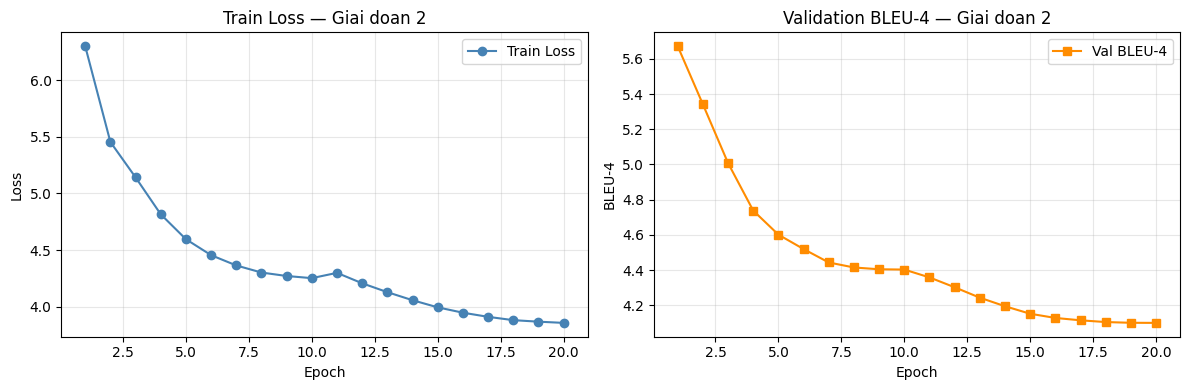

  Bieu do luu tai: /content/logs/phase2_curves.png


In [ ]:
CKPT_A2_PHASE1 = os.path.join(CHECKPOINT_DIR, "vqa_a2_phase1_best.pt")
CKPT_A2_PHASE2 = os.path.join(CHECKPOINT_DIR, "vqa_a2_phase2_best.pt")

print("=" * 60)
print("BAT DAU GIAI DOAN 2 — A2 (Transformer) — UNFREEZE MOT PHAN ENCODER")
print("=" * 60)

actual_vqa_a2 = vqa_a2.module if isinstance(vqa_a2, torch.nn.DataParallel) else vqa_a2
actual_vqa_a2.unfreeze_encoders_partial(n_img_blocks=2, n_txt_layers=2)

stats_a2 = actual_vqa_a2.count_params()
print(f"\nSo tham so A2 sau khi unfreeze:")
for part, val in stats_a2.items():
    if val["trainable"] > 0: print(f"  {part:<20}: {val['trainable']:>12,} / {val['total']:,}")

total_steps_a2_p2 = (len(train_loader) // GRAD_ACCUMULATION) * EPOCHS_PHASE2
optimizer_a2_p2, scheduler_a2_p2 = build_optimizer_phase2(vqa_a2, total_steps_a2_p2)
scaler_a2_p2 = torch.amp.GradScaler("cuda")

# Thu resume Phase 2, neu chua co thi nap tu Phase 1
start_epoch_a2_p2, train_losses_a2_p2, val_losses_a2_p2, best_val_loss_a2_p2, patience_count_a2 = \
    load_checkpoint_if_exists("vqa_a2_phase2_best.pt", vqa_a2, optimizer_a2_p2, scheduler_a2_p2)

if start_epoch_a2_p2 == 1:
    if not os.path.exists(CKPT_A2_PHASE1):
        raise FileNotFoundError(f"Khong tim thay checkpoint A2 Phase 1: {CKPT_A2_PHASE1}")
    print(f"Nap checkpoint A2 Giai doan 1 tu: {CKPT_A2_PHASE1}")
    ckpt_a2 = torch.load(CKPT_A2_PHASE1, map_location=DEVICE)
    from collections import OrderedDict
    new_sd = OrderedDict(
        (k[7:] if k.startswith("module.") else k, v)
        for k, v in ckpt_a2["model"].items()
    )
    vqa_a2.load_state_dict(new_sd)  # ← SỬA BUG: đúng là vqa_a2
    best_val_loss_a2_p2 = ckpt_a2["metrics"].get("val_loss") or float("inf")

print(f"\nVal Loss khoi diem A2 Phase 2: {best_val_loss_a2_p2:.4f}")
print("-" * 60)

phase2_a2_start = time.time()
for epoch in range(start_epoch_a2_p2, EPOCHS_PHASE2 + 1):
    epoch_start = time.time()
    print(f"\nEpoch {epoch}/{EPOCHS_PHASE2} — A2 Giai doan 2")
    print("-" * 40)

    train_loss = train_one_epoch(
        model=vqa_a2, loader=train_loader, optimizer=optimizer_a2_p2,
        scheduler=scheduler_a2_p2, criterion=criterion, scaler=scaler_a2_p2,
        epoch=epoch, device=DEVICE,
    )
    train_losses_a2_p2.append(train_loss)

    print(f"\nDanh gia validation epoch {epoch} — A2...")
    val_metrics = evaluate(
        vqa_a2, val_loader, answer_vocab,
        criterion=criterion, beam_size=1, device=DEVICE,
    )
    val_losses_a2_p2.append(val_metrics["val_loss"])

    epoch_time = time.time() - epoch_start
    print(
        f"\nEpoch {epoch} | Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['val_loss']:.4f} | "
        f"BLEU-4: {val_metrics['bleu4']:.4f} | Thoi gian: {_fmt_time(epoch_time)}"
    )

    if val_metrics["val_loss"] < best_val_loss_a2_p2:
        best_val_loss_a2_p2 = val_metrics["val_loss"]
        patience_count_a2 = 0
        save_checkpoint(
            model=vqa_a2, optimizer=optimizer_a2_p2, scheduler=scheduler_a2_p2,
            epoch=epoch, metrics=val_metrics, train_losses=train_losses_a2_p2,
            val_bleus=val_losses_a2_p2, patience_count=patience_count_a2, path=CKPT_A2_PHASE2,
        )
        print(f"  Val Loss tot nhat A2 cap nhat: {best_val_loss_a2_p2:.4f}")
    else:
        patience_count_a2 += 1
        print(f"  Val Loss khong giam ({patience_count_a2}/{EARLY_STOPPING_PATIENCE})")
        if patience_count_a2 >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly Stopping A2 — dung sau {EARLY_STOPPING_PATIENCE} epoch.")
            break

phase2_a2_total = time.time() - phase2_a2_start
print(f"\nA2 Giai doan 2 hoan thanh | Tong thoi gian: {_fmt_time(phase2_a2_total)}")

all_losses_a2 = train_losses_a2_p1 + train_losses_a2_p2 if 'train_losses_a2_p1' in locals() else train_losses_a2_p2
all_vals_a2   = val_losses_a2_p1   + val_losses_a2_p2   if 'val_losses_a2_p1'   in locals() else val_losses_a2_p2
plot_loss_curves(all_losses_a2, all_vals_a2, phase=2)



---
## 11.Đánh giá và so sánh A1 vs A2

Đây là trọng tâm của báo cáo: so sánh chính xác hai cấu hình decoder trên cùng tập test, cùng encoder và fusion đã được huấn luyện.

### 11.1. Load checkpoint của A1 và A2

Load checkpoint tốt nhất của cả hai cấu hình từ đĩa. Đảm bảo rằng phần Image Encoder, Text Encoder và Fusion Module của cả hai checkpoint là giống nhau (cùng được huấn luyện từ cùng bộ dữ liệu và cùng chiến lược), chỉ khác phần Decoder.

In [25]:
import os
import torch
from huggingface_hub import hf_hub_download

# Khai báo đường dẫn checkpoint (cả Phase 1 và Phase 2)
CKPT_A1_PHASE1 = os.path.join(CHECKPOINT_DIR, "vqa_a1_phase1_best.pt")
CKPT_A1_PHASE2 = os.path.join(CHECKPOINT_DIR, "vqa_a1_phase2_best.pt")
CKPT_A2_PHASE1 = os.path.join(CHECKPOINT_DIR, "vqa_a2_phase1_best.pt")
CKPT_A2_PHASE2 = os.path.join(CHECKPOINT_DIR, "vqa_a2_phase2_best.pt")

print("=" * 60)
print("11.1. NẠP CHECKPOINT TỐT NHẤT CHO A1 (LSTM) VÀ A2 (TRANSFORMER)")
print("=" * 60)

def _try_load(model, ckpt_path):
    ckpt_filename = os.path.basename(ckpt_path)

    if not os.path.exists(ckpt_path):
        if HF_HUB_TOKEN and HF_HUB_REPO_ID:
            try:
                ckpt_path = hf_hub_download(
                    repo_id=HF_HUB_REPO_ID,
                    filename=ckpt_filename,
                    token=HF_HUB_TOKEN,
                    local_dir=CHECKPOINT_DIR
                )
            except Exception:
                return False, "Không tìm thấy trên Hugging Face"
        else:
            return False, "Không có local & chưa cấu hình HF"

    # Tiến hành nạp trọng số
    try:
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        state_dict = ckpt["model"]

        try:
            model.load_state_dict(state_dict)
        except RuntimeError:
            new_state_dict = {
                (k[7:] if k.startswith("module.") else k): v
                for k, v in state_dict.items()
            }
            actual_model = model.module if isinstance(model, torch.nn.DataParallel) else model
            actual_model.load_state_dict(new_state_dict)

        best_bleu = ckpt.get("metrics", {}).get("bleu4", 0.0)
        epoch = ckpt.get("epoch", "?")

        actual_model = model.module if isinstance(model, torch.nn.DataParallel) else model
        actual_model.eval()

        return True, f"Epoch {epoch} | Val BLEU-4: {best_bleu:.4f}"
    except Exception as e:
        return False, f"Lỗi đọc file: {e}"

def load_eval_model(model, phase2_path, phase1_path, model_name):
    print(f"\nĐang tìm checkpoint cho {model_name}...")

    # 1. Thử nạp Phase 2 trước (ưu tiên cao nhất)
    success, msg = _try_load(model, phase2_path)
    if success:
        print(f"  -> NẠP THÀNH CÔNG PHASE 2! ({msg})")
        return True

    print(f"  -> Phase 2 không tồn tại. Phase 2 có thể không vượt qua được kỷ lục của Phase 1.")
    print(f"  -> Kích hoạt dự phòng: Tự động kéo checkpoint Phase 1...")

    # 2. Nếu không có Phase 2, nạp Phase 1
    success, msg = _try_load(model, phase1_path)
    if success:
        print(f"  -> NẠP THÀNH CÔNG PHASE 1! ({msg})")
        return True

    print(f"  -> THẤT BẠI: Không tìm thấy cả Phase 1 và Phase 2. Bỏ qua mô hình này.")
    return False

# Nạp cho A1 (LSTM)
has_a1 = load_eval_model(vqa_a1, CKPT_A1_PHASE2, CKPT_A1_PHASE1, "A1 (LSTM)")

print("-" * 40)

# Nạp cho A2 (Transformer)
has_a2 = load_eval_model(vqa_a2, CKPT_A2_PHASE2, CKPT_A2_PHASE1, "A2 (Transformer)")

print("\nHoàn tất nạp mô hình chuẩn bị cho phần đánh giá!")


11.1. NẠP CHECKPOINT TỐT NHẤT CHO A1 (LSTM) VÀ A2 (TRANSFORMER)

Đang tìm checkpoint cho A1 (LSTM)...


vqa_a1_phase2_best.pt:   0%|          | 0.00/1.25G [00:00<?, ?B/s]

  -> NẠP THÀNH CÔNG PHASE 2! (Epoch 10 | Val BLEU-4: 0.1918)
----------------------------------------

Đang tìm checkpoint cho A2 (Transformer)...


vqa_a2_phase2_best.pt:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

  -> NẠP THÀNH CÔNG PHASE 2! (Epoch 10 | Val BLEU-4: 0.1144)

Hoàn tất nạp mô hình chuẩn bị cho phần đánh giá!


### 11.2. Tính VQA Accuracy

Chạy cả hai mô hình trên tập test. Tính VQA Accuracy theo hai cách:
- **Exact Match:** Câu trả lời dự đoán khớp hoàn toàn với câu trả lời chuẩn sau khi đã chuẩn hoá (thường hoá, bỏ dấu chấm cuối).
- **Soft Accuracy (chuẩn VQA v2):** Một câu trả lời được tính điểm nếu ít nhất 3 trong số 10 người annotation đồng ý; nếu dữ liệu không có nhiều annotation, dùng Exact Match.

In kết quả VQA Accuracy của A1 và A2.

In [26]:
print("=" * 60)
print("11.2. TINH VQA ACCURACY TREN TAP TEST")
print("=" * 60)

# Bien toan cuc de luu ket qua cho cac muc tiep theo
test_metrics_a1 = None
test_metrics_a2 = None

if has_a1:
    print("\nDang chay suy luan A1 (LSTM) tren tap Test...")
    test_metrics_a1 = evaluate(vqa_a1, test_loader, vocab, beam_size=1, device=DEVICE)

if has_a2:
    print("\nDang chay suy luan A2 (Transformer) tren tap Test...")
    test_metrics_a2 = evaluate(vqa_a2, test_loader, vocab, beam_size=1, device=DEVICE)

print("\n--- KET QUA VQA ACCURACY (EXACT MATCH) ---")
if has_a1:
    print(f"A1 (LSTM)        : {test_metrics_a1['vqa_acc']:.4f}")
if has_a2:
    print(f"A2 (Transformer) : {test_metrics_a2['vqa_acc']:.4f}")


11.2. TINH VQA ACCURACY TREN TAP TEST

Dang chay suy luan A1 (LSTM) tren tap Test...
  Eval   20/133 | 00:13
  Eval   40/133 | 00:26
  Eval   60/133 | 00:39
  Eval   80/133 | 00:52
  Eval  100/133 | 01:05
  Eval  120/133 | 01:18
  Eval  133/133 | 01:26

  Ket qua danh gia (2122 mau | 01:26):
    BLEU-4    : 0.1870
    ROUGE-L   : 0.4345
    VQA Acc   : 0.0108  (23/2122)

Dang chay suy luan A2 (Transformer) tren tap Test...
  Eval   20/133 | 00:23
  Eval   40/133 | 00:44
  Eval   60/133 | 01:06
  Eval   80/133 | 01:26
  Eval  100/133 | 01:46
  Eval  120/133 | 02:06
  Eval  133/133 | 02:20

  Ket qua danh gia (2122 mau | 02:20):
    BLEU-4    : 0.1125
    ROUGE-L   : 0.3932
    VQA Acc   : 0.0061  (13/2122)

--- KET QUA VQA ACCURACY (EXACT MATCH) ---
A1 (LSTM)        : 0.0108
A2 (Transformer) : 0.0061


### 11.3. Tính BLEU, ROUGE-L, METEOR

Sử dụng thư viện `evaluate` của HuggingFace (hoặc `nltk`) để tính các metric:
- BLEU-1, BLEU-2, BLEU-4: đo độ chính xác n-gram.
- ROUGE-L: đo độ dài chung nhất (Longest Common Subsequence).
- METEOR: tính đến đồng nghĩa và trật tự từ.

Tính cho toàn bộ câu trả lời trên tập test, sau đó in bảng tổng hợp kết quả cho A1 và A2.

In [27]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

# Tải tài nguyên ngôn ngữ cần thiết cho thư viện NLTK (để tính METEOR)
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4', quiet=True)

print("=" * 60)
print("11.3. TÍNH TOÀN DIỆN BLEU, ROUGE-L VÀ METEOR")
print("=" * 60)

def compute_comprehensive_metrics(model, loader, vocab, device=DEVICE):
    model.eval()
    actual_model = model.module if isinstance(model, torch.nn.DataParallel) else model

    all_refs_tokens = []
    all_hyps_tokens = []
    all_refs_text = []
    all_hyps_text = []

    rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

    with torch.no_grad():
        # Dùng tqdm để tạo thanh tiến trình hiển thị cho đẹp
        for batch in tqdm(loader, desc="Thu thập dự đoán"):
            pixel_values = batch["image"].to(device, non_blocking=True)
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            answer_ids = batch["answer_ids"]

            batch_size = pixel_values.size(0)
            for i in range(batch_size):
                pred_ids = actual_model.predict(
                    pixel_values[i:i+1], input_ids[i:i+1], attention_mask[i:i+1], beam_size=1
                )
                pred_text = vocab.decode(pred_ids)
                ref_text = vocab.decode(answer_ids[i].tolist())

                pred_norm = normalize_answer(pred_text)
                ref_norm = normalize_answer(ref_text)

                all_hyps_tokens.append(pred_norm.split())
                all_refs_tokens.append([ref_norm.split()])

                all_hyps_text.append(pred_norm)
                all_refs_text.append(ref_norm)

    # 1. Tính BLEU (1, 2, 4)
    smooth = SmoothingFunction().method1
    bleu1 = corpus_bleu(all_refs_tokens, all_hyps_tokens, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
    bleu2 = corpus_bleu(all_refs_tokens, all_hyps_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
    bleu4 = corpus_bleu(all_refs_tokens, all_hyps_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

    # 2. Tính ROUGE-L
    rouge_scores = [rouge.score(ref, hyp)['rougeL'].fmeasure for ref, hyp in zip(all_refs_text, all_hyps_text)]
    rouge_l = sum(rouge_scores) / len(rouge_scores) if rouge_scores else 0.0

    # 3. Tính METEOR
    meteor_scores = [meteor_score(ref_tokens, hyp_tokens) for ref_tokens, hyp_tokens in zip(all_refs_tokens, all_hyps_tokens)]
    meteor = sum(meteor_scores) / len(meteor_scores) if meteor_scores else 0.0

    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-4": bleu4,
        "ROUGE-L": rouge_l,
        "METEOR": meteor
    }

# Thực thi và lưu kết quả
detailed_metrics_a1 = None
detailed_metrics_a2 = None

if has_a1:
    print("\n[A1 - LSTM] Đang tính toán các độ đo...")
    detailed_metrics_a1 = compute_comprehensive_metrics(vqa_a1, test_loader, vocab, DEVICE)

if has_a2:
    print("\n[A2 - Transformer] Đang tính toán các độ đo...")
    detailed_metrics_a2 = compute_comprehensive_metrics(vqa_a2, test_loader, vocab, DEVICE)

# In bảng tổng hợp
print("\n" + "=" * 55)
print("BẢNG TỔNG HỢP METRIC TRÊN TẬP TEST")
print("=" * 55)
print(f"{'Độ đo (Metric)':<16} | {'A1 (LSTM)':<15} | {'A2 (Transformer)':<15}")
print("-" * 55)

metrics_list = ["BLEU-1", "BLEU-2", "BLEU-4", "ROUGE-L", "METEOR"]
for m in metrics_list:
    val_a1 = f"{detailed_metrics_a1[m]:.4f}" if has_a1 else "N/A"
    val_a2 = f"{detailed_metrics_a2[m]:.4f}" if has_a2 else "N/A"
    print(f"{m:<16} | {val_a1:<15} | {val_a2:<15}")
print("=" * 55)


11.3. TÍNH TOÀN DIỆN BLEU, ROUGE-L VÀ METEOR

[A1 - LSTM] Đang tính toán các độ đo...


Thu thập dự đoán:   0%|          | 0/133 [00:00<?, ?it/s]


[A2 - Transformer] Đang tính toán các độ đo...


Thu thập dự đoán:   0%|          | 0/133 [00:00<?, ?it/s]


BẢNG TỔNG HỢP METRIC TRÊN TẬP TEST
Độ đo (Metric)   | A1 (LSTM)       | A2 (Transformer)
-------------------------------------------------------
BLEU-1           | 0.3760          | 0.2723         
BLEU-2           | 0.2900          | 0.1975         
BLEU-4           | 0.1870          | 0.1125         
ROUGE-L          | 0.4345          | 0.3932         
METEOR           | 0.3114          | 0.2795         


### 11.4. Tính BERTScore

Sử dụng thư viện `bert_score` để tính BERTScore (Precision, Recall, F1) trên tập test. BERTScore đánh giá sự tương đồng ngữ nghĩa giữa câu trả lời dự đoán và câu trả lời chuẩn, vượt qua hạn chế của các metric dựa trên n-gram khi câu trả lời dùng từ ngữ khác nhau nhưng mang cùng ý nghĩa.

In [28]:
# Cài đặt thư viện nếu máy chưa có
!pip install bert-score -q

import torch
from bert_score import score as bert_score_fn
from tqdm.auto import tqdm

print("=" * 60)
print("11.4. TINH BERTSCORE TREN TAP TEST")
print("=" * 60)

def compute_bertscore(model, loader, vocab, device=DEVICE):
    model.eval()
    actual_model = model.module if isinstance(model, torch.nn.DataParallel) else model

    all_refs_text = []
    all_hyps_text = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Thu thap du doan"):
            pixel_values = batch["image"].to(device, non_blocking=True)
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            answer_ids = batch["answer_ids"]

            batch_size = pixel_values.size(0)
            for i in range(batch_size):
                pred_ids = actual_model.predict(
                    pixel_values[i:i+1], input_ids[i:i+1], attention_mask[i:i+1], beam_size=1
                )
                pred_text = vocab.decode(pred_ids)
                ref_text = vocab.decode(answer_ids[i].tolist())

                all_hyps_text.append(normalize_answer(pred_text))
                all_refs_text.append(normalize_answer(ref_text))

    # Tính BERTScore
    # Sử dụng lang="vi" để thư viện tự động chọn mô hình đa ngữ (thường là bert-base-multilingual-cased)
    print("Dang tinh toan BERTScore (co the mat vai phut de tai mo hinh danh gia)...")
    P, R, F1 = bert_score_fn(all_hyps_text, all_refs_text, lang="vi", verbose=False)

    return {
        "Precision": P.mean().item(),
        "Recall": R.mean().item(),
        "F1": F1.mean().item()
    }

# Thực thi và lưu kết quả
bert_metrics_a1 = None
bert_metrics_a2 = None

if has_a1:
    print("\n[A1 - LSTM]")
    bert_metrics_a1 = compute_bertscore(vqa_a1, test_loader, vocab, DEVICE)

if has_a2:
    print("\n[A2 - Transformer]")
    bert_metrics_a2 = compute_bertscore(vqa_a2, test_loader, vocab, DEVICE)

# In bảng tổng hợp
print("\n" + "=" * 55)
print("BANG KET QUA BERTSCORE (DANH GIA NGU NGHIA)")
print("=" * 55)
print(f"{'Do do':<16} | {'A1 (LSTM)':<15} | {'A2 (Transformer)':<15}")
print("-" * 55)

for m in ["Precision", "Recall", "F1"]:
    val_a1 = f"{bert_metrics_a1[m]:.4f}" if has_a1 else "N/A"
    val_a2 = f"{bert_metrics_a2[m]:.4f}" if has_a2 else "N/A"
    print(f"{m:<16} | {val_a1:<15} | {val_a2:<15}")
print("=" * 55)


11.4. TINH BERTSCORE TREN TAP TEST

[A1 - LSTM]


Thu thap du doan:   0%|          | 0/133 [00:00<?, ?it/s]

Dang tinh toan BERTScore (co the mat vai phut de tai mo hinh danh gia)...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

Thu thap du doan:   0%|          | 0/133 [00:00<?, ?it/s]

Dang tinh toan BERTScore (co the mat vai phut de tai mo hinh danh gia)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



BANG KET QUA BERTSCORE (DANH GIA NGU NGHIA)
Do do            | A1 (LSTM)       | A2 (Transformer)
-------------------------------------------------------
Precision        | 0.7960          | 0.7746         
Recall           | 0.7908          | 0.7734         
F1               | 0.7929          | 0.7733         


### 11.5. Đánh giá bằng LLM-as-a-judge

Sử dụng một mô hình ngôn ngữ lớn (Gemini 3 flash life) làm giám khảo tự động. Với mỗi cặp (câu hỏi, câu trả lời chuẩn, câu trả lời dự đoán), yêu cầu LLM chấm điểm từ 0 đến 5 và cho biết lý do. Lấy mẫu khoảng 100 đến 200 câu từ tập test. Tính điểm trung bình của A1 và A2 rồi so sánh.

11.5. KẾT QUẢ LLM-AS-A-JUDGE (ĐỌC TỪ FILE CSV)
Đang đọc dữ liệu LLM Judge từ: /content/llm_judge_results.csv
Hoàn tất! Số lượng mẫu hợp lệ: 150/152

KẾT QUẢ LLM-AS-A-JUDGE (Thang điểm 0-5)
Model                        TB      Std
------------------------------------------
A1 (LSTM)                1.8333   1.6965
A2 (Transformer)         1.6467   1.6017

Phân phối điểm A1:
score_a1
0    43
1    34
2    26
3    17
4    12
5    18

Phân phối điểm A2:
score_a2
-1     3
 0    37
 1    43
 2    34
 3     8
 4    10
 5    15


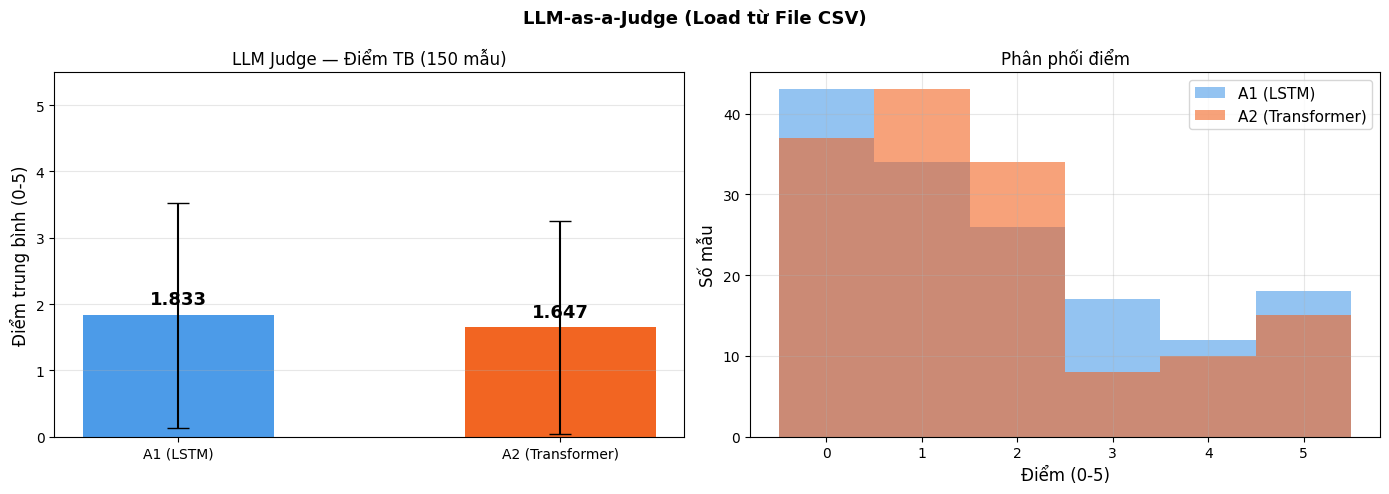

Biểu đồ: /content/logs/llm_judge_comparison.png


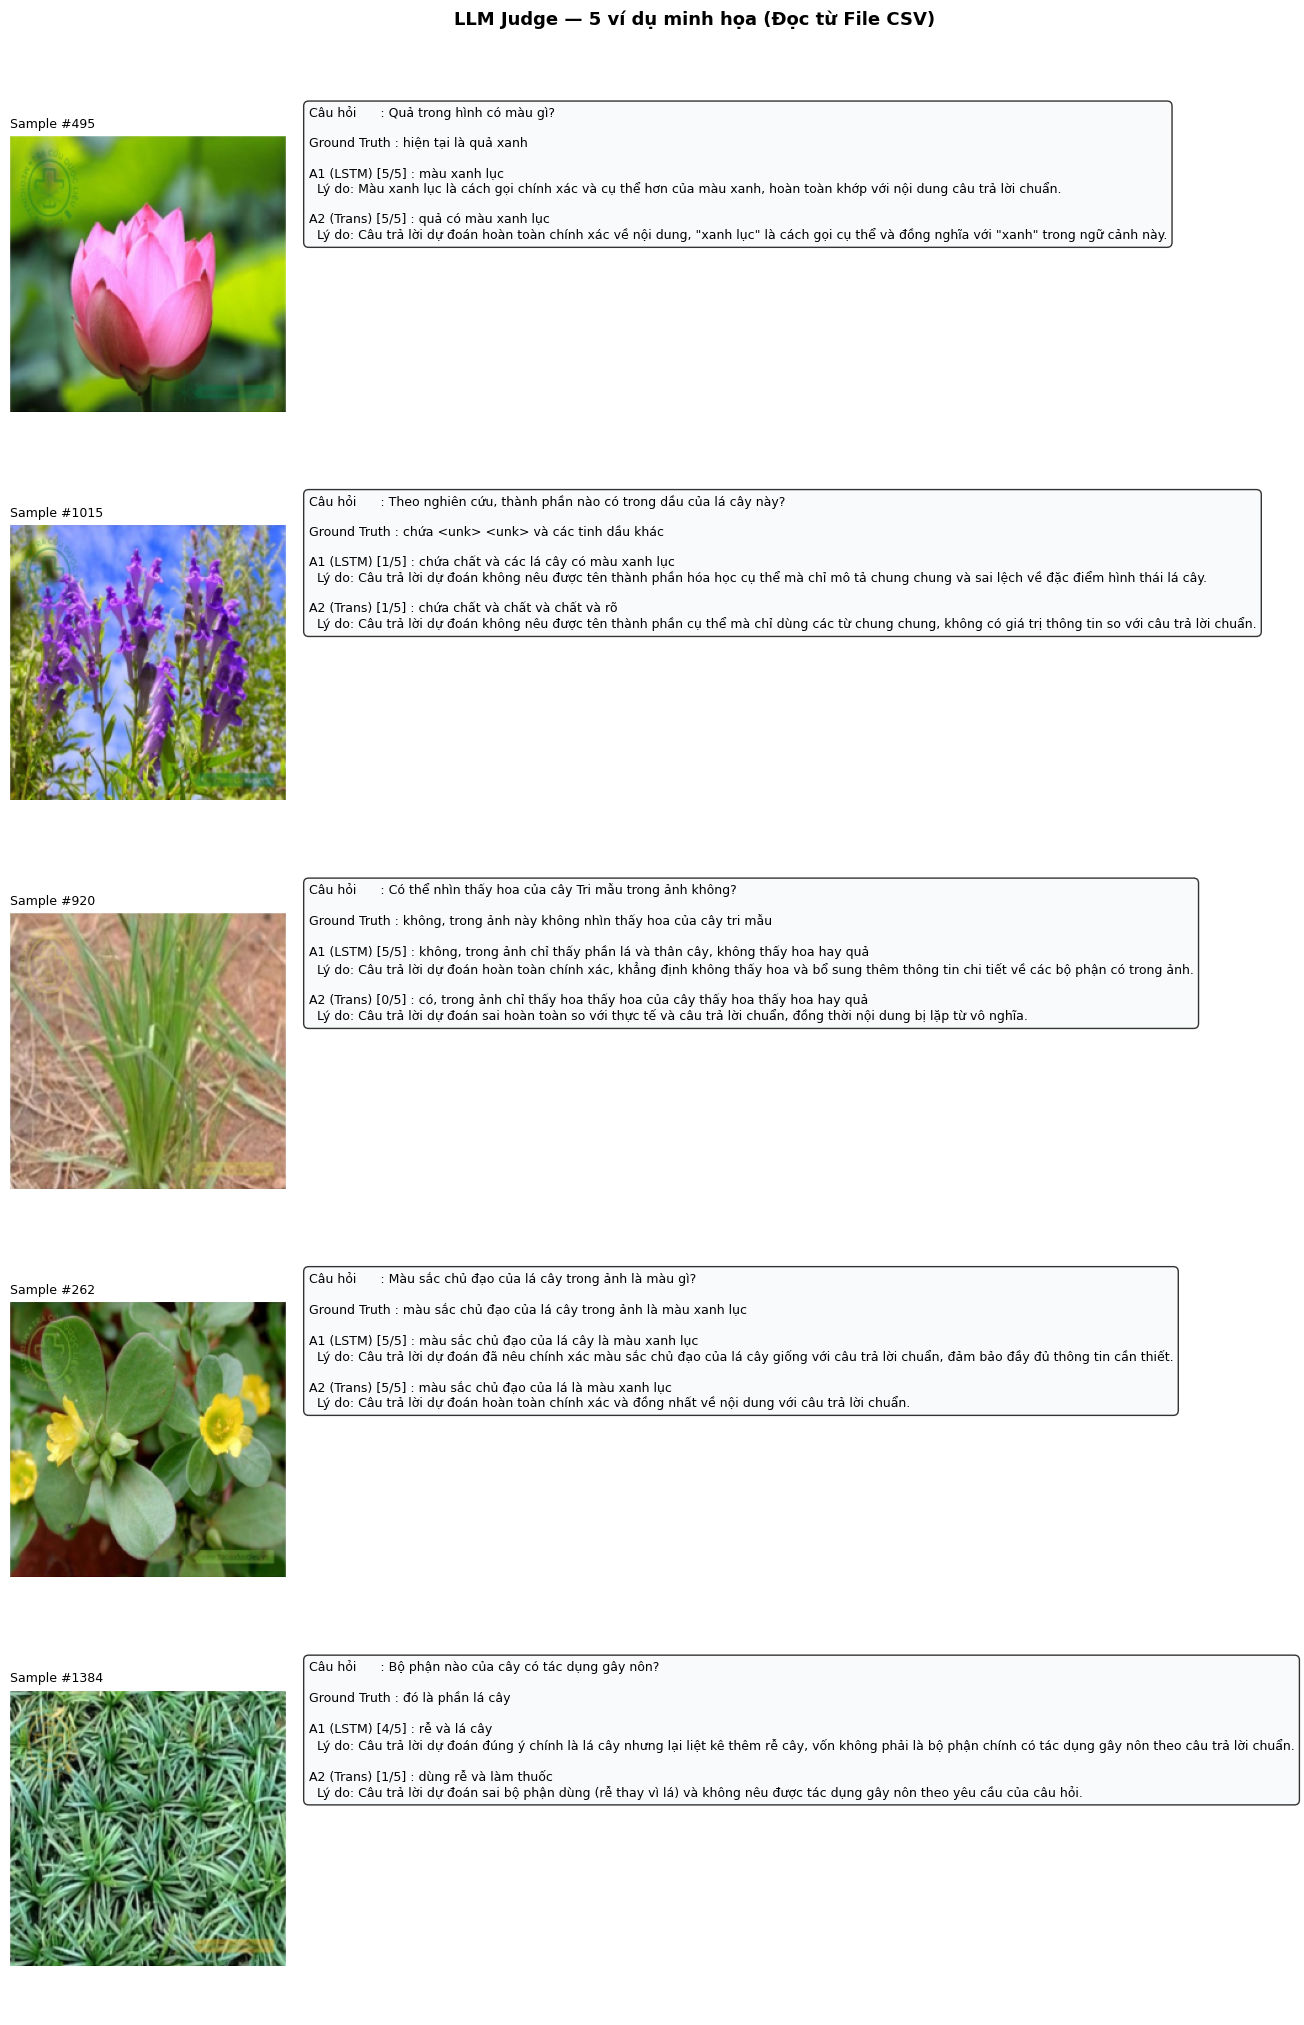

Ảnh minh họa: /content/logs/llm_judge_samples.png
Đã nạp xong biến llm_judge_avg_a1 và llm_judge_avg_a2 cho Mục 11.6


In [29]:
# ==========================================
# 11.5. LLM-AS-A-JUDGE (ĐỌC TỪ FILE CSV - KHÔNG GỌI API)
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("11.5. KẾT QUẢ LLM-AS-A-JUDGE (ĐỌC TỪ FILE CSV)")
print("=" * 60)

# Ưu tiên tìm file bạn tự tải lên /content/, nếu không có thì tìm trong LOG_DIR
CSV_PATH_1 = "/content/llm_judge_results.csv"
CSV_PATH_2 = os.path.join(LOG_DIR, "llm_judge_results.csv")

if os.path.exists(CSV_PATH_1):
    CSV_PATH = CSV_PATH_1
elif os.path.exists(CSV_PATH_2):
    CSV_PATH = CSV_PATH_2
else:
    raise FileNotFoundError("⚠️ KHÔNG TÌM THẤY FILE! Hãy upload file 'llm_judge_results.csv' vào thư mục /content/ rồi chạy lại cell này.")

print(f"Đang đọc dữ liệu LLM Judge từ: {CSV_PATH}")
judge_df = pd.read_csv(CSV_PATH)

# Lọc bỏ các mẫu bị lỗi API (nếu có score = -1)
valid_df = judge_df[judge_df["score_a1"] >= 0].copy()
print(f"Hoàn tất! Số lượng mẫu hợp lệ: {len(valid_df)}/{len(judge_df)}")

# KẾT QUẢ TỔNG HỢP
avg_a1, avg_a2 = valid_df["score_a1"].mean(), valid_df["score_a2"].mean()
std_a1, std_a2 = valid_df["score_a1"].std(),  valid_df["score_a2"].std()

print("\n" + "=" * 50)
print("KẾT QUẢ LLM-AS-A-JUDGE (Thang điểm 0-5)")
print("=" * 50)
print(f"{'Model':<22} {'TB':>8} {'Std':>8}")
print("-" * 42)
print(f"{'A1 (LSTM)':<22} {avg_a1:>8.4f} {std_a1:>8.4f}")
print(f"{'A2 (Transformer)':<22} {avg_a2:>8.4f} {std_a2:>8.4f}")
print("=" * 50)

print("\nPhân phối điểm A1:")
print(valid_df["score_a1"].value_counts().sort_index().to_string())
print("\nPhân phối điểm A2:")
print(valid_df["score_a2"].value_counts().sort_index().to_string())

# ==========================================
# BIỂU ĐỒ SO SÁNH
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ cột Điểm Trung Bình
ax1 = axes[0]
bars = ax1.bar(["A1 (LSTM)", "A2 (Transformer)"], [avg_a1, avg_a2],
               color=["#4C9BE8", "#F26522"], width=0.5,
               yerr=[std_a1, std_a2], capsize=8)
ax1.set_ylim(0, 5.5)
ax1.set_ylabel("Điểm trung bình (0-5)", fontsize=12)
ax1.set_title(f"LLM Judge — Điểm TB ({len(valid_df)} mẫu)", fontsize=12)
ax1.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, [avg_a1, avg_a2]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.3f}", ha="center", va="bottom", fontsize=13, fontweight="bold")

# Biểu đồ phân phối điểm (Histogram)
ax2 = axes[1]
bins = np.arange(-0.5, 6.5, 1)
ax2.hist(valid_df["score_a1"], bins=bins, alpha=0.6, label="A1 (LSTM)",        color="#4C9BE8")
ax2.hist(valid_df["score_a2"], bins=bins, alpha=0.6, label="A2 (Transformer)", color="#F26522")
ax2.set_xlabel("Điểm (0-5)", fontsize=12)
ax2.set_ylabel("Số mẫu", fontsize=12)
ax2.set_title("Phân phối điểm", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.suptitle(f"LLM-as-a-Judge (Load từ File CSV)", fontsize=13, fontweight="bold")
plt.tight_layout()
chart_path = os.path.join(LOG_DIR, "llm_judge_comparison.png")
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Biểu đồ: {chart_path}")

# ==========================================
# 5 MẪU VÍ DỤ CÓ ẢNH
# ==========================================
MEAN_ARR = np.array([0.485, 0.456, 0.406])
STD_ARR  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    return np.clip(STD_ARR * img + MEAN_ARR, 0, 1)

# Lấy 5 mẫu đầu tiên
top5 = valid_df.tail(5)
fig, axes = plt.subplots(len(top5), 2, figsize=(14, 4 * len(top5)),
                         gridspec_kw={"width_ratios": [1, 3]})

for row_i, (_, row) in enumerate(top5.iterrows()):
    # Lấy thông tin ảnh từ dataset bằng idx
    sample  = test_dataset[int(row["idx"])]
    img_np  = denormalize(sample["image"])
    ax_img  = axes[row_i][0]
    ax_text = axes[row_i][1]

    ax_img.imshow(img_np)
    ax_img.axis("off")
    ax_img.set_title(f"Sample #{int(row['idx'])}", fontsize=9, loc="left")

    info = (
        f"Câu hỏi      : {row['question']}\n\n"
        f"Ground Truth : {row['ground_truth']}\n\n"
        f"A1 (LSTM) [{row['score_a1']}/5] : {row['pred_a1']}\n"
        f"  Lý do: {row['reason_a1']}\n\n"
        f"A2 (Trans) [{row['score_a2']}/5] : {row['pred_a2']}\n"
        f"  Lý do: {row['reason_a2']}"
    )
    ax_text.text(0.01, 0.95, info, transform=ax_text.transAxes,
                 fontsize=9, verticalalignment="top",
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="#f8f9fa", alpha=0.8))
    ax_text.axis("off")

    avg_score    = (row["score_a1"] + row["score_a2"]) / 2
    border_color = "#27ae60" if avg_score >= 3 else "#c0392b"
    for spine in ax_img.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2)

plt.suptitle("LLM Judge — 5 ví dụ minh họa (Đọc từ File CSV)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
sample_path = os.path.join(LOG_DIR, "llm_judge_samples.png")
plt.savefig(sample_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Ảnh minh họa: {sample_path}")

# LƯU BIẾN TOÀN CỤC CHO MỤC 11.6
llm_judge_avg_a1 = avg_a1
llm_judge_avg_a2 = avg_a2
print("Đã nạp xong biến llm_judge_avg_a1 và llm_judge_avg_a2 cho Mục 11.6")




### 11.6 Bảng tổng hợp và biểu đồ so sánh

Tổng hợp tất cả metric của A1 và A2 vào một DataFrame và in ra dưới dạng bảng. Vẽ biểu đồ thanh (bar chart) để so sánh trực quan trên từng metric. Phân tích và nhận xét: Decoder nào tốt hơn và ở loại câu hỏi nào (Identification, Visual, Domain-Knowledge) thì sự chênh lệch rõ nhất.

11.6. BẢNG TỔNG HỢP VÀ BIỂU ĐỒ SO SÁNH

--- BẢNG TỔNG HỢP CÁC CHỈ SỐ ---


,A1 (LSTM),A2 (Transformer)
VQA Acc (Exact),0.0108,0.0061
BLEU-1,0.3760,0.2723
BLEU-4,0.1870,0.1125
ROUGE-L,0.4345,0.3932
METEOR,0.3114,0.2795
BERTScore F1,0.7929,0.7733
LLM Judge,0.3667,0.3293


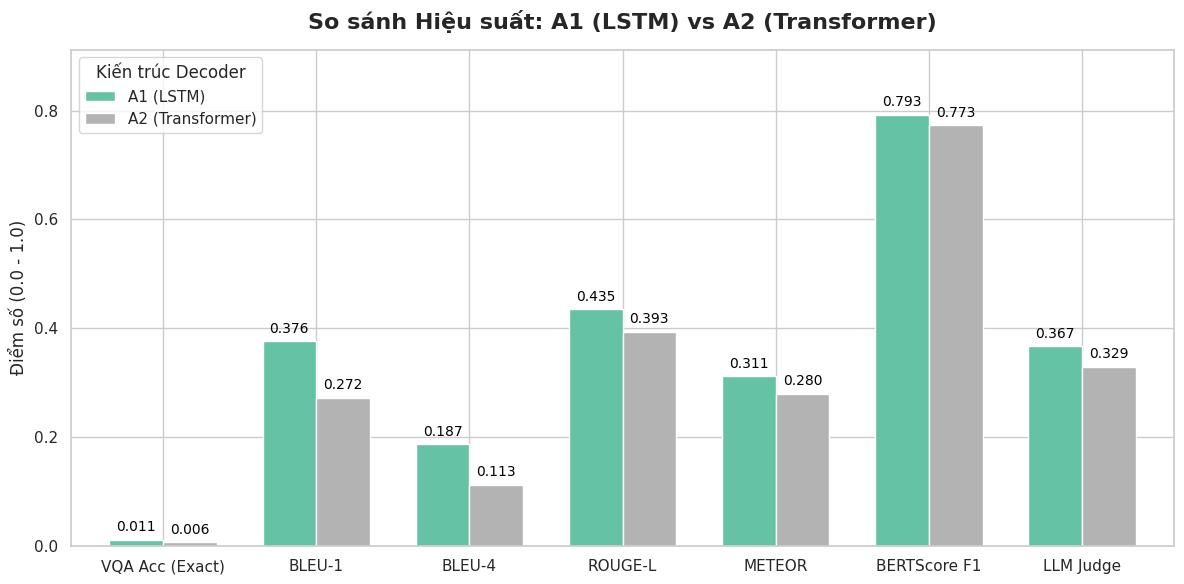

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

print("=" * 60)
print("11.6. BẢNG TỔNG HỢP VÀ BIỂU ĐỒ SO SÁNH")
print("=" * 60)

# Gom tất cả metrics lại (code được viết an toàn để bắt các biến kể cả khi bạn bỏ qua bước BERTScore)
metrics_data = {}

# Gắn LLM Judge score vào dict metric để get_metric() lấy được
if "llm_judge_avg_a1" in dir() and llm_judge_avg_a1:
    if detailed_metrics_a1 is not None:
        detailed_metrics_a1["llm_judge"] = llm_judge_avg_a1 / 5
    if detailed_metrics_a2 is not None:
        detailed_metrics_a2["llm_judge"] = llm_judge_avg_a2 / 5

# Hàm an toàn để lấy giá trị
def get_metric(detailed, test_m, bert_m, key):
    if detailed and key in detailed: return detailed[key]
    if test_m   and key in test_m:   return test_m[key]
    if bert_m   and key in bert_m:   return bert_m[key]
    return 0.0

keys = ["vqa_acc", "BLEU-1", "BLEU-4", "ROUGE-L", "METEOR", "F1", "llm_judge"]
labels = ["VQA Acc (Exact)", "BLEU-1", "BLEU-4", "ROUGE-L", "METEOR", "BERTScore F1", "LLM Judge"]

if 'has_a1' in locals() and has_a1:
    metrics_data['A1 (LSTM)'] = [get_metric(
        globals().get('detailed_metrics_a1'),
        globals().get('test_metrics_a1'),
        globals().get('bert_metrics_a1'),
        k
    ) for k in keys]

if 'has_a2' in locals() and has_a2:
    metrics_data['A2 (Transformer)'] = [get_metric(
        globals().get('detailed_metrics_a2'),
        globals().get('test_metrics_a2'),
        globals().get('bert_metrics_a2'),
        k
    ) for k in keys]



if not metrics_data:
    print("Chưa có dữ liệu đánh giá nào được tính toán!")
else:
    # 1. Tạo và in DataFrame bằng Pandas
    df = pd.DataFrame(metrics_data, index=labels)
    print("\n--- BẢNG TỔNG HỢP CÁC CHỈ SỐ ---")
    display(df.round(4))

    # 2. Vẽ biểu đồ Bar Chart trực quan bằng Seaborn
    sns.set_theme(style="whitegrid")
    ax = df.plot(kind="bar", figsize=(12, 6), colormap="Set2", width=0.7)

    plt.title("So sánh Hiệu suất: A1 (LSTM) vs A2 (Transformer)", fontsize=16, fontweight='bold', pad=15)
    plt.ylabel("Điểm số (0.0 - 1.0)", fontsize=12)
    plt.xticks(rotation=0, fontsize=11)

    # Tăng giới hạn trục Y để có chỗ ghi số liệu
    plt.ylim(0, df.max().max() * 1.15 if df.max().max() > 0 else 1.0)
    plt.legend(title="Kiến trúc Decoder", fontsize=11, loc='upper left')

    # Thêm nhãn giá trị (số liệu) lên đỉnh của từng cột
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:.3f}",
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10, color='black',
                        xytext=(0, 4), textcoords='offset points')

    plt.tight_layout()
    chart_path = os.path.join(LOG_DIR, "model_comparison_barchart.png")
    plt.savefig(chart_path, dpi=200, bbox_inches='tight')
    plt.show()


### 11.7. Phân tích lỗi định tính

Lấy ra 10 đến 15 ví dụ mà A1 và A2 cho kết quả khác nhau (một cái đúng, một cái sai; hoặc cả hai sai theo cách khác nhau). In ra: ảnh, câu hỏi, câu trả lời chuẩn, dự đoán của A1, dự đoán của A2. Phân tích nguyên nhân sai sót để tìm hiểu điểm mạnh và điểm yếu của từng kiến trúc.

11.7. PHAN TICH LOI DINH TINH (QUALITATIVE ERROR ANALYSIS)
Dang scan tap Test (vai phut)...

  CA HAI DUNG

[1] Cau hoi    : Lá của cây Bìm bìm dại trong ảnh có màu gì?
     Dap an GT  : lá của cây có màu xanh lục
     A1 (LSTM)  : lá của cây có màu xanh lục  [DUNG]
     A2 (Trans) : lá của cây có màu xanh lục  [DUNG]


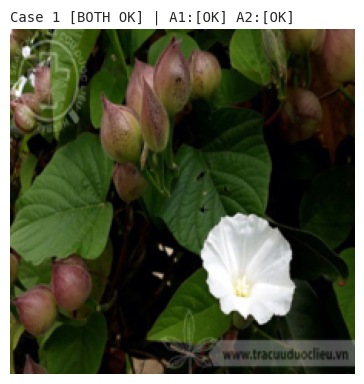


[2] Cau hoi    : Lá của cây Thạch hộc trong ảnh có màu gì?
     Dap an GT  : lá của cây có màu xanh lục
     A1 (LSTM)  : lá của cây có màu xanh lục  [DUNG]
     A2 (Trans) : lá của cây có màu xanh lục  [DUNG]


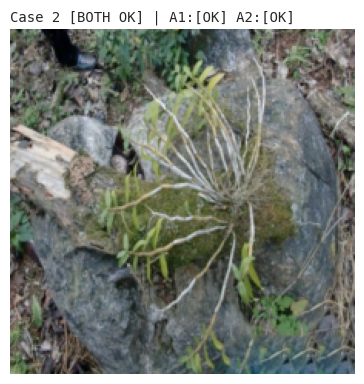


  MOT DUNG / MOT SAI

[3] Cau hoi    : Dược liệu này thường phân bố ở đâu tại Việt Nam?
     Dap an GT  : các tỉnh miền núi phía bắc
     A1 (LSTM)  : các tỉnh miền núi phía bắc  [DUNG]
     A2 (Trans) : vùng núi núi núi và việt nam  [SAI] 


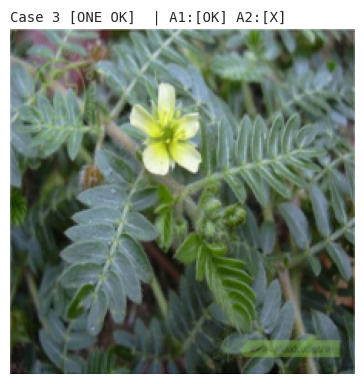


[4] Cau hoi    : Cụm hoa trong hình có hình dáng gì?
     Dap an GT  : cụm hoa hình cầu
     A1 (LSTM)  : cụm hoa hình dạng tròn hoặc hình cầu nhỏ  [SAI] 
     A2 (Trans) : cụm hoa hình cầu  [DUNG]


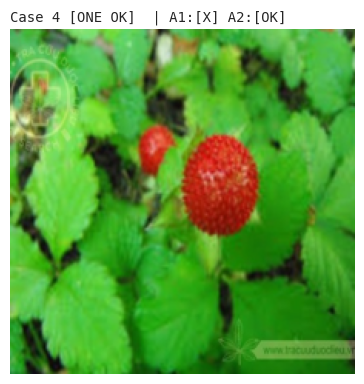


[5] Cau hoi    : Có thể nhìn thấy hoa hoặc quả của cây Xương sông trong ảnh này không?
     Dap an GT  : không, trong ảnh chỉ thấy lá và thân cây, không thấy hoa hay quả
     A1 (LSTM)  : không, trong ảnh chỉ thấy lá và thân cây, không thấy hoa hay quả  [DUNG]
     A2 (Trans) : không, trong ảnh chỉ thấy hoa thấy hoa thấy hoa thấy quả  [SAI] 


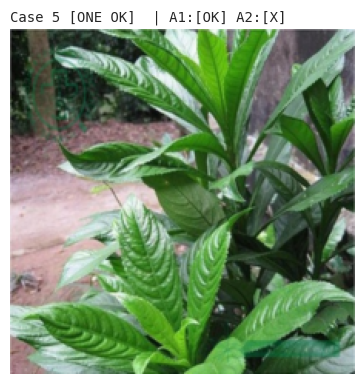


[6] Cau hoi    : Tên dược liệu trong ảnh là gì?
     Dap an GT  : tên dược liệu trong ảnh là thạch sùng
     A1 (LSTM)  : tên dược liệu trong ảnh là thạch sùng  [DUNG]
     A2 (Trans) : dược liệu trong ảnh là thạch thạch thạch thảo  [SAI] 


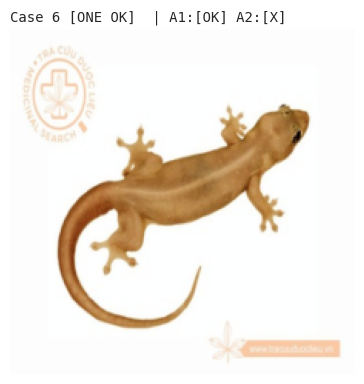


  CA HAI SAI

[7] Cau hoi    : Hãy cho biết tên gọi của dược liệu trong bức ảnh này?
     Dap an GT  : tên của nó là kinh giới
     A1 (LSTM)  : đây là cỏ xanh  [SAI] 
     A2 (Trans) : tên của nó là cây dưa dại  [SAI] 


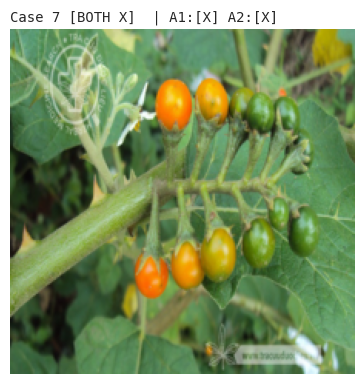


[8] Cau hoi    : Cuống hoa của cây trong hình dài bao nhiêu?
     Dap an GT  : dài chừng mười centimet
     A1 (LSTM)  : cuống hoa dài từ 5 đến cm  [SAI] 
     A2 (Trans) : từ 5 đến 5 đến 5 cm  [SAI] 


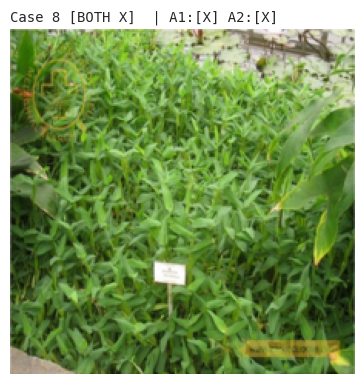


THONG KE:
  [BOTH OK]: 2/2 mau
  [ONE OK] : 4/4 mau
  [BOTH X] : 2/2 mau

PHAN TICH NGUYEN NHAN:
  [BOTH OK]: Ca 2 mo hinh hieu dung ngu canh.
  [ONE OK] : LSTM thang o cau ngan; Trans thang o cau phu thuoc xa.
  [BOTH X] : Anh kho hoac tu chuyen nganh rat hiem trong train.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import os

print("=" * 60)
print("11.7. PHAN TICH LOI DINH TINH (QUALITATIVE ERROR ANALYSIS)")
print("=" * 60)


def qualitative_analysis(model_a1, model_a2, dataset, answer_vocab, device=DEVICE):
    if not (model_a1 and model_a2):
        print("Can co ca hai mo hinh A1 va A2!")
        return

    actual_a1 = model_a1.module if isinstance(model_a1, torch.nn.DataParallel) else model_a1
    actual_a2 = model_a2.module if isinstance(model_a2, torch.nn.DataParallel) else model_a2
    actual_a1.eval()
    actual_a2.eval()

    indices = list(range(len(dataset)))
    random.shuffle(indices)

    mean_arr = np.array([0.485, 0.456, 0.406])
    std_arr  = np.array([0.229, 0.224, 0.225])

    # --- Buoc 1: Thu thap cases theo quota can bang ---
    quota   = {"both_correct": 2, "one_correct": 4, "both_wrong": 2}
    buckets = {"both_correct": [], "one_correct": [], "both_wrong": []}

    with torch.no_grad():
        for idx in indices:
            if all(len(buckets[k]) >= quota[k] for k in quota):
                break

            sample         = dataset[idx]
            image_tensor   = sample["image"].unsqueeze(0).to(device)
            input_ids      = sample["input_ids"].unsqueeze(0).to(device)
            attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

            gt_norm      = normalize_answer(answer_vocab.decode(sample["answer_ids"].tolist()))
            pred_a1_norm = normalize_answer(answer_vocab.decode(
                actual_a1.predict(image_tensor, input_ids, attention_mask, beam_size=1)))
            pred_a2_norm = normalize_answer(answer_vocab.decode(
                actual_a2.predict(image_tensor, input_ids, attention_mask, beam_size=1)))

            a1_ok = pred_a1_norm == gt_norm
            a2_ok = pred_a2_norm == gt_norm

            if   a1_ok and a2_ok:       key = "both_correct"
            elif a1_ok or  a2_ok:       key = "one_correct"
            else:                        key = "both_wrong"

            if len(buckets[key]) >= quota[key]:
                continue

            question_text = phobert_tokenizer.decode(
                sample["input_ids"].tolist(), skip_special_tokens=True)
            img = image_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
            img = np.clip(std_arr * img + mean_arr, 0, 1)

            buckets[key].append({
                "img": img, "question": question_text,
                "gt": gt_norm, "a1": pred_a1_norm, "a2": pred_a2_norm,
                "a1_ok": a1_ok, "a2_ok": a2_ok, "category": key,
            })

    cases = buckets["both_correct"] + buckets["one_correct"] + buckets["both_wrong"]
    if not cases:
        print("Khong tim duoc truong hop nao.")
        return

    # --- Buoc 2 + 3: Print text → hien thi anh xen ke nhau ---
    cat_header = {
        "both_correct": "CA HAI DUNG",
        "one_correct":  "MOT DUNG / MOT SAI",
        "both_wrong":   "CA HAI SAI",
    }
    cat_label = {
        "both_correct": "[BOTH OK]",
        "one_correct":  "[ONE OK] ",
        "both_wrong":   "[BOTH X] ",
    }

    all_imgs = []    # de luu anh tong hop cuoi cung
    current_cat = None

    for i, c in enumerate(cases, 1):
        # In header phan loai neu doi nhom
        if c["category"] != current_cat:
            current_cat = c["category"]
            print(f"\n{'='*55}")
            print(f"  {cat_header[current_cat]}")
            print(f"{'='*55}")

        # Print text truoc (tieng Viet hien thi dung)
        a1_tag = "[DUNG]" if c["a1_ok"] else "[SAI] "
        a2_tag = "[DUNG]" if c["a2_ok"] else "[SAI] "
        print(f"\n[{i}] Cau hoi    : {c['question']}")
        print(f"     Dap an GT  : {c['gt']}")
        print(f"     A1 (LSTM)  : {c['a1']}  {a1_tag}")
        print(f"     A2 (Trans) : {c['a2']}  {a2_tag}")

        # Hien thi anh ngay sau text — KHONG co tieng Viet trong title
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        ax.imshow(c["img"])
        ax.axis("off")
        # Title chi dung ASCII + so case
        lbl = cat_label[c["category"]]
        ax.set_title(
            f"Case {i} {lbl} | A1:{('[OK]' if c['a1_ok'] else '[X]')} "
            f"A2:{('[OK]' if c['a2_ok'] else '[X]')}",
            fontsize=10, family="monospace", loc="left"
        )
        plt.tight_layout()
        # Luu anh rieng tung case
        img_path = os.path.join(LOG_DIR, f"case_{i:02d}.png")
        plt.savefig(img_path, dpi=120, bbox_inches="tight")
        all_imgs.append(img_path)
        plt.show()

    # --- Buoc 4: Thong ke ---
    print(f"\n{'='*55}")
    print("THONG KE:")
    for k, v in buckets.items():
        print(f"  {cat_label[k]}: {len(v)}/{quota[k]} mau")
    print("\nPHAN TICH NGUYEN NHAN:")
    print("  [BOTH OK]: Ca 2 mo hinh hieu dung ngu canh.")
    print("  [ONE OK] : LSTM thang o cau ngan; Trans thang o cau phu thuoc xa.")
    print("  [BOTH X] : Anh kho hoac tu chuyen nganh rat hiem trong train.")


# --- Goi ham ---
if 'has_a1' in locals() and has_a1 and 'has_a2' in locals() and has_a2:
    print("Dang scan tap Test (vai phut)...")
    qualitative_analysis(vqa_a1, vqa_a2, test_dataset, answer_vocab, device=DEVICE)
else:
    print("Can train va load thanh cong ca 2 mo hinh (A1, A2).")





## 12.Preference data

In [ ]:
import json, random, torch, os

OUTPUT_PATH = "/content/dpo_preference_data.json"
NUM_SAMPLES = 1500
random.seed(42)

actual_a1 = vqa_a1.module if isinstance(vqa_a1, torch.nn.DataParallel) else vqa_a1
actual_a2 = vqa_a2.module if isinstance(vqa_a2, torch.nn.DataParallel) else vqa_a2
actual_a1.eval(); actual_a2.eval()

indices = random.sample(range(len(val_dataset)), min(NUM_SAMPLES, len(val_dataset)))
dpo_data = []

with torch.no_grad():
    for idx in indices:
        sample = val_dataset[idx]
        img_t  = sample["image"].unsqueeze(0).to(DEVICE)
        ids_t  = sample["input_ids"].unsqueeze(0).to(DEVICE)
        mask_t = sample["attention_mask"].unsqueeze(0).to(DEVICE)

        question = phobert_tokenizer.decode(sample["input_ids"].tolist(), skip_special_tokens=True)
        gt       = normalize_answer(answer_vocab.decode(sample["answer_ids"].tolist()))
        pred_a1  = normalize_answer(answer_vocab.decode(actual_a1.predict(img_t, ids_t, mask_t, beam_size=1)))
        pred_a2  = normalize_answer(answer_vocab.decode(actual_a2.predict(img_t, ids_t, mask_t, beam_size=1)))

        # Bỏ qua nếu cả 2 đều đúng hoặc cả 2 đều trùng nhau
        if pred_a1 == gt and pred_a2 == gt: continue
        if pred_a1 == pred_a2:              continue

        # Chọn rejected = pred nào sai (ưu tiên cái sai hoàn toàn)
        a1_wrong = pred_a1 != gt
        a2_wrong = pred_a2 != gt

        if a1_wrong and a2_wrong:
            # Cả 2 sai → lấy cái ngắn hơn (thường là lặp từ, sai nặng hơn)
            rejected     = pred_a1 if len(pred_a1) < len(pred_a2) else pred_a2
            rejected_src = "model_a1" if len(pred_a1) < len(pred_a2) else "model_a2"
        elif a1_wrong:
            rejected, rejected_src = pred_a1, "model_a1"
        else:
            rejected, rejected_src = pred_a2, "model_a2"

        if rejected.strip() == gt.strip(): continue

        dpo_data.append({
            "idx":             idx,
            "question":        question,
            "ground_truth":    gt,
            "chosen":          gt,
            "chosen_source":   "ground_truth",
            "rejected":        rejected,
            "rejected_source": rejected_src,
        })

print(f"Tổng preference pairs: {len(dpo_data)}")

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(dpo_data, f, ensure_ascii=False, indent=2)
print(f"Đã lưu: {OUTPUT_PATH}")



Tổng preference pairs: 1441
Đã lưu: /content/dpo_preference_data.json


### 12.1 Cấu hình

In [ ]:
import json, copy, os, torch, inspect
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm

DPO_BETA       = 0.1
DPO_EPOCHS     = 3
DPO_BATCH_SIZE = 2
DPO_LR         = 1e-5
MAX_ANS_LEN    = 30
DPO_DATA_PATH  = "/content/dpo_preference_data.json"
DPO_CKPT_DIR   = "/content/dpo_checkpoints"
os.makedirs(DPO_CKPT_DIR, exist_ok=True)
print("Config OK")


Config OK


### 12.2 DPO dataset và DPO DataLoader

In [ ]:
class DPOVQADataset(Dataset):
    def __init__(self, json_path, base_dataset, answer_vocab, tokenizer, max_ans_len=MAX_ANS_LEN):
        with open(json_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.base     = base_dataset
        self.vocab    = answer_vocab
        self.tok      = tokenizer
        self.max_len  = max_ans_len

    def _encode(self, text):
        sos = self.vocab.word2idx["<SOS>"]
        eos = self.vocab.word2idx["<EOS>"]
        pad = self.vocab.word2idx["<PAD>"]

        # TRUYỀN THÊM self.max_len VÀO ĐÂY
        encoded_text = self.vocab.encode(text, self.max_len)

        ids = [sos] + encoded_text + [eos]
        ids = ids[:self.max_len]
        ids += [pad] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)


    def __len__(self):
        return len(self.records)

    def __getitem__(self, i):
        rec    = self.records[i]
        sample = self.base[rec["idx"]]
        return {
            "image":          sample["image"],
            "input_ids":      sample["input_ids"],
            "attention_mask": sample["attention_mask"],
            "chosen_ids":     self._encode(rec["chosen"]),
            "rejected_ids":   self._encode(rec["rejected"]),
        }

dpo_full = DPOVQADataset(DPO_DATA_PATH, val_dataset, answer_vocab, phobert_tokenizer)

n_train = int(len(dpo_full) * 0.8)
n_val   = len(dpo_full) - n_train
dpo_train_set, dpo_val_set = torch.utils.data.random_split(
    dpo_full, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
dpo_train_loader = DataLoader(dpo_train_set, batch_size=DPO_BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
dpo_val_loader   = DataLoader(dpo_val_set,   batch_size=DPO_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Total samples : {len(dpo_full)}")
print(f"Train / Val   : {len(dpo_train_set)} / {len(dpo_val_set)}")

# Xem 1 mẫu
s = dpo_full[0]
print(f"\nSample keys   : {list(s.keys())}")
print(f"chosen_ids    : {s['chosen_ids'][:10]}...")
print(f"rejected_ids  : {s['rejected_ids'][:10]}...")


Total samples : 1441
Train / Val   : 1152 / 289

Sample keys   : ['image', 'input_ids', 'attention_mask', 'chosen_ids', 'rejected_ids']
chosen_ids    : tensor([   1,    1, 2237, 1177, 1011, 3508, 2937, 4304, 5361, 1023])...
rejected_ids  : tensor([   1,    1, 2237, 1177, 1011, 1023, 2535, 4876, 2422,    2])...


### 12.3 compute_log_prob

In [ ]:
def compute_log_prob(model, pixel_values, input_ids, attention_mask, answer_ids):
    # Dùng model gốc (bỏ qua DataParallel nếu có)
    actual = model.module if isinstance(model, torch.nn.DataParallel) else model

    # 1. Gọi trực tiếp hàm forward của VQAModel (đã xử lý sẵn mọi thứ)
    logits = actual(pixel_values, input_ids, attention_mask, answer_ids)  # (B, L-1, V)

    # 2. Trích xuất target để tính loss
    dec_target = answer_ids[:, 1:]    # (B, L-1)

    # 3. Tính log xác suất
    log_probs = F.log_softmax(logits, dim=-1)
    token_lp  = log_probs.gather(2, dec_target.unsqueeze(-1)).squeeze(-1)

    # 4. Loại bỏ phần tính toán cho token <PAD>
    pad_idx   = answer_vocab.word2idx["<PAD>"]
    pad_mask  = (dec_target != pad_idx).float()

    return (token_lp * pad_mask).sum(dim=-1)   # (B,)

# ===============================================
# Kiểm tra lại ngay
# ===============================================
s   = dpo_full[0]
_pv = s["image"].unsqueeze(0).to(DEVICE)
_id = s["input_ids"].unsqueeze(0).to(DEVICE)
_mk = s["attention_mask"].unsqueeze(0).to(DEVICE)
_ch = s["chosen_ids"].unsqueeze(0).to(DEVICE)
_rj = s["rejected_ids"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    lp_a1_ch = compute_log_prob(vqa_a1, _pv, _id, _mk, _ch)
    lp_a1_rj = compute_log_prob(vqa_a1, _pv, _id, _mk, _rj)
    lp_a2_ch = compute_log_prob(vqa_a2, _pv, _id, _mk, _ch)
    lp_a2_rj = compute_log_prob(vqa_a2, _pv, _id, _mk, _rj)

print(f"A1 | chosen={lp_a1_ch.item():.4f} | rejected={lp_a1_rj.item():.4f}")
print(f"A2 | chosen={lp_a2_ch.item():.4f} | rejected={lp_a2_rj.item():.4f}")
print("compute_log_prob OK")



A1 | chosen=-26.5213 | rejected=-22.1084
A2 | chosen=-28.7480 | rejected=-24.2477
compute_log_prob OK ✓


### 12.4 DPO Loss + train/eval functions:

In [ ]:
def dpo_loss(model, ref_model, batch, beta=DPO_BETA):
    pv   = batch["image"].to(DEVICE)
    ids  = batch["input_ids"].to(DEVICE)
    mask = batch["attention_mask"].to(DEVICE)
    cho  = batch["chosen_ids"].to(DEVICE)
    rej  = batch["rejected_ids"].to(DEVICE)

    lp_ch  = compute_log_prob(model, pv, ids, mask, cho)
    lp_rj  = compute_log_prob(model, pv, ids, mask, rej)
    with torch.no_grad():
        ref_lp_ch = compute_log_prob(ref_model, pv, ids, mask, cho)
        ref_lp_rj = compute_log_prob(ref_model, pv, ids, mask, rej)

    logits = beta * ((lp_ch - ref_lp_ch) - (lp_rj - ref_lp_rj))
    loss   = -F.logsigmoid(logits).mean()
    acc    = (lp_ch > lp_rj).float().mean().item()
    return loss, acc


def train_dpo_epoch(model, ref_model, loader, optimizer, scaler):
    model.train()
    t_loss, t_acc, n = 0, 0, 0
    for batch in tqdm(loader, desc="  Train", leave=False):
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss, acc = dpo_loss(model, ref_model, batch)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        t_loss += loss.item(); t_acc += acc; n += 1
    return t_loss / n, t_acc / n


def eval_dpo_epoch(model, ref_model, loader):
    model.eval()
    t_loss, t_acc, n = 0, 0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="  Val  ", leave=False):
            with torch.cuda.amp.autocast():
                loss, acc = dpo_loss(model, ref_model, batch)
            t_loss += loss.item(); t_acc += acc; n += 1
    return t_loss / n, t_acc / n

print("DPO functions OK ")


DPO functions OK 


### 12.5 Train A1 (LSTM):

In [ ]:
print("=" * 55)
print("DPO Training: A1 (LSTM)")
print("=" * 55)

ref_a1 = copy.deepcopy(vqa_a1).to(DEVICE)
ref_a1.eval()
for p in ref_a1.parameters(): p.requires_grad = False

opt_a1    = AdamW(filter(lambda p: p.requires_grad, vqa_a1.parameters()), lr=DPO_LR)
scaler_a1 = torch.cuda.amp.GradScaler()
best_a1   = float("inf")
history_a1_dpo = []

for epoch in range(1, DPO_EPOCHS + 1):
    tr_loss, tr_acc = train_dpo_epoch(vqa_a1, ref_a1, dpo_train_loader, opt_a1, scaler_a1)
    vl_loss, vl_acc = eval_dpo_epoch(vqa_a1, ref_a1, dpo_val_loader)
    history_a1_dpo.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": vl_loss})
    print(f"Epoch {epoch}/{DPO_EPOCHS} | Train Loss={tr_loss:.4f} Acc={tr_acc:.3f} | Val Loss={vl_loss:.4f} Acc={vl_acc:.3f}")
    if vl_loss < best_a1:
        best_a1 = vl_loss
        torch.save(vqa_a1.state_dict(), f"{DPO_CKPT_DIR}/A1_LSTM_dpo_best.pt")
        print("  → Saved best A1 DPO checkpoint")

print("A1 DPO Done ")


DPO Training: A1 (LSTM)


/tmp/ipykernel_742/1620069139.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_a1 = torch.cuda.amp.GradScaler()


  Train:   0%|          | 0/576 [00:00<?, ?it/s]

/tmp/ipykernel_742/225097397.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Val  :   0%|          | 0/145 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss=0.3123 Acc=0.578 | Val Loss=0.2903 Acc=0.672
  → Saved best A1 DPO checkpoint


  Train:   0%|          | 0/576 [00:00<?, ?it/s]

  Val  :   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss=0.2213 Acc=0.730 | Val Loss=0.2694 Acc=0.790
  → Saved best A1 DPO checkpoint
A1 DPO Done 


### 12.6 Train A2 (Transformer):

In [ ]:
print("=" * 55)
print("DPO Training: A2 (Transformer)")
print("=" * 55)

ref_a2 = copy.deepcopy(vqa_a2).to(DEVICE)
ref_a2.eval()
for p in ref_a2.parameters(): p.requires_grad = False

opt_a2    = AdamW(filter(lambda p: p.requires_grad, vqa_a2.parameters()), lr=DPO_LR)
scaler_a2 = torch.cuda.amp.GradScaler()
best_a2   = float("inf")
history_a2_dpo = []

for epoch in range(1, DPO_EPOCHS + 1):
    tr_loss, tr_acc = train_dpo_epoch(vqa_a2, ref_a2, dpo_train_loader, opt_a2, scaler_a2)
    vl_loss, vl_acc = eval_dpo_epoch(vqa_a2, ref_a2, dpo_val_loader)
    history_a2_dpo.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": vl_loss})
    print(f"Epoch {epoch}/{DPO_EPOCHS} | Train Loss={tr_loss:.4f} Acc={tr_acc:.3f} | Val Loss={vl_loss:.4f} Acc={vl_acc:.3f}")
    if vl_loss < best_a2:
        best_a2 = vl_loss
        torch.save(vqa_a2.state_dict(), f"{DPO_CKPT_DIR}/A2_Transformer_dpo_best.pt")
        print("  -> Saved best A2 DPO checkpoint")

print("A2 DPO Done ")


DPO Training: A2 (Transformer)


/tmp/ipykernel_742/2168636007.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_a2 = torch.cuda.amp.GradScaler()


  Train:   0%|          | 0/576 [00:00<?, ?it/s]

/tmp/ipykernel_742/225097397.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Val  :   0%|          | 0/145 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss=0.2998 Acc=0.621 | Val Loss=0.3245 Acc=0.693
  -> Saved best A2 DPO checkpoint


  Train:   0%|          | 0/576 [00:00<?, ?it/s]

  Val  :   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss=0.2418 Acc=0.735 | Val Loss=0.3243 Acc=0.766
  -> Saved best A2 DPO checkpoint
A2 DPO Done 


### 12.7 Đẩy lên HuggingFace:

In [ ]:
import os
from huggingface_hub import HfApi

# Sử dụng trực tiếp token và repo ID từ phần cấu hình ban đầu của bạn
api = HfApi(token=HF_HUB_TOKEN)

# Thư mục lưu checkpoint DPO (như đã cấu hình trong hàm train ở mục 12.5, 12.6)
DPO_DIR = "/content/dpo_checkpoints"

# Danh sách các file DPO cần upload và đường dẫn tương ứng trên HuggingFace Hub
# Tên file bên trái là file local, bên phải là thư mục/tên file lưu trên Hub
dpo_files = [
    ("A1_LSTM_dpo_best.pt", "DPO/dpo_a1_lstm_best.pth"),
    ("A2_Transformer_dpo_best.pt", "DPO/dpo_a2_transformer_best.pth")
]

print(f"Bắt đầu đẩy các checkpoint DPO lên repo: {HF_HUB_REPO_ID}")
print("-" * 50)

for local_file, repo_path in dpo_files:
    local_path = os.path.join(DPO_DIR, local_file)

    # Kiểm tra xem file có tồn tại không trước khi push
    if os.path.exists(local_path):
        print(f"Đang đẩy file: {local_file}...")
        try:
            api.upload_file(
                path_or_fileobj=local_path,
                path_in_repo=repo_path,
                repo_id=HF_HUB_REPO_ID,
                repo_type="model"
            )
            print(f"  Đã lưu thành công tại: {repo_path}")
        except Exception as e:
            print(f"  Lỗi khi upload {local_file}: {e}")
    else:
        print(f"  CẢNH BÁO: Không tìm thấy file {local_path}!")
        print("     (Có thể bạn chưa chạy xong quá trình train DPO hoặc tên file bị lưu khác đi).")

print("-" * 50)
print("Hoàn tất quá trình upload!")



Bắt đầu đẩy các checkpoint DPO lên repo: azan100an/vqa-herb-checkpoints-Vit_base_colab
--------------------------------------------------
Đang đẩy file: A1_LSTM_dpo_best.pt...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...oints/A1_LSTM_dpo_best.pt:   0%|          |  549kB /  932MB            

  Đã lưu thành công tại: DPO/dpo_a1_lstm_best.pth
Đang đẩy file: A2_Transformer_dpo_best.pt...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...2_Transformer_dpo_best.pt:   6%|5         | 54.7MB /  917MB            

  Đã lưu thành công tại: DPO/dpo_a2_transformer_best.pth
--------------------------------------------------
Hoàn tất quá trình upload!


## 13.So sánh SFT và DPO

### 13.1 Nạp trọng số DPO từ HuggingFace

In [31]:
# ==========================================
# 13.1 NẠP MÔ HÌNH DPO TỪ HUGGING FACE HUB
# ==========================================
import os
import torch
from huggingface_hub import hf_hub_download

print("=" * 60)
print("13.1 NẠP TRỌNG SỐ DPO TỪ HUGGING FACE HUB")
print("=" * 60)

def load_dpo_model(model, repo_filename, model_name):
    print(f"\nĐang tải {model_name} từ HuggingFace Hub...")
    try:
        # Tải file trực tiếp từ Hub (Nó sẽ lưu vào cache cục bộ của HuggingFace)
        local_path = hf_hub_download(
            repo_id=HF_HUB_REPO_ID,
            filename=repo_filename,
            token=HF_HUB_TOKEN
        )
        print("  -> Tải file thành công!")
    except Exception as e:
        print(f"  -> Lỗi tải file: {e}")
        return False

    print("  -> Đang nạp trọng số DPO vào model...")
    try:
        ckpt = torch.load(local_path, map_location=DEVICE)

        # Checkpoint DPO chỉ lưu thuần túy model_state_dict (như ta đã phân tích ở 12.6)
        # Bóc bỏ "module." nếu hồi train DPO có dùng DataParallel
        from collections import OrderedDict
        new_sd = OrderedDict()
        for k, v in ckpt.items():
            name = k[7:] if k.startswith("module.") else k
            new_sd[name] = v

        actual_model = model.module if isinstance(model, torch.nn.DataParallel) else model
        actual_model.load_state_dict(new_sd)
        actual_model.eval()

        print(f"  -> Thành công: {model_name} đã sẵn sàng!")
        return True
    except Exception as e:
        print(f"  -> Lỗi nạp trọng số: {e}")
        return False

# Tên file trên repo HF mà bạn đã push ở mục 12.7
has_dpo_a1 = load_dpo_model(vqa_a1, "DPO/dpo_a1_lstm_best.pth", "A1 (LSTM DPO)")
has_dpo_a2 = load_dpo_model(vqa_a2, "DPO/dpo_a2_transformer_best.pth", "A2 (Transformer DPO)")


13.1 NẠP TRỌNG SỐ DPO TỪ HUGGING FACE HUB

Đang tải A1 (LSTM DPO) từ HuggingFace Hub...


DPO/dpo_a1_lstm_best.pth:   0%|          | 0.00/932M [00:00<?, ?B/s]

  -> Tải file thành công!
  -> Đang nạp trọng số DPO vào model...
  -> Thành công: A1 (LSTM DPO) đã sẵn sàng!

Đang tải A2 (Transformer DPO) từ HuggingFace Hub...


DPO/dpo_a2_transformer_best.pth:   0%|          | 0.00/917M [00:00<?, ?B/s]

  -> Tải file thành công!
  -> Đang nạp trọng số DPO vào model...
  -> Thành công: A2 (Transformer DPO) đã sẵn sàng!


### 13.2 Chạy đánh giá đo lường các Model DPO

In [32]:
# ==========================================
# 13.2 ĐÁNH GIÁ MÔ HÌNH DPO
# ==========================================
print("=" * 60)
print("13.2 ĐÁNH GIÁ MÔ HÌNH DPO TRÊN TẬP TEST")
print("=" * 60)

dpo_test_a1, dpo_detailed_a1, dpo_bert_a1 = None, None, None
dpo_test_a2, dpo_detailed_a2, dpo_bert_a2 = None, None, None

if has_dpo_a1:
    print("\n[DPO A1 - LSTM] Đang đánh giá VQA Acc, BLEU, ROUGE, METEOR...")
    dpo_test_a1 = evaluate(vqa_a1, test_loader, vocab, beam_size=1, device=DEVICE)
    dpo_detailed_a1 = compute_comprehensive_metrics(vqa_a1, test_loader, vocab, DEVICE)
    try:
        print("Đang tính BERTScore...")
        dpo_bert_a1 = compute_bertscore(vqa_a1, test_loader, vocab, DEVICE)
    except Exception as e:
        print("Bỏ qua BERTScore:", e)

if has_dpo_a2:
    print("\n[DPO A2 - Transformer] Đang đánh giá VQA Acc, BLEU, ROUGE, METEOR...")
    dpo_test_a2 = evaluate(vqa_a2, test_loader, vocab, beam_size=1, device=DEVICE)
    dpo_detailed_a2 = compute_comprehensive_metrics(vqa_a2, test_loader, vocab, DEVICE)
    try:
        print("Đang tính BERTScore...")
        dpo_bert_a2 = compute_bertscore(vqa_a2, test_loader, vocab, DEVICE)
    except Exception as e:
        print("Bỏ qua BERTScore:", e)

print("\nĐánh giá DPO hoàn tất!")


13.2 ĐÁNH GIÁ MÔ HÌNH DPO TRÊN TẬP TEST

[DPO A1 - LSTM] Đang đánh giá VQA Acc, BLEU, ROUGE, METEOR...
  Eval   20/133 | 00:14
  Eval   40/133 | 00:27
  Eval   60/133 | 00:41
  Eval   80/133 | 00:54
  Eval  100/133 | 01:08
  Eval  120/133 | 01:22
  Eval  133/133 | 01:31

  Ket qua danh gia (2122 mau | 01:31):
    BLEU-4    : 0.0223
    ROUGE-L   : 0.1786
    VQA Acc   : 0.0000  (0/2122)


Thu thập dự đoán:   0%|          | 0/133 [00:00<?, ?it/s]

Đang tính BERTScore...


Thu thap du doan:   0%|          | 0/133 [00:00<?, ?it/s]

Dang tinh toan BERTScore (co the mat vai phut de tai mo hinh danh gia)...


...

Thu thap du doan:   0%|          | 0/133 [00:00<?, ?it/s]

Dang tinh toan BERTScore (co the mat vai phut de tai mo hinh danh gia)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Đánh giá DPO hoàn tất!


### 13.3 Vẽ biểu đồ so sánh 4 Model

13.3 SO SÁNH HIỆU SUẤT 4 MÔ HÌNH: SFT vs DPO

--- BẢNG KẾT QUẢ SO SÁNH ---


,SFT A1 (LSTM),SFT A2 (Trans),DPO A1 (LSTM),DPO A2 (Trans)
VQA Acc,0.0108,0.0061,0.0000,0.0000
BLEU-1,0.3760,0.2723,0.1059,0.0632
BLEU-4,0.1870,0.1125,0.0223,0.0041
ROUGE-L,0.4345,0.3932,0.1786,0.1668
METEOR,0.3114,0.2795,0.0719,0.0496
BERTScore F1,0.7929,0.7733,0.6658,0.6275


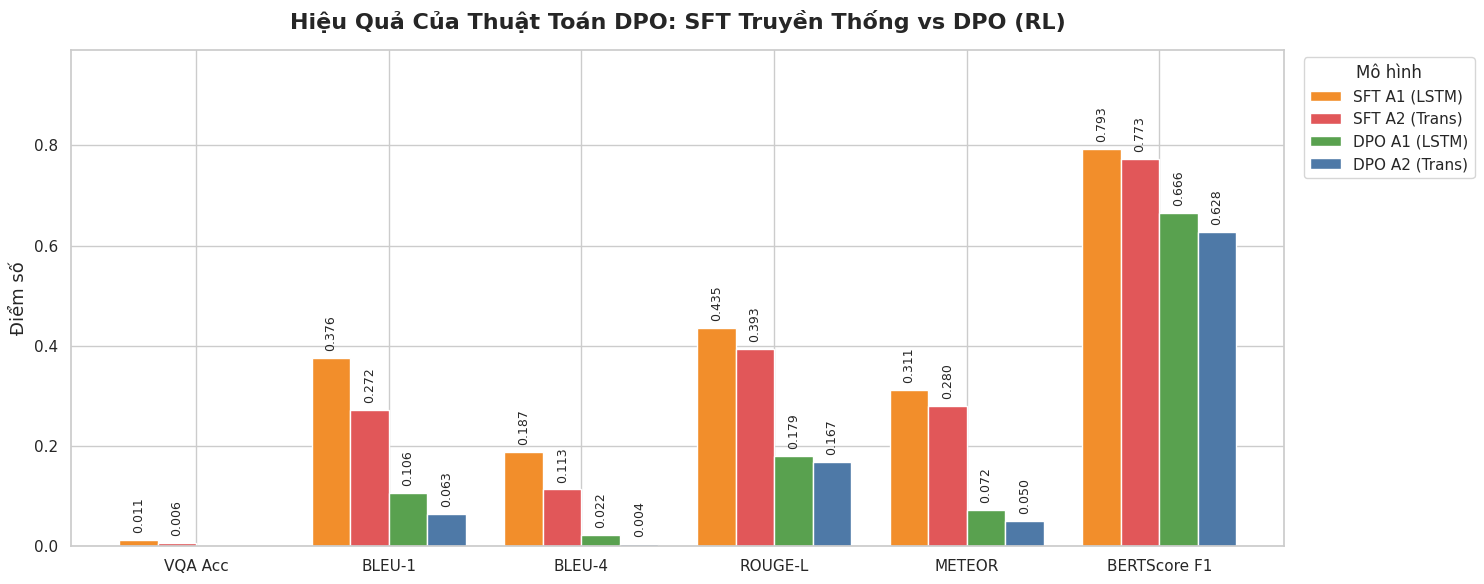


Biểu đồ So Sánh 4 Model đã được lưu tại: /content/logs/sft_vs_dpo_comparison.png


In [33]:
# ==========================================
# 13.3 SO SÁNH HIỆU SUẤT 4 MÔ HÌNH: SFT vs DPO
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=" * 60)
print("13.3 SO SÁNH HIỆU SUẤT 4 MÔ HÌNH: SFT vs DPO")
print("=" * 60)

def get_metric_safe(detailed, test_m, bert_m, key):
    if detailed and key in detailed: return detailed[key]
    if test_m   and key in test_m:   return test_m[key]
    if bert_m   and key in bert_m:   return bert_m[key]
    return 0.0

keys = ["vqa_acc", "BLEU-1", "BLEU-4", "ROUGE-L", "METEOR", "F1"]
labels = ["VQA Acc", "BLEU-1", "BLEU-4", "ROUGE-L", "METEOR", "BERTScore F1"]

comparison_data = {}

# Gom dữ liệu SFT (Từ Mục 11)
if 'test_metrics_a1' in globals() and test_metrics_a1:
    comparison_data['SFT A1 (LSTM)'] = [get_metric_safe(detailed_metrics_a1, test_metrics_a1, bert_metrics_a1, k) for k in keys]
else:
    print("THIẾU DỮ LIỆU SFT A1: Vui lòng chạy lại Mục 11.2, 11.3, 11.4 trước!")

if 'test_metrics_a2' in globals() and test_metrics_a2:
    comparison_data['SFT A2 (Trans)'] = [get_metric_safe(detailed_metrics_a2, test_metrics_a2, bert_metrics_a2, k) for k in keys]
else:
    print("THIẾU DỮ LIỆU SFT A2: Vui lòng chạy lại Mục 11 trước!")

# Gom dữ liệu DPO (Từ Cell trên)
if dpo_test_a1:
    comparison_data['DPO A1 (LSTM)'] = [get_metric_safe(dpo_detailed_a1, dpo_test_a1, dpo_bert_a1, k) for k in keys]
if dpo_test_a2:
    comparison_data['DPO A2 (Trans)'] = [get_metric_safe(dpo_detailed_a2, dpo_test_a2, dpo_bert_a2, k) for k in keys]

if not comparison_data:
    print("Không có đủ dữ liệu để vẽ biểu đồ!")
else:
    df_comp = pd.DataFrame(comparison_data, index=labels)
    print("\n--- BẢNG KẾT QUẢ SO SÁNH ---")
    display(df_comp.round(4))

    # Vẽ biểu đồ
    sns.set_theme(style="whitegrid")

    # 4 màu đại diện cho 4 model
    colors = ["#f28e2b", "#e15759", "#59a14f", "#4e79a7"]
    actual_colors = colors[:len(comparison_data)]

    ax = df_comp.plot(kind="bar", figsize=(15, 6), color=actual_colors, width=0.8)

    plt.title("Hiệu Quả Của Thuật Toán DPO: SFT Truyền Thống vs DPO (RL)", fontsize=16, fontweight='bold', pad=15)
    plt.ylabel("Điểm số", fontsize=13)
    plt.xticks(rotation=0, fontsize=11)

    # Kéo cao trục Y để có chỗ viết nhãn
    plt.ylim(0, df_comp.max().max() * 1.25 if df_comp.max().max() > 0 else 1.0)
    plt.legend(title="Mô hình", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11)

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:.3f}",
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9, rotation=90,
                        xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    comp_chart_path = os.path.join(LOG_DIR, "sft_vs_dpo_comparison.png")
    plt.savefig(comp_chart_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"\nBiểu đồ So Sánh 4 Model đã được lưu tại: {comp_chart_path}")
